# 03_Hybrid_Electric_Energy_Management.ipynb

## Havacılık Veri Bilimcileri İçin Optimizasyon Serisi

Bu defter, hibrit-elektrikli hava taşıtlarında enerji yönetimi optimizasyonuna odaklanmaktadır. Ardışık karar verme, dinamik programlama, takviyeli öğrenme ve tahmine dayalı modelleme gibi kavramları havacılık uygulamaları bağlamında keşfedeceğiz. Temel vurgu optimizasyon üzerindedir.

## Kaynaklar

Bu bölümde, defterde kullanılacak gerekli kütüphaneleri içe aktaracağız ve genel yapılandırmaları yapacağız.

In [1]:
# Standard library imports
import os
import math
import random
import time
from datetime import datetime

# Third-party library imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Configuration for plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12

# Ensure reproducibility
np.random.seed(42)
random.seed(42)

print("Necessary libraries imported and configured.")

Necessary libraries imported and configured.


# BÖLÜM 1 – GİRİŞ

Hibrit-elektrikli tahrik, geleneksel yanmalı motorları elektrik motorları ve batarya sistemleriyle birleştirerek havacılıkta önemli bir yeniliği temsil eder. Bu, yakıt verimliliğini artırmayı, emisyonları azaltmayı ve operasyonel esnekliği geliştirmeyi amaçlar. Ancak, bu sistemlerde enerji yönetimi karmaşık bir optimizasyon problemidir.

Hibrit-elektrikli bir hava taşıtında, yakıt motoru (örn. turboprop) ve elektrik motoru arasındaki güç dağılımı sürekli olarak ayarlanmalıdır. Bu ayarlamalar, uçuş fazı, batarya şarj durumu (SOC) ve anlık güç talebi gibi faktörlere bağlıdır. Bu sistemlerde enerji yönetimi, birçok çelişkili hedefi dengeleme zorunluluğundan dolayı zordur:

*   **Yakıt Tüketimini En Aza İndirmek:** Verimlilik temel bir hedeftir.
*   **Batarya Ömrünü Korumak:** Bataryaların sık sık aşırı şarj/deşarj edilmesi ömrünü kısaltır.
*   **Görev Başarısını Sağlamak:** Herhangi bir anda yeterli güç kullanılabilir olmalıdır.
*   **Emisyonları Azaltmak:** Çevresel sürdürülebilirlik önemli bir faktördür.

Sadece tahmin yapmak bu problemi çözmek için yeterli değildir. Örneğin, gelecekteki güç talebini doğru bir şekilde tahmin etmek önemli olsa da, bu tahmin tek başına motor ve batarya arasındaki optimal güç dağılımını belirlemez. En iyi kararları vermek için tahmin sonuçlarının bir optimizasyon algoritmasına beslenmesi gerekir. Bu nedenle, karmaşık sistemlerde enerji yönetimi için **optimizasyon** vazgeçilmezdir.

### Tahminden Karar Zekasına

Modern havacılık sistemlerinde **karar zekası (Decision Intelligence)**, veri, tahmin ve optimizasyonun entegrasyonuyla elde edilir. Bu entegrasyon, yalnızca ne olacağını öngörmekle kalmayıp (tahmin), aynı zamanda belirlenen hedeflere ulaşmak için en iyi eylem planını belirlemeyi (optimizasyon) de içerir. Hibrit-elektrikli hava taşıtlarında bu, veriye dayalı öngörülerden, uçuşun her anında en verimli enerji dağıtım kararlarını çıkarmak anlamına gelir.

*   **Veri:** Sensörlerden, uçuş planlarından ve operasyonel geçmişten toplanan bilgiler.
*   **Tahmin:** Gelecekteki güç talebi, rüzgar koşulları veya batarya performansının tahmini.
*   **Optimizasyon:** Bu tahminleri kullanarak yakıt tüketimini en aza indiren veya batarya ömrünü en üst düzeye çıkaran güç dağıtım stratejilerini belirleme.
*   **Karar:** Optimizasyon sonuçlarına dayanarak gerçek zamanlı veya planlanmış eylemler.

# BÖLÜM 2 – PROBLEM FORMÜLASYONU

Enerji yönetimi problemini incelemek için basitleştirilmiş bir hibrit-elektrikli hava taşıtı modeli oluşturacağız. Bu model, temel bileşenleri ve bir görev profilini içerecektir. Hedefimiz, bu sistem için bir optimizasyon çerçevesi geliştirmektir.

## Basitleştirilmiş Hibrit-Elektrikli Hava Taşıtı

Model uçağımız üç ana tahrik bileşenine sahiptir:

*   **Turboprop Motor:** Birincil itki kaynağı olarak görev yapar, yakıt tüketir ve gerekirse bataryayı şarj edebilir.
*   **Batarya Paketi:** Elektrik motoruna güç sağlar ve turboprop motor tarafından şarj edilebilir.
*   **Elektrik Motoru:** Ek itki sağlar veya turboprop motorun bataryayı şarj etmesi için bir jeneratör olarak çalışabilir. Genellikle kalkış ve tırmanış gibi yüksek güç gerektiren fazlarda destek sağlar.

## Görev Profili

Model uçağımız tipik bir uçuş görevi boyunca aşağıdaki segmentlerden geçecektir. Her segmentin farklı güç talepleri ve operasyonel kısıtlamaları vardır:

1.  **Taxi (Taksi):** Yer hareketi, düşük güç talebi.
2.  **Takeoff (Kalkış):** Maksimum güç talebi, kısa süreli.
3.  **Climb (Tırmanış):** Yüksek güç talebi, irtifa kazanımı.
4.  **Cruise (Seyir):** Orta güç talebi, uzun süreli, yüksek verimlilik hedefi.
5.  **Descent (İniş):** Düşük güç talebi, batarya şarjı için fırsat.
6.  **Landing (İniş):** Düşük güç talebi, yer hareketi öncesi.

## Problem Tanımı

Enerji yönetimi problemini çözmek için sistemi durumlar, eylemler ve hedefler açısından tanımlamamız gerekir.

### Durumlar (States)

Bir zaman adımında sistemin durumunu tanımlayan değişkenler:

*   $S_t = (SOC_t, W_t, Segment_t)$
    *   **Batarya Şarj Durumu (SOC_t):** Bataryanın mevcut şarj seviyesi (0 ile 1 arasında).
    *   **Uçak Ağırlığı (W_t):** Görev boyunca yakıt tüketimi nedeniyle değişen uçağın ağırlığı.
    *   **Görev Segmenti (Segment_t):** Uçağın içinde bulunduğu mevcut uçuş fazı (Taksi, Kalkış, Tırmanış, Seyir, İniş, iniş).


### Eylemler (Actions)

Her zaman adımında alınabilecek kararlar:

*   $A_t = (P_{turboprop, t}, P_{electric, t})$
    *   **Türboprop Güç Oranı (P_{turboprop, t}):** Türboprop motorunun toplam güç talebine katkısının oranı (0 ile 1 arasında). Örneğin, 0.7 ise toplam gücün %70'ini turboprop sağlar.
    *   **Elektrik Güç Oranı (P_{electric, t}):** Elektrik motorunun toplam güç talebine katkısının oranı (0 ile 1 arasında). Örneğin, 0.3 ise toplam gücün %30'unu elektrik motoru sağlar.

Kısıtlama: $P_{turboprop, t} + P_{electric, t} = 1$ (Toplam güç talebi karşılanmalıdır, bu oranlar toplam güce göre bir dağılımdır).

### Hedefler (Objectives)

Optimizasyon problemini yönlendiren hedefler:

*   **Yakıt Tüketimini En Aza İndirmek:** Görev boyunca toplam yakıt tüketimini minimize etmek.
*   **Batarya Sağlığını Korumak:** Bataryanın ömrünü uzatmak için aşırı deşarj veya aşırı şarjdan kaçınmak. Görev sonunda minimum bir SOC seviyesi hedeflenebilir.
*   **Görevi Başarıyla Tamamlamak:** Görev boyunca güç taleplerini karşılayabilmek ve operasyonel kısıtlamalara uymak.

## Optimizasyon Probleminin Matematiksel Formülasyonu

Enerji yönetimini bir Ardışık Karar Verme Problemi olarak formüle edebiliriz. Amacımız, her zaman adımı $t$ için eylemler dizisini $(A_0, A_1, ..., A_T)$ seçerek belirli bir hedef fonksiyonunu optimize etmektir.

**Minimize et:**

$J = \sum_{t=0}^{T-1} (C_{fuel}(P_{turboprop,t}) + C_{battery}(SOC_t, P_{electric,t})) + C_{final}(SOC_T)$

Burada:
*   $J$: Toplam maliyet fonksiyonu (genellikle ağırlıklı yakıt tüketimi ve batarya kullanım maliyeti).
*   $C_{fuel}(P_{turboprop,t})$: $t$ zaman adımında turboprop motoru tarafından harcanan yakıtın maliyeti.
*   $C_{battery}(SOC_t, P_{electric,t})$: $t$ zaman adımında elektrik motoru tarafından kullanılan batarya enerjisinin veya batarya sağlığına etkisinin maliyeti.
*   $C_{final}(SOC_T)$: Görev sonundaki batarya şarj durumuna (SOC) bağlı terminal maliyet (örn. istenen bir SOC'nin altına düşülürse ceza).

**Konuya göre:**

1.  **Durum Geçişleri (State Transitions):**
    *   $SOC_{t+1} = f_{SOC}(SOC_t, P_{electric,t}, P_{demand,t}, \Delta t)$
    *   $W_{t+1} = f_W(W_t, P_{turboprop,t}, \Delta t)$
    *   $Segment_{t+1}$: Görev profiline göre ilerleme.

2.  **Güç Dengesi Kısıtlaması:**
    *   $P_{turboprop,t} + P_{electric,t} = P_{demand,t}$
    *   Burada $P_{demand,t}$ o anki uçuş segmentinin toplam güç talebidir.

3.  **Eylem Kısıtlamaları:**
    *   $0 \le P_{turboprop,t} \le P_{turboprop,max}$
    *   $P_{electric,min} \le P_{electric,t} \le P_{electric,max}$
    *   (Batarya hem deşarj edilebilir hem de şarj edilebilir, dolayısıyla $P_{electric,min}$ negatif olabilir).

4.  **Durum Kısıtlamaları:**
    *   $SOC_{min} \le SOC_t \le SOC_{max}$
    *   $W_{min} \le W_t

Bu formülasyon, Bellman denklemleri veya optimal kontrol prensipleri kullanılarak çözülebilir, ki bu da Dinamik Programlama ve Model Tahminli Kontrol gibi tekniklerin temelini oluşturur.

# BÖLÜM 3 – ENERJİ MODELİNİ OLUŞTURMA

Bu bölümde, hibrit-elektrikli hava taşıtımızın enerji akışlarını simüle etmek için basitleştirilmiş matematiksel modeller oluşturacağız. Bu modeller, görev profili boyunca yakıt tüketimi, batarya enerji kullanımı ve batarya şarj durumu (SOC) gibi temel metrikleri tahmin etmemizi sağlayacaktır.

## Uçak Parametreleri ve Görev Tanımları

Simülasyonumuz için bazı temel parametreleri ve görev profilini tanımlayalım.

In [2]:
# Define aircraft and mission parameters
class AircraftParameters:
    def __init__(self):
        self.MAX_TURBOPROP_POWER_KW = 1000  # kW
        self.MAX_ELECTRIC_POWER_KW = 500    # kW (can be positive for discharge, negative for charge)
        self.BATTERY_CAPACITY_KWH = 200     # kWh
        self.INITIAL_SOC = 0.8              # Initial State of Charge (80%)
        self.MIN_SOC = 0.2                  # Minimum allowed SOC (20%)
        self.MAX_SOC = 0.95                 # Maximum allowed SOC (95%)
        self.TURBOPROP_FUEL_BURN_RATE_G_KWHR = 250 # g/kWh (specific fuel consumption)
        self.TURBOPROP_EFFICIENCY = 0.3     # Example efficiency
        self.ELECTRIC_MOTOR_EFFICIENCY = 0.95 # Electric motor efficiency
        self.BATTERY_CHARGE_EFFICIENCY = 0.9  # Battery charging efficiency
        self.BATTERY_DISCHARGE_EFFICIENCY = 0.95 # Battery discharging efficiency
        self.AIRCRAFT_INITIAL_WEIGHT_KG = 6000 # kg

class MissionProfile:
    def __init__(self):
        self.SEGMENTS = {
            "Taxi":     {"duration": 10 * 60, "power_demand_kw": 200, "description": "Yer hareketleri"},
            "Takeoff":  {"duration": 2 * 60,  "power_demand_kw": 1200, "description": "Kalkış fazı"},
            "Climb":    {"duration": 15 * 60, "power_demand_kw": 900, "description": "Tırmanış fazı"},
            "Cruise":   {"duration": 60 * 60, "power_demand_kw": 600, "description": "Seyir fazı"},
            "Descent":  {"duration": 10 * 60, "power_demand_kw": 150, "description": "İniş fazı"},
            "Landing":  {"duration": 5 * 60,  "power_demand_kw": 100, "description": "İniş ve taksi"}
        }
        self.TOTAL_DURATION_SEC = sum(s['duration'] for s in self.SEGMENTS.values())
        self.TIME_STEP_SEC = 5 # seconds

params = AircraftParameters()
mission = MissionProfile()

print("Aircraft parameters and mission profile defined.")

Aircraft parameters and mission profile defined.


## Basitleştirilmiş Enerji Modelleri

Şimdi yakıt tüketimini, batarya kullanımını ve SOC'u güncellemeyi sağlayan temel fonksiyonları tanımlayalım.

In [3]:
def calculate_fuel_burn_kg(turboprop_power_kw: float, time_step_sec: float, sfc_g_kwhr: float) -> float:
    """
    Calculate fuel consumed by turboprop in kilograms for a given time step.
    Args:
        turboprop_power_kw: Power generated by turboprop in kW.
        time_step_sec: Duration of the time step in seconds.
        sfc_g_kwhr: Specific fuel consumption in g/kWhr.
    Returns:
        Fuel consumed in kg.
    """
    # Convert time_step_sec to hours
    time_step_hr = time_step_sec / 3600
    fuel_g = turboprop_power_kw * time_step_hr * sfc_g_kwhr
    return fuel_g / 1000 # Convert grams to kilograms

def calculate_battery_energy_kwh(electric_power_kw: float, time_step_sec: float, efficiency: float) -> float:
    """
    Calculate battery energy used/charged in kWh for a given time step.
    Positive electric_power_kw means discharge, negative means charge.
    Args:
        electric_power_kw: Electric power in kW (positive for discharge, negative for charge).
        time_step_sec: Duration of the time step in seconds.
        efficiency: Battery charge/discharge efficiency.
    Returns:
        Energy change in kWh.
    """
    time_step_hr = time_step_sec / 3600
    energy_kwh = electric_power_kw * time_step_hr

    if electric_power_kw > 0: # Discharging
        return energy_kwh / efficiency
    elif electric_power_kw < 0: # Charging
        return energy_kwh * efficiency
    else:
        return 0.0

def update_soc(current_soc: float, energy_change_kwh: float, battery_capacity_kwh: float) -> float:
    """
    Update battery State of Charge (SOC).
    Args:
        current_soc: Current SOC (0-1).
        energy_change_kwh: Change in energy in kWh (positive for discharge, negative for charge).
        battery_capacity_kwh: Total battery capacity in kWh.
    Returns:
        New SOC (0-1).
    """
    soc_change = -energy_change_kwh / battery_capacity_kwh
    new_soc = current_soc + soc_change
    return np.clip(new_soc, params.MIN_SOC, params.MAX_SOC) # Clip to min/max SOC limits

def update_weight_kg(current_weight_kg: float, fuel_burn_kg: float) -> float:
    """
    Update aircraft weight based on fuel burn.
    Args:
        current_weight_kg: Current aircraft weight in kg.
        fuel_burn_kg: Fuel consumed in kg.
    Returns:
        New aircraft weight in kg.
    """
    return current_weight_kg - fuel_burn_kg

print("Energy model functions defined.")

Energy model functions defined.


## Görev Verilerini Oluşturma

Şimdi tanımladığımız modelleri kullanarak basitleştirilmiş bir görev simülasyonu gerçekleştirelim ve veri oluşturalım. Bu aşamada basit bir kural tabanlı güç bölüşümü kullanacağız; turboprop ana güç sağlayıcı, elektrik motoru ise zirve talepleri karşılayıcı ve batarya şarj edici olarak görev yapacak. Bu, henüz optimize edilmiş bir strateji değildir; sadece EDA için veri üretmeye yöneliktir.

In [4]:
# Initialize simulation variables
time_points = np.arange(0, mission.TOTAL_DURATION_SEC, mission.TIME_STEP_SEC)
num_steps = len(time_points)

data = {
    'time_sec': [],
    'mission_segment': [],
    'power_demand_kw': [],
    'turboprop_power_kw': [],
    'electric_power_kw': [],
    'fuel_burn_kg': [],
    'battery_energy_kwh': [],
    'soc': [],
    'aircraft_weight_kg': []
}

current_soc = params.INITIAL_SOC
current_weight_kg = params.AIRCRAFT_INITIAL_WEIGHT_KG
cumulative_fuel_burn_kg = 0.0

segment_start_time = 0
current_segment_name = list(mission.SEGMENTS.keys())[0]

# Simulate the mission
for i, t in enumerate(time_points):
    # Determine current mission segment
    segment_duration_sum = 0
    for segment_name, seg_data in mission.SEGMENTS.items():
        segment_duration_sum += seg_data['duration']
        if t < segment_duration_sum:
            current_segment_name = segment_name
            power_demand_kw = seg_data['power_demand_kw']
            break

    # Simple rule-based power split for data generation
    # Prioritize turboprop, electric motor for peak demand or charge
    turboprop_power_kw = 0.0
    electric_power_kw = 0.0

    # Attempt to meet demand primarily with turboprop
    if power_demand_kw <= params.MAX_TURBOPROP_POWER_KW:
        turboprop_power_kw = power_demand_kw
    else:
        turboprop_power_kw = params.MAX_TURBOPROP_POWER_KW
        electric_power_kw = power_demand_kw - params.MAX_TURBOPROP_POWER_KW

    # Adjust electric power to stay within max limits
    electric_power_kw = np.clip(electric_power_kw, -params.MAX_ELECTRIC_POWER_KW, params.MAX_ELECTRIC_POWER_KW)

    # Ensure SOC constraints are respected
    # If SOC is low, turboprop takes over more, or if power demand is high and battery can't help enough.
    # If SOC is high and turboprop is under-utilized, charge battery if possible (negative electric_power_kw).

    # For this simple data generation, let's assume electric assists up to its max, and turboprop covers the rest.
    # Or, if demand is low, turboprop can be throttled down, or charge battery.

    # More sophisticated power split for data generation
    remaining_demand = power_demand_kw

    # Try to meet with turboprop first
    if remaining_demand > params.MAX_TURBOPROP_POWER_KW: # Turboprop alone cannot meet demand
        turboprop_power_kw = params.MAX_TURBOPROP_POWER_KW
        remaining_demand -= turboprop_power_kw
        electric_power_kw = remaining_demand # Electric makes up the difference
    else: # Turboprop can meet or exceed demand
        turboprop_power_kw = remaining_demand
        electric_power_kw = 0.0 # No need for electric assist

        # If turboprop is underutilized, can it charge battery? (Simple rule: only if demand is low)
        if current_segment_name in ["Descent", "Taxi", "Landing"] and current_soc < params.MAX_SOC:
            # Try to charge battery with a fraction of turboprop excess capacity
            available_turboprop_excess = params.MAX_TURBOPROP_POWER_KW - power_demand_kw
            charge_power_kw = min(available_turboprop_excess * 0.5, params.MAX_ELECTRIC_POWER_KW) # Use half of excess to charge, up to electric max
            if charge_power_kw > 0:
                electric_power_kw = -charge_power_kw # Negative for charging
                turboprop_power_kw += charge_power_kw # Turboprop needs to generate this extra power
                turboprop_power_kw = min(turboprop_power_kw, params.MAX_TURBOPROP_POWER_KW)

    # Ensure electric power is within limits
    electric_power_kw = np.clip(electric_power_kw, -params.MAX_ELECTRIC_POWER_KW, params.MAX_ELECTRIC_POWER_KW)

    # Calculate fuel burn
    current_fuel_burn = calculate_fuel_burn_kg(turboprop_power_kw, mission.TIME_STEP_SEC, params.TURBOPROP_FUEL_BURN_RATE_G_KWHR)
    cumulative_fuel_burn_kg += current_fuel_burn

    # Calculate battery energy change
    if electric_power_kw >= 0: # Discharging or zero
        current_battery_energy_change_kwh = calculate_battery_energy_kwh(electric_power_kw, mission.TIME_STEP_SEC, params.BATTERY_DISCHARGE_EFFICIENCY)
    else: # Charging
        current_battery_energy_change_kwh = calculate_battery_energy_kwh(electric_power_kw, mission.TIME_STEP_SEC, params.BATTERY_CHARGE_EFFICIENCY)

    # Update SOC, clipping handles min/max
    new_soc = update_soc(current_soc, current_battery_energy_change_kwh, params.BATTERY_CAPACITY_KWH)

    # Check if SOC limits are violated and adjust (simple adjustment for data gen)
    if new_soc < params.MIN_SOC:
        # Not enough battery, turboprop must provide more power
        # This is a simplified emergency adjustment for data generation, not a real control strategy
        needed_electric_power_kw = (params.MIN_SOC - current_soc) * params.BATTERY_CAPACITY_KWH / (mission.TIME_STEP_SEC / 3600 * params.BATTERY_DISCHARGE_EFFICIENCY)
        electric_power_kw -= needed_electric_power_kw # Try to take less from battery
        turboprop_power_kw += needed_electric_power_kw # Turboprop compensates
        turboprop_power_kw = np.clip(turboprop_power_kw, 0, params.MAX_TURBOPROP_POWER_KW)
        # Re-calculate SOC after adjustment
        current_battery_energy_change_kwh = calculate_battery_energy_kwh(electric_power_kw, mission.TIME_STEP_SEC, params.BATTERY_DISCHARGE_EFFICIENCY)
        new_soc = update_soc(current_soc, current_battery_energy_change_kwh, params.BATTERY_CAPACITY_KWH)
    elif new_soc > params.MAX_SOC:
        # Battery is full, stop charging or reduce turboprop if it was charging
        # This is a simplified emergency adjustment for data generation
        electric_power_kw = np.clip(electric_power_kw, 0, params.MAX_ELECTRIC_POWER_KW) # Don't charge further, only discharge or idle
        # Recalculate based on new electric power
        current_battery_energy_change_kwh = calculate_battery_energy_kwh(electric_power_kw, mission.TIME_STEP_SEC, params.BATTERY_DISCHARGE_EFFICIENCY)
        new_soc = update_soc(current_soc, current_battery_energy_change_kwh, params.BATTERY_CAPACITY_KWH)

    # Update current SOC for next step
    current_soc = new_soc

    # Update aircraft weight
    current_weight_kg = update_weight_kg(current_weight_kg, current_fuel_burn)

    # Store data
    data['time_sec'].append(t)
    data['mission_segment'].append(current_segment_name)
    data['power_demand_kw'].append(power_demand_kw)
    data['turboprop_power_kw'].append(turboprop_power_kw)
    data['electric_power_kw'].append(electric_power_kw)
    data['fuel_burn_kg'].append(current_fuel_burn)
    data['battery_energy_kwh'].append(current_battery_energy_change_kwh)
    data['soc'].append(current_soc)
    data['aircraft_weight_kg'].append(current_weight_kg)

df_mission = pd.DataFrame(data)

print("Mission data generated with a simple rule-based power split.")
display(df_mission.head())

Mission data generated with a simple rule-based power split.


,time_sec,mission_segment,power_demand_kw,turboprop_power_kw,electric_power_kw,fuel_burn_kg,battery_energy_kwh,soc,aircraft_weight_kg
0,0,Taxi,200,600.0,-400.0,0.208333,-0.5,0.8025,5999.791667
1,5,Taxi,200,600.0,-400.0,0.208333,-0.5,0.8050,5999.583333
2,10,Taxi,200,600.0,-400.0,0.208333,-0.5,0.8075,5999.375000
3,15,Taxi,200,600.0,-400.0,0.208333,-0.5,0.8100,5999.166667
4,20,Taxi,200,600.0,-400.0,0.208333,-0.5,0.8125,5998.958333


# BÖLÜM 4 – KEŞİFSEL VERİ ANALİZİ (EDA)

Bu bölümde, oluşturduğumuz görev verilerini analiz ederek sistemin dinamikleri, güç gereksinimleri, yakıt kullanımı ve batarya davranışları hakkında içgörüler elde edeceğiz. Profesyonel görselleştirmeler kullanarak potansiyel optimizasyon fırsatlarını belirleyeceğiz.

## Görev Güç Gereksinimleri

Uçuş profili boyunca toplam güç talebini ve turboprop ile elektrik motorlarının bu talebi nasıl karşıladığını görselleştirelim.

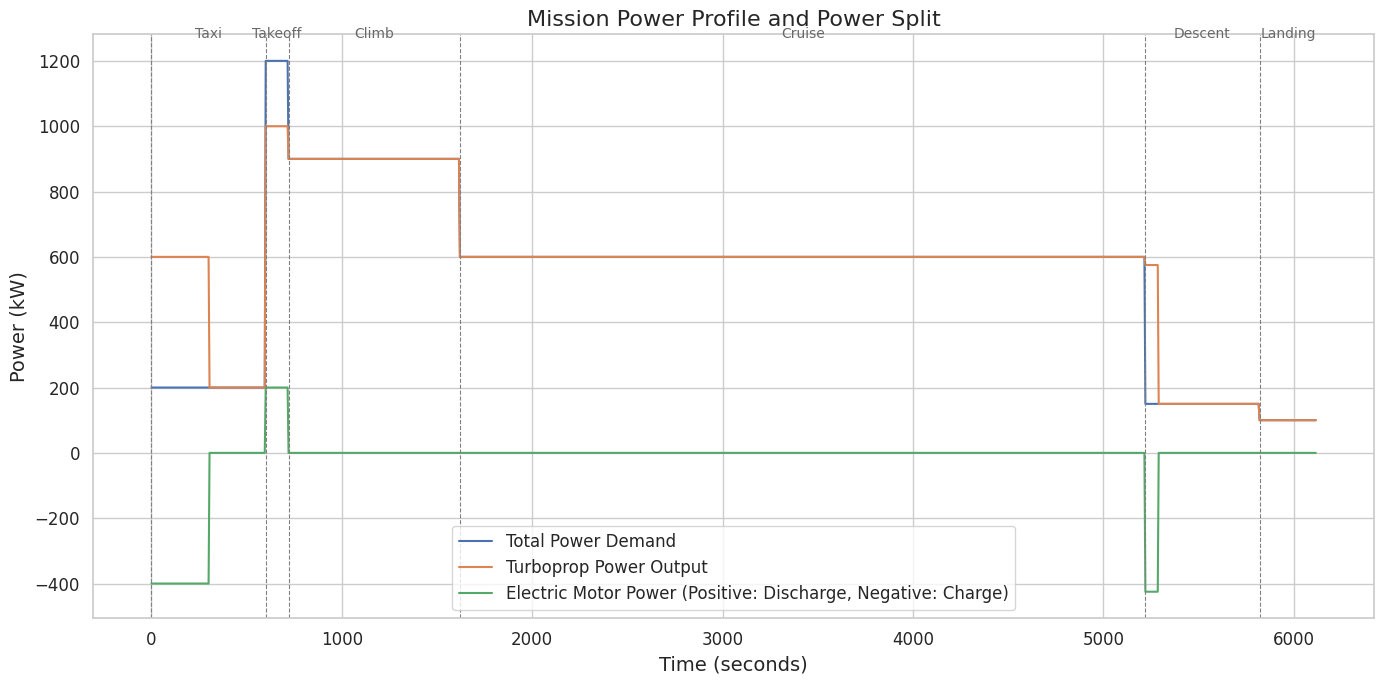

In [5]:
plt.figure(figsize=(14, 7))
sns.lineplot(x='time_sec', y='power_demand_kw', data=df_mission, label='Total Power Demand')
sns.lineplot(x='time_sec', y='turboprop_power_kw', data=df_mission, label='Turboprop Power Output')
sns.lineplot(x='time_sec', y='electric_power_kw', data=df_mission, label='Electric Motor Power (Positive: Discharge, Negative: Charge)')

# Add mission segment lines and labels
segment_start_time = 0
for segment_name, seg_data in mission.SEGMENTS.items():
    segment_end_time = segment_start_time + seg_data['duration']
    plt.axvline(x=segment_start_time, color='gray', linestyle='--', linewidth=0.8)
    plt.text(segment_start_time + seg_data['duration']/2, df_mission['power_demand_kw'].max() * 1.05, segment_name,
             rotation=0, horizontalalignment='center', verticalalignment='bottom', fontsize=10, color='dimgray')
    segment_start_time = segment_end_time

plt.title('Mission Power Profile and Power Split')
plt.xlabel('Time (seconds)')
plt.ylabel('Power (kW)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Yorum

Görselleştirme, farklı uçuş segmentlerindeki güç taleplerini ve basit kural tabanlı stratejimizin bu talepleri nasıl karşıladığını açıkça göstermektedir. Kalkış ve tırmanış gibi yüksek güç gerektiren fazlarda elektrik motorunun turboprop motora destek olduğunu, iniş gibi düşük güç fazlarında ise bataryanın şarj edildiğini görüyoruz. Bu, hibrit sistemin dinamiklerini anlamak için iyi bir başlangıç noktasıdır.

## Batarya Şarj Durumu (SOC) ve Kümülatif Yakıt Tüketimi

Batarya şarj durumunun görev boyunca nasıl değiştiğini ve kümülatif yakıt tüketimini inceleyelim.

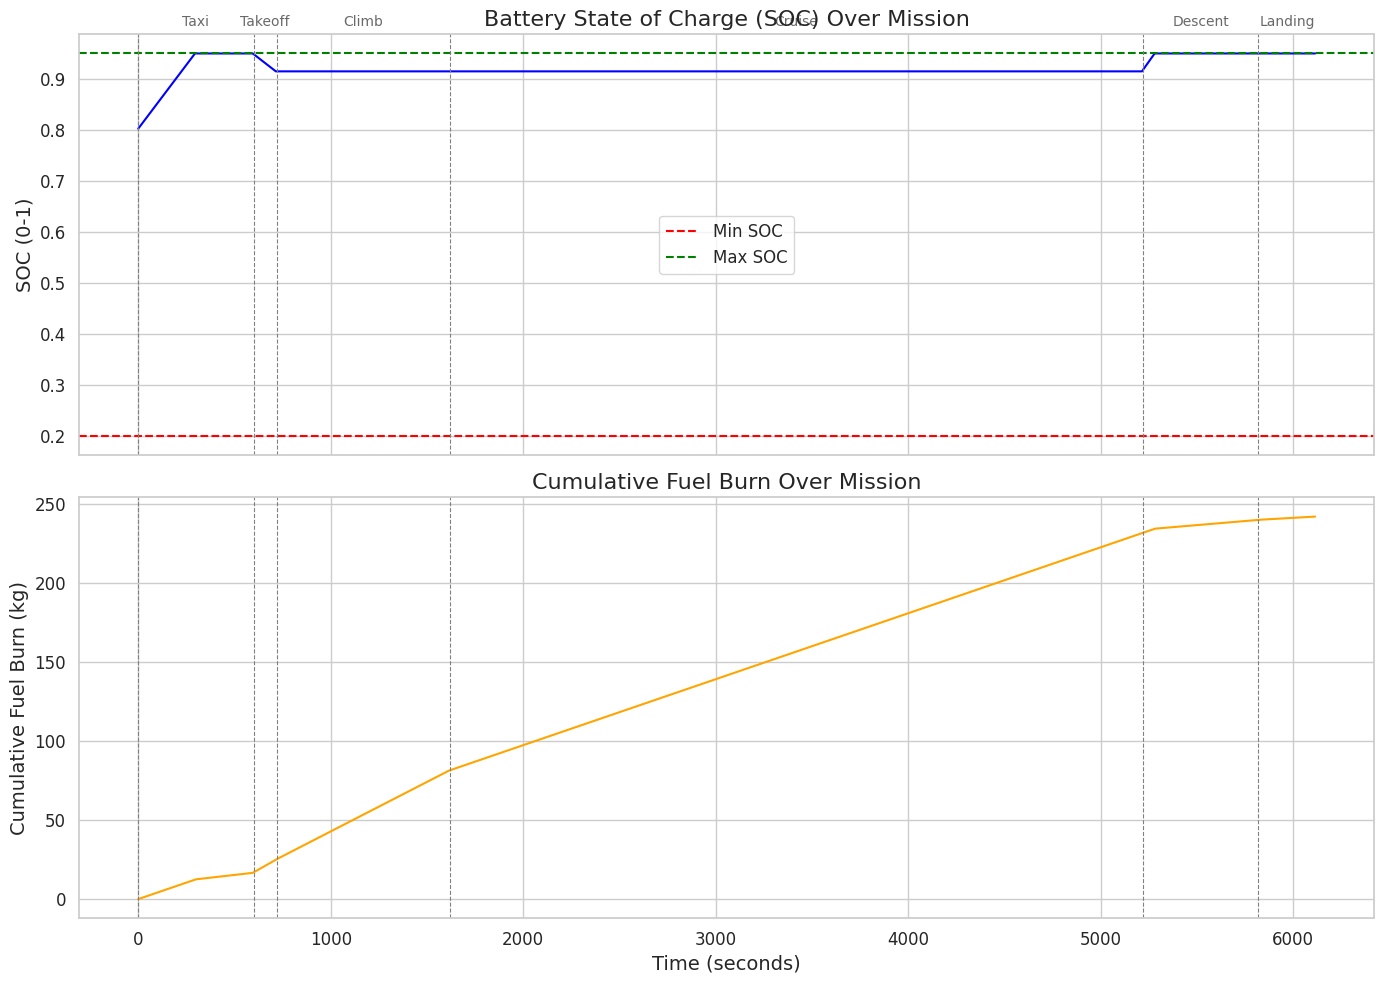

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Plot SOC over time
sns.lineplot(x='time_sec', y='soc', data=df_mission, ax=axes[0], color='blue')
axes[0].axhline(y=params.MIN_SOC, color='red', linestyle='--', label='Min SOC')
axes[0].axhline(y=params.MAX_SOC, color='green', linestyle='--', label='Max SOC')
axes[0].set_title('Battery State of Charge (SOC) Over Mission')
axes[0].set_ylabel('SOC (0-1)')
axes[0].legend()
axes[0].grid(True)

# Plot Cumulative Fuel Burn
df_mission['cumulative_fuel_burn_kg'] = df_mission['fuel_burn_kg'].cumsum()
sns.lineplot(x='time_sec', y='cumulative_fuel_burn_kg', data=df_mission, ax=axes[1], color='orange')
axes[1].set_title('Cumulative Fuel Burn Over Mission')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Cumulative Fuel Burn (kg)')
axes[1].grid(True)

# Add mission segment lines and labels to both plots
segment_start_time = 0
for segment_name, seg_data in mission.SEGMENTS.items():
    segment_end_time = segment_start_time + seg_data['duration']
    axes[0].axvline(x=segment_start_time, color='gray', linestyle='--', linewidth=0.8)
    axes[1].axvline(x=segment_start_time, color='gray', linestyle='--', linewidth=0.8)
    axes[0].text(segment_start_time + seg_data['duration']/2, params.MAX_SOC * 1.05, segment_name,
                 rotation=0, horizontalalignment='center', verticalalignment='bottom', fontsize=10, color='dimgray')
    segment_start_time = segment_end_time

plt.tight_layout()
plt.show()

### Yorum

SOC grafiği, bataryanın kalkış ve tırmanışta deşarj olduğunu, seyir sırasında stabilize olduğunu ve inişte tekrar şarj olduğunu gösteriyor. Bu, enerji yönetim stratejisinin batarya kullanımını nasıl etkilediğini anlamak için kritik bir bilgidir. Kümülatif yakıt tüketimi, zamanla sürekli artarak uçağın toplam yakıt harcamasını göstermektedir. Bu grafiğin eğimi, belirli bir segmentteki yakıt tüketiminin bir göstergesidir.

## Görev Segmentine Göre Yakıt ve Batarya Kullanımı

Hangi uçuş segmentlerinin en çok yakıt tükettiğini ve bataryayı en çok kullandığını analiz edelim.

/tmp/ipykernel_1091/1149240885.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='mission_segment', y='total_fuel_burn_kg', data=segment_summary, ax=axes[0], palette='viridis')


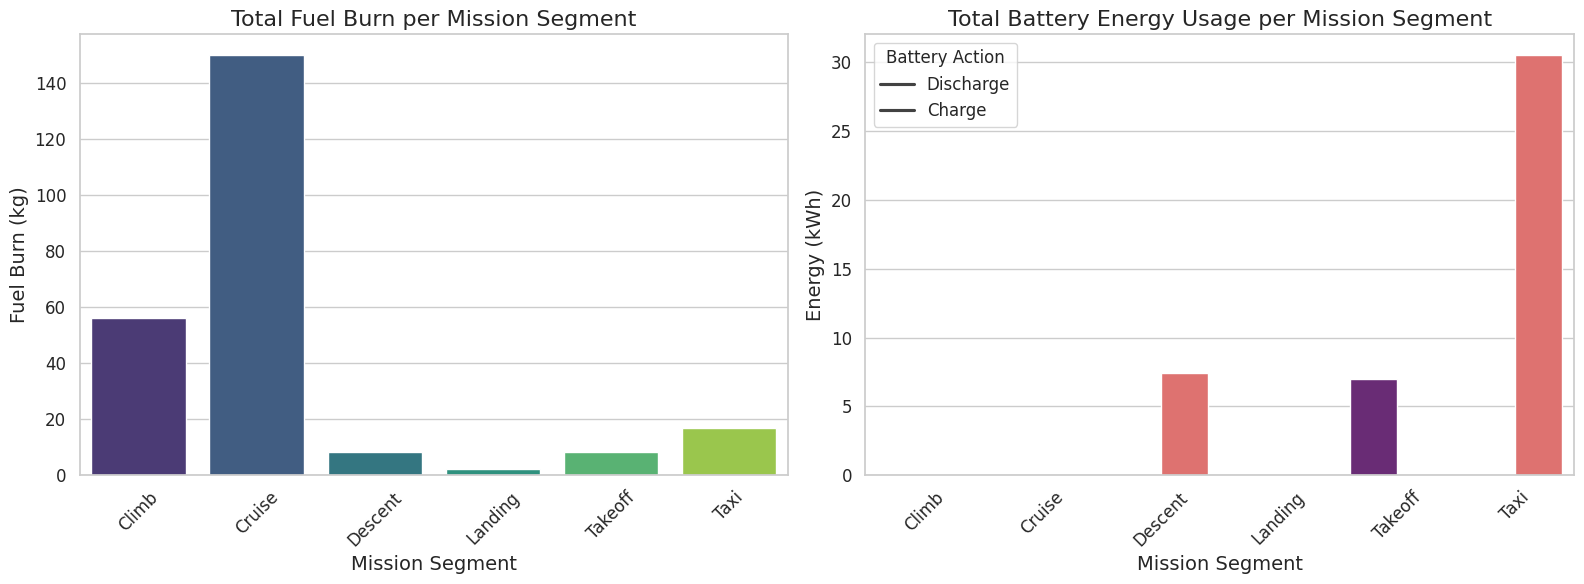

In [7]:
# Calculate total fuel burn and battery energy change per segment
segment_summary = df_mission.groupby('mission_segment').agg(
    total_fuel_burn_kg=('fuel_burn_kg', 'sum'),
    total_battery_discharge_kwh=('battery_energy_kwh', lambda x: x[x > 0].sum()), # Sum of positive (discharge) values
    total_battery_charge_kwh=('battery_energy_kwh', lambda x: -x[x < 0].sum())  # Sum of negative (charge) values, made positive
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Total Fuel Burn per Segment
sns.barplot(x='mission_segment', y='total_fuel_burn_kg', data=segment_summary, ax=axes[0], palette='viridis')
axes[0].set_title('Total Fuel Burn per Mission Segment')
axes[0].set_xlabel('Mission Segment')
axes[0].set_ylabel('Fuel Burn (kg)')
axes[0].tick_params(axis='x', rotation=45)

# Plot Total Battery Usage per Segment
battery_df = segment_summary.melt(id_vars=['mission_segment'],
                                  value_vars=['total_battery_discharge_kwh', 'total_battery_charge_kwh'],
                                  var_name='Battery Action', value_name='Energy (kWh)')
sns.barplot(x='mission_segment', y='Energy (kWh)', hue='Battery Action', data=battery_df, ax=axes[1], palette='magma')
axes[1].set_title('Total Battery Energy Usage per Mission Segment')
axes[1].set_xlabel('Mission Segment')
axes[1].set_ylabel('Energy (kWh)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Battery Action', labels=['Discharge', 'Charge'])

plt.tight_layout()
plt.show()

### Yorum

Bu grafikler, yakıt tüketiminin ve batarya kullanımının hangi segmentlerde yoğunlaştığını net bir şekilde göstermektedir. Örneğin, Seyir ve Tırmanış fazları genellikle en yüksek yakıt tüketimine sahipken, Kalkış fazı en yüksek batarya deşarjını gerektirebilir. Bu içgörüler, optimizasyon stratejileri geliştirirken hangi segmentlere odaklanmamız gerektiğini belirlememize yardımcı olacaktır.

## Potansiyel Optimizasyon Fırsatları

Keşifsel veri analizi (EDA) sonucunda aşağıdaki potansiyel optimizasyon fırsatlarını belirleyebiliriz:

*   **Kalkış ve Tırmanışta Batarya Desteği:** Bu fazlarda yüksek güç talebi, bataryanın yoğun deşarjına neden olur. Turboprop motoru üzerindeki yükü azaltarak yakıt tüketimini düşürme potansiyeli vardır.
*   **İniş ve Takside Batarya Şarjı:** Düşük güç talebi olan bu fazlar, turboprop motorunun fazladan güç üreterek bataryayı şarj etmesi için bir fırsat sunar. Bu, bir sonraki görev için bataryayı hazırlayarak veya görev sonunda belirli bir SOC hedefine ulaşarak batarya sağlığını artırabilir.
*   **Seyir Esnasında Verimlilik:** Seyir, en uzun süreli segment olduğu için yakıt tüketimini minimize etmek genel verimlilik üzerinde büyük bir etkiye sahip olacaktır. Elektrik motorunun bu fazda rol oynayıp oynamayacağı (örn. itkiyi optimize etmek veya bataryayı şarj etmek) incelenebilir.
*   **SOC Yönetimi:** Bataryanın belirli sınırlar (Min SOC ve Max SOC) içinde kalmasını sağlamak ve ömrünü uzatmak, optimize edilmiş bir kontrol stratejisinin önemli bir parçası olmalıdır.

Bu gözlemler, sonraki bölümlerde geliştireceğimiz optimizasyon algoritmaları için temel oluşturacaktır.

# BÖLÜM 5 – TEMEL STRATEJİ

Optimizasyon algoritmalarımızın performansını değerlendirmek için bir 'temel' veya 'referans' stratejiye ihtiyacımız var. Bu bölümde, hibrit-elektrikli hava taşıtının enerji yönetimi için basit, kural tabanlı bir kontrolör uygulayacağız. Bu kontrolör, genellikle mevcut sistemlerde kullanılan veya mühendislik içgörüsüne dayalı basit yaklaşımları temsil eder.

## Kural Tabanlı Kontrolör Uygulaması

Basit bir kural seti tanımlayalım:

*   **Kalkış (Takeoff):** Maksimum elektrikli motor desteği, geri kalan turboprop tarafından karşılanır.
*   **Tırmanış (Climb):** Elektrik motoru kısmi destek sağlar, geri kalan turboprop tarafından karşılanır.
*   **Seyir (Cruise):** Esas olarak turboprop motor kullanılır, elektrik motoru minimumda veya kapalıdır.
*   **İniş (Descent) ve Taksi (Taxi/Landing):** Düşük güç talebi. Turboprop motor gücün bir kısmını karşılar, aşırı güç bataryayı şarj etmek için kullanılır (eğer SOC izin veriyorsa).

In [8]:
def simulate_mission_rule_based(params: AircraftParameters, mission: MissionProfile) -> pd.DataFrame:
    """
    Simulates the mission using a predefined rule-based control strategy.
    """
    time_points = np.arange(0, mission.TOTAL_DURATION_SEC, mission.TIME_STEP_SEC)

    data = {
        'time_sec': [],
        'mission_segment': [],
        'power_demand_kw': [],
        'turboprop_power_kw': [],
        'electric_power_kw': [],
        'fuel_burn_kg': [],
        'battery_energy_kwh': [],
        'soc': [],
        'aircraft_weight_kg': []
    }

    current_soc = params.INITIAL_SOC
    current_weight_kg = params.AIRCRAFT_INITIAL_WEIGHT_KG

    for i, t in enumerate(time_points):
        segment_duration_sum = 0
        current_segment_name = ''
        power_demand_kw = 0.0
        for segment_name, seg_data in mission.SEGMENTS.items():
            segment_duration_sum += seg_data['duration']
            if t < segment_duration_sum:
                current_segment_name = segment_name
                power_demand_kw = seg_data['power_demand_kw']
                break

        turboprop_power_kw = 0.0
        electric_power_kw = 0.0

        # Rule-based control strategy
        if current_segment_name == "Takeoff":
            electric_power_kw = min(power_demand_kw, params.MAX_ELECTRIC_POWER_KW)
            turboprop_power_kw = power_demand_kw - electric_power_kw

        elif current_segment_name == "Climb":
            electric_assist = min(power_demand_kw * 0.3, params.MAX_ELECTRIC_POWER_KW) # 30% assist
            electric_power_kw = electric_assist
            turboprop_power_kw = power_demand_kw - electric_power_kw

        elif current_segment_name == "Cruise":
            turboprop_power_kw = power_demand_kw
            electric_power_kw = 0.0 # Electric motor off during cruise
            # Optionally, charge battery if excess turboprop power available and SOC is low
            # Not implemented in this basic rule for simplicity.

        elif current_segment_name in ["Descent", "Taxi", "Landing"]:
            # Try to meet demand with turboprop, and charge battery if possible
            turboprop_power_for_demand = min(power_demand_kw, params.MAX_TURBOPROP_POWER_KW)
            turboprop_power_kw = turboprop_power_for_demand
            electric_power_kw = 0.0 # No discharge for these phases based on this rule

            # If there's capacity in turboprop and SOC is not full, charge battery
            if current_soc < params.MAX_SOC:
                # Turboprop excess power available (arbitrary for now)
                turboprop_excess_for_charge = params.MAX_TURBOPROP_POWER_KW - turboprop_power_for_demand
                charge_amount_kw = min(turboprop_excess_for_charge * 0.5, params.MAX_ELECTRIC_POWER_KW) # Use 50% excess to charge
                if charge_amount_kw > 0:
                    electric_power_kw = -charge_amount_kw  # Negative for charging
                    turboprop_power_kw += charge_amount_kw # Turboprop needs to generate this for charging
                    turboprop_power_kw = min(turboprop_power_kw, params.MAX_TURBOPROP_POWER_KW) # Ensure turboprop doesn't exceed max
        else:
            # Default: turboprop covers demand
            turboprop_power_kw = power_demand_kw
            electric_power_kw = 0.0

        # Ensure turboprop power doesn't exceed max
        turboprop_power_kw = np.clip(turboprop_power_kw, 0, params.MAX_TURBOPROP_POWER_KW)

        # Ensure electric power is within limits and SOC constraints for discharge
        max_dischargeable_energy_kwh = (current_soc - params.MIN_SOC) * params.BATTERY_CAPACITY_KWH
        max_discharge_power_kw = max_dischargeable_energy_kwh / (mission.TIME_STEP_SEC / 3600 * params.BATTERY_DISCHARGE_EFFICIENCY)

        max_chargeable_energy_kwh = (params.MAX_SOC - current_soc) * params.BATTERY_CAPACITY_KWH
        max_charge_power_kw = max_chargeable_energy_kwh / (mission.TIME_STEP_SEC / 3600 * params.BATTERY_CHARGE_EFFICIENCY)

        # If trying to discharge, limit by available SOC and max electric power
        if electric_power_kw > 0:
            electric_power_kw = min(electric_power_kw, max_discharge_power_kw)
            electric_power_kw = min(electric_power_kw, params.MAX_ELECTRIC_POWER_KW)
        # If trying to charge, limit by available SOC and max electric power
        elif electric_power_kw < 0:
            electric_power_kw = max(electric_power_kw, -max_charge_power_kw) # electric_power_kw is negative, so max means closer to 0
            electric_power_kw = max(electric_power_kw, -params.MAX_ELECTRIC_POWER_KW) # More negative is more charging

        # Re-calculate turboprop power if electric power was clipped due to SOC limits
        total_power_provided = turboprop_power_kw + electric_power_kw
        if total_power_provided < power_demand_kw: # Still short after electric limits
            turboprop_power_kw += (power_demand_kw - total_power_provided)
            turboprop_power_kw = np.clip(turboprop_power_kw, 0, params.MAX_TURBOPROP_POWER_KW)
            # If turboprop cannot cover, we have a power deficit (for this baseline, assume it's met by turboprop for simplicity)


        current_fuel_burn = calculate_fuel_burn_kg(turboprop_power_kw, mission.TIME_STEP_SEC, params.TURBOPROP_FUEL_BURN_RATE_G_KWHR)

        if electric_power_kw >= 0: # Discharging or zero
            current_battery_energy_change_kwh = calculate_battery_energy_kwh(electric_power_kw, mission.TIME_STEP_SEC, params.BATTERY_DISCHARGE_EFFICIENCY)
        else: # Charging
            current_battery_energy_change_kwh = calculate_battery_energy_kwh(electric_power_kw, mission.TIME_STEP_SEC, params.BATTERY_CHARGE_EFFICIENCY)

        new_soc = update_soc(current_soc, current_battery_energy_change_kwh, params.BATTERY_CAPACITY_KWH)

        # Final check and adjustment for SOC boundaries. If it hits min/max, it means the power split was too aggressive.
        # For this baseline, we just clip the SOC to ensure it doesn't go out of bounds.
        current_soc = np.clip(new_soc, params.MIN_SOC, params.MAX_SOC)

        current_weight_kg = update_weight_kg(current_weight_kg, current_fuel_burn)

        data['time_sec'].append(t)
        data['mission_segment'].append(current_segment_name)
        data['power_demand_kw'].append(power_demand_kw)
        data['turboprop_power_kw'].append(turboprop_power_kw)
        data['electric_power_kw'].append(electric_power_kw)
        data['fuel_burn_kg'].append(current_fuel_burn)
        data['battery_energy_kwh'].append(current_battery_energy_change_kwh)
        data['soc'].append(current_soc)
        data['aircraft_weight_kg'].append(current_weight_kg)

    return pd.DataFrame(data)

df_baseline = simulate_mission_rule_based(params, mission)

print("Baseline rule-based strategy simulation completed.")
display(df_baseline.head())

Baseline rule-based strategy simulation completed.


,time_sec,mission_segment,power_demand_kw,turboprop_power_kw,electric_power_kw,fuel_burn_kg,battery_energy_kwh,soc,aircraft_weight_kg
0,0,Taxi,200,600.0,-400.0,0.208333,-0.5,0.8025,5999.791667
1,5,Taxi,200,600.0,-400.0,0.208333,-0.5,0.8050,5999.583333
2,10,Taxi,200,600.0,-400.0,0.208333,-0.5,0.8075,5999.375000
3,15,Taxi,200,600.0,-400.0,0.208333,-0.5,0.8100,5999.166667
4,20,Taxi,200,600.0,-400.0,0.208333,-0.5,0.8125,5998.958333


## Temel Strateji Sonuçlarının Hesaplanması

Şimdi temel stratejinin performansını özetlemek için toplam yakıt tüketimini ve görev sonundaki batarya şarj durumunu (Final SOC) hesaplayalım.

In [9]:
total_fuel_burn_baseline = df_baseline['fuel_burn_kg'].sum()
final_soc_baseline = df_baseline['soc'].iloc[-1]

print(f"Baseline Strategy Results:")
print(f"  Total Fuel Burn: {total_fuel_burn_baseline:.2f} kg")
print(f"  Final SOC: {final_soc_baseline:.2f}")

# Create a summary DataFrame
summary_data = {
    'Metric': ['Total Fuel Burn (kg)', 'Final SOC'],
    'Baseline Strategy': [total_fuel_burn_baseline, final_soc_baseline]
}
df_summary_baseline = pd.DataFrame(summary_data)
df_summary_baseline = df_summary_baseline.set_index('Metric')
display(df_summary_baseline)

Baseline Strategy Results:
  Total Fuel Burn: 245.09 kg
  Final SOC: 0.95


,Baseline Strategy
Metric,
Total Fuel Burn (kg),245.086806
Final SOC,0.950000


### Temel Strateji Performans Grafikleri

Temel stratejinin güç bölüşümünü, SOC ve yakıt tüketimi profilini görselleştirelim.

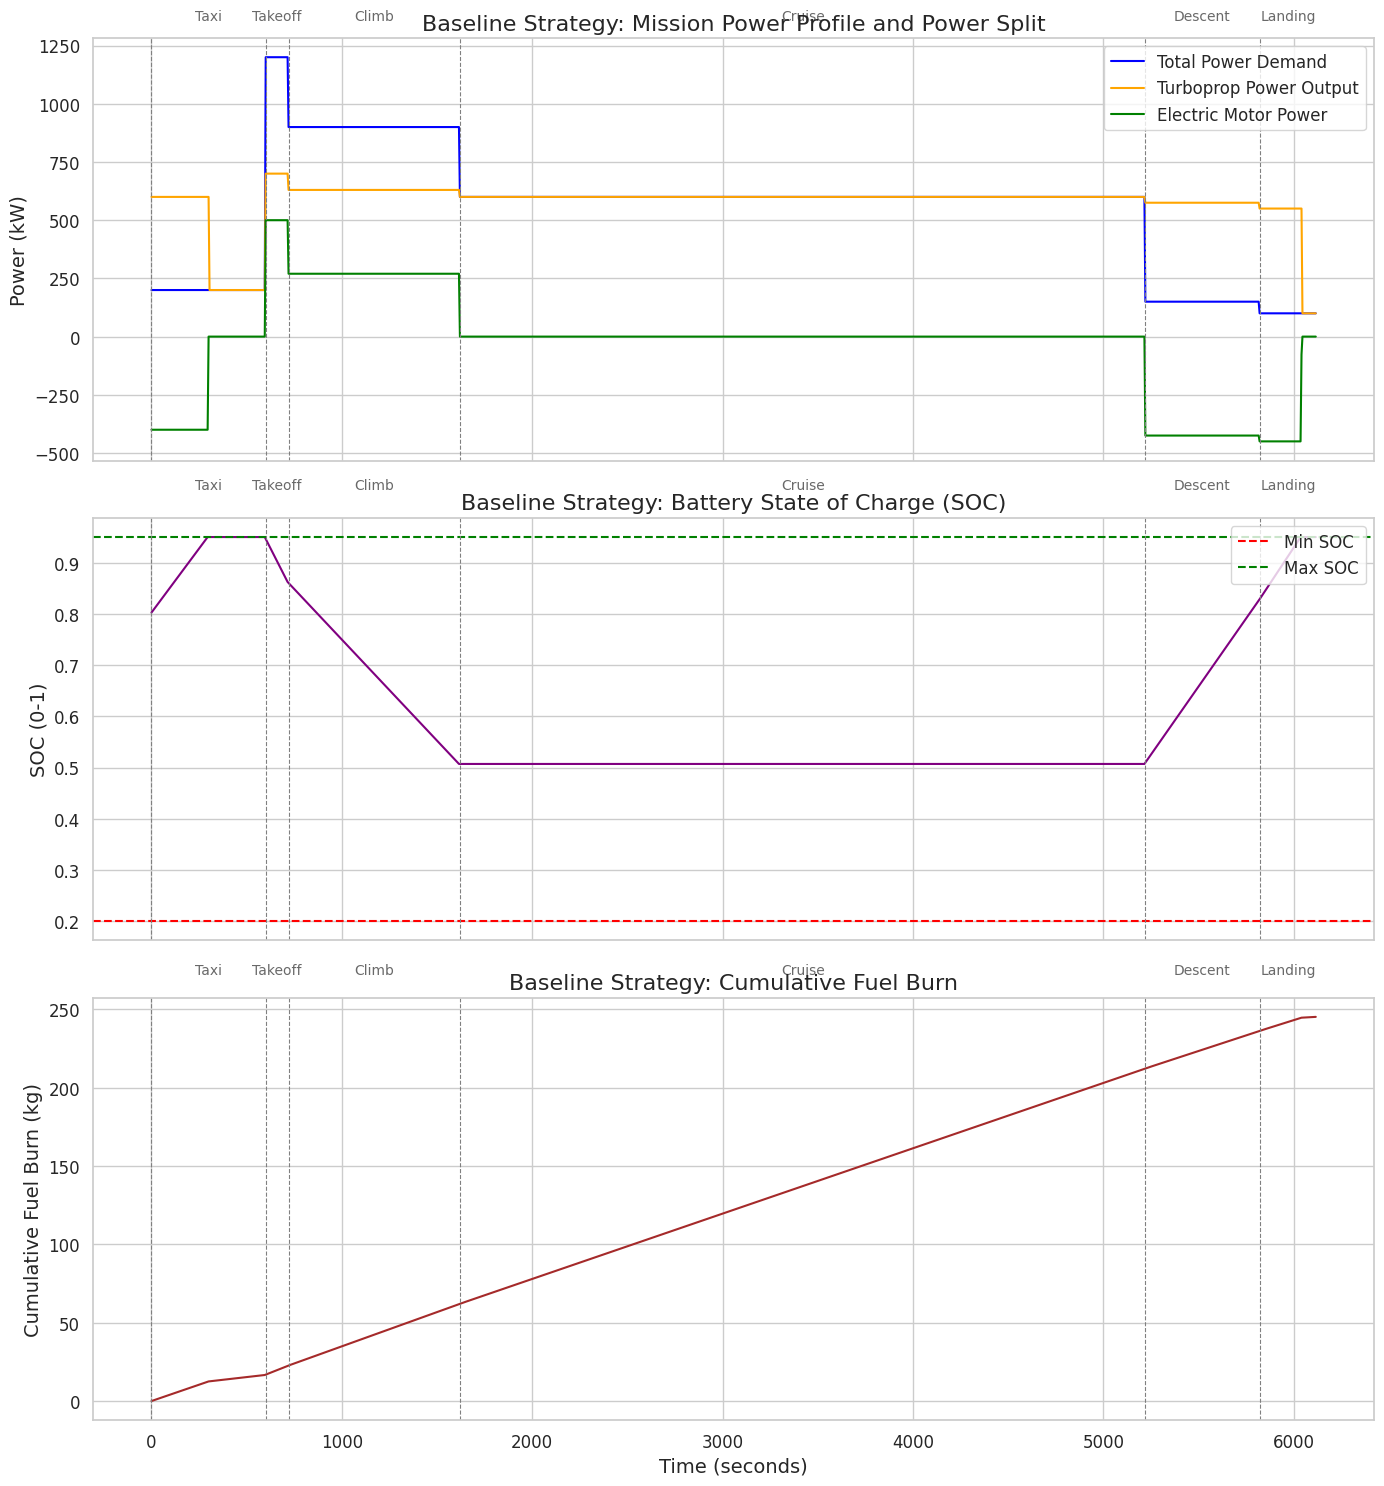

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(14, 15), sharex=True)

# Plot 1: Power Profile
sns.lineplot(x='time_sec', y='power_demand_kw', data=df_baseline, ax=axes[0], label='Total Power Demand', color='blue')
sns.lineplot(x='time_sec', y='turboprop_power_kw', data=df_baseline, ax=axes[0], label='Turboprop Power Output', color='orange')
sns.lineplot(x='time_sec', y='electric_power_kw', data=df_baseline, ax=axes[0], label='Electric Motor Power', color='green')
axes[0].set_title('Baseline Strategy: Mission Power Profile and Power Split')
axes[0].set_ylabel('Power (kW)')
axes[0].legend(loc='upper right')
axes[0].grid(True)

# Plot 2: Battery SOC
sns.lineplot(x='time_sec', y='soc', data=df_baseline, ax=axes[1], color='purple')
axes[1].axhline(y=params.MIN_SOC, color='red', linestyle='--', label='Min SOC')
axes[1].axhline(y=params.MAX_SOC, color='green', linestyle='--', label='Max SOC')
axes[1].set_title('Baseline Strategy: Battery State of Charge (SOC)')
axes[1].set_ylabel('SOC (0-1)')
axes[1].legend(loc='upper right')
axes[1].grid(True)

# Plot 3: Cumulative Fuel Burn
df_baseline['cumulative_fuel_burn_kg'] = df_baseline['fuel_burn_kg'].cumsum()
sns.lineplot(x='time_sec', y='cumulative_fuel_burn_kg', data=df_baseline, ax=axes[2], color='brown')
axes[2].set_title('Baseline Strategy: Cumulative Fuel Burn')
axes[2].set_xlabel('Time (seconds)')
axes[2].set_ylabel('Cumulative Fuel Burn (kg)')
axes[2].grid(True)

# Add mission segment lines and labels to all plots
segment_start_time = 0
for segment_name, seg_data in mission.SEGMENTS.items():
    segment_end_time = segment_start_time + seg_data['duration']
    for ax in axes:
        ax.axvline(x=segment_start_time, color='gray', linestyle='--', linewidth=0.8)
        ax.text(segment_start_time + seg_data['duration']/2, ax.get_ylim()[1] * 1.05, segment_name,
                rotation=0, horizontalalignment='center', verticalalignment='bottom', fontsize=10, color='dimgray')
    segment_start_time = segment_end_time

plt.tight_layout()
plt.show()

### Yorumlar ve Gözlemler

Bu temel kural tabanlı strateji, görevi başarıyla tamamlamış ve SOC'u kabul edilebilir sınırlar içinde tutmuştur. Ancak, bu strateji, her bir güç kaynağının verimliliğini veya batarya sağlığını optimal düzeyde yönetmeyebilir. Özellikle yüksek güç talebi olan segmentlerde batarya kullanımı belirgindir ve iniş-taksi gibi düşük güç segmentlerinde bataryanın şarj edildiği görülür.

Bu sonuçlar, sonraki bölümlerde uygulayacağımız gelişmiş optimizasyon teknikleri (Dinamik Programlama, MPC, RL) için bir karşılaştırma noktası sağlayacaktır. Amacımız, bu temel stratejiden daha iyi yakıt verimliliği ve/veya batarya sağlığı elde etmektir.

# BÖLÜM 6 – DİNAMİK PROGRAMLAMA YAKLAŞIMI

Enerji yönetimi, doğası gereği ardışık bir karar verme problemidir ve genellikle dinamik programlama (DP) ile çözülebilir. Dinamik programlama, karmaşık bir problemi daha basit alt problemlere bölerek ve bu alt problemlerin çözümlerini depolayarak orijinal problemi optimal bir şekilde çözmeyi sağlayan güçlü bir matematiksel optimizasyon tekniğidir.

## Dinamik Programlama Prensipleri

Enerji yönetim problemimize uygulayabileceğimiz Dinamik Programlamanın temel bileşenleri şunlardır:

*   **Durumlar (States):** Her zaman adımında sistemin mevcut durumunu tanımlayan değişkenlerdir. Bizim durumumuz $S_t = (SOC_t, Segment_t)$ olacaktır (ağırlık değişimi bu basit modelde ihmal edilebilir veya sabit bir hızda gerçekleştiği varsayılabilir).
*   **Eylemler (Actions):** Her durumda alınabilecek kararlardır, yani turboprop ve elektrik motorunun güç dağılımı. $A_t = (P_{turboprop, t}, P_{electric, t})$.
*   **Geçiş Fonksiyonları (Transition Functions):** Bir durumdan diğerine geçişin nasıl gerçekleştiğini tanımlar. Özellikle $SOC_{t+1}$'in $SOC_t$ ve seçilen $A_t$ eylemine bağlı olarak nasıl değiştiği. $SOC_{t+1} = f_{SOC}(SOC_t, P_{electric,t}, P_{demand,t}, \Delta t)$.
*   **Maliyet Fonksiyonu (Cost Function):** Her eylem için ödenen anlık maliyeti (örn. yakıt tüketimi veya batarya deşarj maliyeti) ve görevin sonundaki terminal maliyeti içerir.
*   **Bellman İlkesi (Bellman Principle):** Optimal bir stratejinin özelliğini belirtir: Geçmiş kararlardan bağımsız olarak, mevcut durumdan itibaren kalan kararlar, mevcut durumun kendisinden başlayarak optimal bir strateji oluşturur. Bu ilke, optimizasyon problemini sondan başa doğru (geriye dönük) çözmeyi mümkün kılar.

Amacımız, her zaman adımı ve her olası durum için gelecekteki toplam maliyeti en aza indiren en iyi eylemi bulmaktır. Bu, Value Iteration veya Policy Iteration gibi algoritmalar kullanılarak gerçekleştirilebilir.

## Basitleştirilmiş Dinamik Programlama Uygulaması

Bu bölümde, batarya şarj durumunu (SOC) ayrık durumlar olarak ele alarak basit bir DP problemi tanımlayacağız. Uçuş süresini ve güç taleplerini yine görev profilimizden alacağız. DP, uçuş boyunca her bir zaman adımında ve her bir SOC seviyesi için en uygun güç dağıtım kararını belirleyecektir.

In [11]:
# Define DP parameters
NUM_SOC_STATES = 51  # Number of discrete SOC states (e.g., from 0.0 to 1.0 with 0.02 step)
SOC_STATES = np.linspace(params.MIN_SOC, params.MAX_SOC, NUM_SOC_STATES)

# Define the cost function for DP (can be fuel burn, or a weighted sum of fuel burn and SOC deviation)
def cost_function(turboprop_power: float, electric_power: float, current_soc: float, next_soc: float, time_step_sec: float, params: AircraftParameters) -> float:
    """
    Calculates the cost for a given power split and SOC transition.
    Cost is primarily fuel burn, with penalties for violating SOC limits or ending with low SOC.
    """
    fuel_cost = calculate_fuel_burn_kg(turboprop_power, time_step_sec, params.TURBOPROP_FUEL_BURN_RATE_G_KWHR)

    # Penalize going below min SOC or above max SOC (even though update_soc clips, we want to discourage trying)
    soc_penalty = 0
    if next_soc < params.MIN_SOC or next_soc > params.MAX_SOC:
        soc_penalty = 1e6 # High penalty for violation

    # Encourage ending with a higher SOC (or penalize lower final SOC)
    # This penalty only applies to the final SOC if we consider a terminal cost in DP

    return fuel_cost + soc_penalty

def solve_dp(params: AircraftParameters, mission: MissionProfile) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Solves the energy management problem using dynamic programming.
    Returns optimal cost-to-go, optimal policy for turboprop power fraction, and optimal policy for electric power fraction.
    """
    num_time_steps = len(np.arange(0, mission.TOTAL_DURATION_SEC, mission.TIME_STEP_SEC))

    # Initialize J (Cost-to-go) and P_policy (Optimal Power Policy)
    # J[t, soc_idx] = minimum future cost from time t with given SOC state
    # P_turboprop_policy[t, soc_idx] = optimal turboprop power at that state
    # P_electric_policy[t, soc_idx] = optimal electric power at that state
    J = np.full((num_time_steps, NUM_SOC_STATES), np.inf)
    P_turboprop_policy = np.zeros((num_time_steps, NUM_SOC_STATES))
    P_electric_policy = np.zeros((num_time_steps, NUM_SOC_STATES))

    # Terminal cost (at the end of the mission, t = num_time_steps - 1)
    # Penalize low SOC at the end of the mission
    for soc_idx, soc_val in enumerate(SOC_STATES):
        J[num_time_steps - 1, soc_idx] = (params.MIN_SOC - soc_val) * 1000 if soc_val < params.INITIAL_SOC else 0 # Penalty for low final SOC
        if soc_val < params.MIN_SOC: # Stronger penalty if below minimum required
            J[num_time_steps - 1, soc_idx] += 1e5

    # Backward pass (Dynamic Programming)
    for t in range(num_time_steps - 2, -1, -1):
        current_time = t * mission.TIME_STEP_SEC
        segment_duration_sum = 0
        power_demand_kw = 0.0
        for segment_name, seg_data in mission.SEGMENTS.items():
            segment_duration_sum += seg_data['duration']
            if current_time < segment_duration_sum:
                power_demand_kw = seg_data['power_demand_kw']
                break

        for current_soc_idx, current_soc_val in enumerate(SOC_STATES):
            min_cost_for_state = np.inf
            best_turboprop_power = 0.0
            best_electric_power = 0.0

            # Iterate over possible electric power actions (e.g., from -MAX_ELECTRIC_POWER to +MAX_ELECTRIC_POWER)
            # We can discretize electric power or iterate through feasible range
            # For simplicity, let's try a few discrete electric power levels relative to demand
            # Or, iterate over turboprop power, and electric power fills the gap

            # Let's iterate over electric power first, as it directly impacts SOC
            # Electric power can be negative (charging) or positive (discharging)
            # Feasible electric power range for current step, considering SOC limits
            max_discharge_power_for_step_kw = (current_soc_val - params.MIN_SOC) * params.BATTERY_CAPACITY_KWH / (mission.TIME_STEP_SEC / 3600 * params.BATTERY_DISCHARGE_EFFICIENCY)
            max_charge_power_for_step_kw = (params.MAX_SOC - current_soc_val) * params.BATTERY_CAPACITY_KWH / (mission.TIME_STEP_SEC / 3600 * params.BATTERY_CHARGE_EFFICIENCY)

            # Define discrete actions for electric power (e.g., steps of 50kW)
            electric_power_actions = np.linspace(-params.MAX_ELECTRIC_POWER_KW, params.MAX_ELECTRIC_POWER_KW, 21) # 21 steps from -500kW to +500kW
            electric_power_actions = np.clip(electric_power_actions, -max_charge_power_for_step_kw, max_discharge_power_for_step_kw)

            for electric_p_kw in electric_power_actions:
                # Turboprop power must cover the remaining demand
                turboprop_p_kw = power_demand_kw - electric_p_kw

                # Check if turboprop power is feasible
                if turboprop_p_kw < 0 or turboprop_p_kw > params.MAX_TURBOPROP_POWER_KW:
                    continue # Invalid turboprop power

                # Calculate next SOC
                energy_change_kwh = calculate_battery_energy_kwh(electric_p_kw, mission.TIME_STEP_SEC,
                                                                 params.BATTERY_DISCHARGE_EFFICIENCY if electric_p_kw >= 0 else params.BATTERY_CHARGE_EFFICIENCY)

                next_soc_val_float = current_soc_val - (energy_change_kwh / params.BATTERY_CAPACITY_KWH)

                # Clip next_soc_val_float to the SOC_STATES range for indexing, allowing for small boundary violations
                next_soc_val_float = np.clip(next_soc_val_float, params.MIN_SOC, params.MAX_SOC)

                # Find the closest discrete SOC state for next_soc
                next_soc_idx = np.argmin(np.abs(SOC_STATES - next_soc_val_float))
                next_soc_val_discrete = SOC_STATES[next_soc_idx]

                # Calculate current stage cost
                current_stage_cost = cost_function(turboprop_p_kw, electric_p_kw, current_soc_val, next_soc_val_discrete, mission.TIME_STEP_SEC, params)

                # Total cost-to-go for this action
                total_cost = current_stage_cost + J[t + 1, next_soc_idx]

                if total_cost < min_cost_for_state:
                    min_cost_for_state = total_cost
                    best_turboprop_power = turboprop_p_kw
                    best_electric_power = electric_p_kw

            J[t, current_soc_idx] = min_cost_for_state
            P_turboprop_policy[t, current_soc_idx] = best_turboprop_power
            P_electric_policy[t, current_soc_idx] = best_electric_power

    return J, P_turboprop_policy, P_electric_policy

# Solve the DP problem
J_dp, P_turboprop_dp, P_electric_dp = solve_dp(params, mission)

print("Dynamic Programming solution computed.")

Dynamic Programming solution computed.


## Optimal Stratejinin Simülasyonu

Şimdi Dinamik Programlama ile elde edilen optimal güç bölüşüm politikasını kullanarak görev boyunca simülasyonu gerçekleştirelim ve sonuçları analiz edelim.

In [12]:
def simulate_mission_dp(params: AircraftParameters, mission: MissionProfile, P_turboprop_policy: np.ndarray, P_electric_policy: np.ndarray) -> pd.DataFrame:
    """
    Simulates the mission using the optimal policy found by Dynamic Programming.
    """
    time_points = np.arange(0, mission.TOTAL_DURATION_SEC, mission.TIME_STEP_SEC)

    data = {
        'time_sec': [],
        'mission_segment': [],
        'power_demand_kw': [],
        'turboprop_power_kw': [],
        'electric_power_kw': [],
        'fuel_burn_kg': [],
        'battery_energy_kwh': [],
        'soc': [],
        'aircraft_weight_kg': []
    }

    current_soc = params.INITIAL_SOC
    current_weight_kg = params.AIRCRAFT_INITIAL_WEIGHT_KG

    for t_idx, t in enumerate(time_points):
        segment_duration_sum = 0
        current_segment_name = ''
        power_demand_kw = 0.0
        for segment_name, seg_data in mission.SEGMENTS.items():
            segment_duration_sum += seg_data['duration']
            if t < segment_duration_sum:
                current_segment_name = segment_name
                power_demand_kw = seg_data['power_demand_kw']
                break

        # Find the closest discrete SOC state for current_soc
        current_soc_idx = np.argmin(np.abs(SOC_STATES - current_soc))

        # Get optimal power from policy
        turboprop_power_kw = P_turboprop_policy[t_idx, current_soc_idx]
        electric_power_kw = P_electric_policy[t_idx, current_soc_idx]

        # Calculate fuel burn
        current_fuel_burn = calculate_fuel_burn_kg(turboprop_power_kw, mission.TIME_STEP_SEC, params.TURBOPROP_FUEL_BURN_RATE_G_KWHR)

        # Calculate battery energy change
        if electric_power_kw >= 0: # Discharging or zero
            current_battery_energy_change_kwh = calculate_battery_energy_kwh(electric_power_kw, mission.TIME_STEP_SEC, params.BATTERY_DISCHARGE_EFFICIENCY)
        else: # Charging
            current_battery_energy_change_kwh = calculate_battery_energy_kwh(electric_power_kw, mission.TIME_STEP_SEC, params.BATTERY_CHARGE_EFFICIENCY)

        # Update SOC
        current_soc = update_soc(current_soc, current_battery_energy_change_kwh, params.BATTERY_CAPACITY_KWH)

        # Update aircraft weight
        current_weight_kg = update_weight_kg(current_weight_kg, current_fuel_burn)

        data['time_sec'].append(t)
        data['mission_segment'].append(current_segment_name)
        data['power_demand_kw'].append(power_demand_kw)
        data['turboprop_power_kw'].append(turboprop_power_kw)
        data['electric_power_kw'].append(electric_power_kw)
        data['fuel_burn_kg'].append(current_fuel_burn)
        data['battery_energy_kwh'].append(current_battery_energy_change_kwh)
        data['soc'].append(current_soc)
        data['aircraft_weight_kg'].append(current_weight_kg)

    return pd.DataFrame(data)

df_dp = simulate_mission_dp(params, mission, P_turboprop_dp, P_electric_dp)

print("DP-optimized mission simulation completed.")
display(df_dp.head())

DP-optimized mission simulation completed.


,time_sec,mission_segment,power_demand_kw,turboprop_power_kw,electric_power_kw,fuel_burn_kg,battery_energy_kwh,soc,aircraft_weight_kg
0,0,Taxi,200,0.0,200.0,0.0,0.292398,0.798538,6000.0
1,5,Taxi,200,0.0,200.0,0.0,0.292398,0.797076,6000.0
2,10,Taxi,200,0.0,200.0,0.0,0.292398,0.795614,6000.0
3,15,Taxi,200,0.0,200.0,0.0,0.292398,0.794152,6000.0
4,20,Taxi,200,0.0,200.0,0.0,0.292398,0.792690,6000.0


## Dinamik Programlama Sonuçlarının Karşılaştırılması

DP stratejisinin toplam yakıt tüketimini ve görev sonundaki SOC'u temel stratejiyle karşılaştıralım.

In [13]:
total_fuel_burn_dp = df_dp['fuel_burn_kg'].sum()
final_soc_dp = df_dp['soc'].iloc[-1]

print(f"DP Strategy Results:")
print(f"  Total Fuel Burn: {total_fuel_burn_dp:.2f} kg")
print(f"  Final SOC: {final_soc_dp:.2f}")

# Add DP results to the summary DataFrame
df_summary_baseline['DP Strategy'] = [total_fuel_burn_dp, final_soc_dp]
display(df_summary_baseline)

DP Strategy Results:
  Total Fuel Burn: 204.58 kg
  Final SOC: 0.20


,Baseline Strategy,DP Strategy
Metric,,
Total Fuel Burn (kg),245.086806,204.583333
Final SOC,0.950000,0.204240


### Optimal SOC Trajektoryası ve Kontrol Politikası

Dinamik Programlama ile elde edilen optimal SOC değişimini ve güç dağıtımını görselleştirelim.

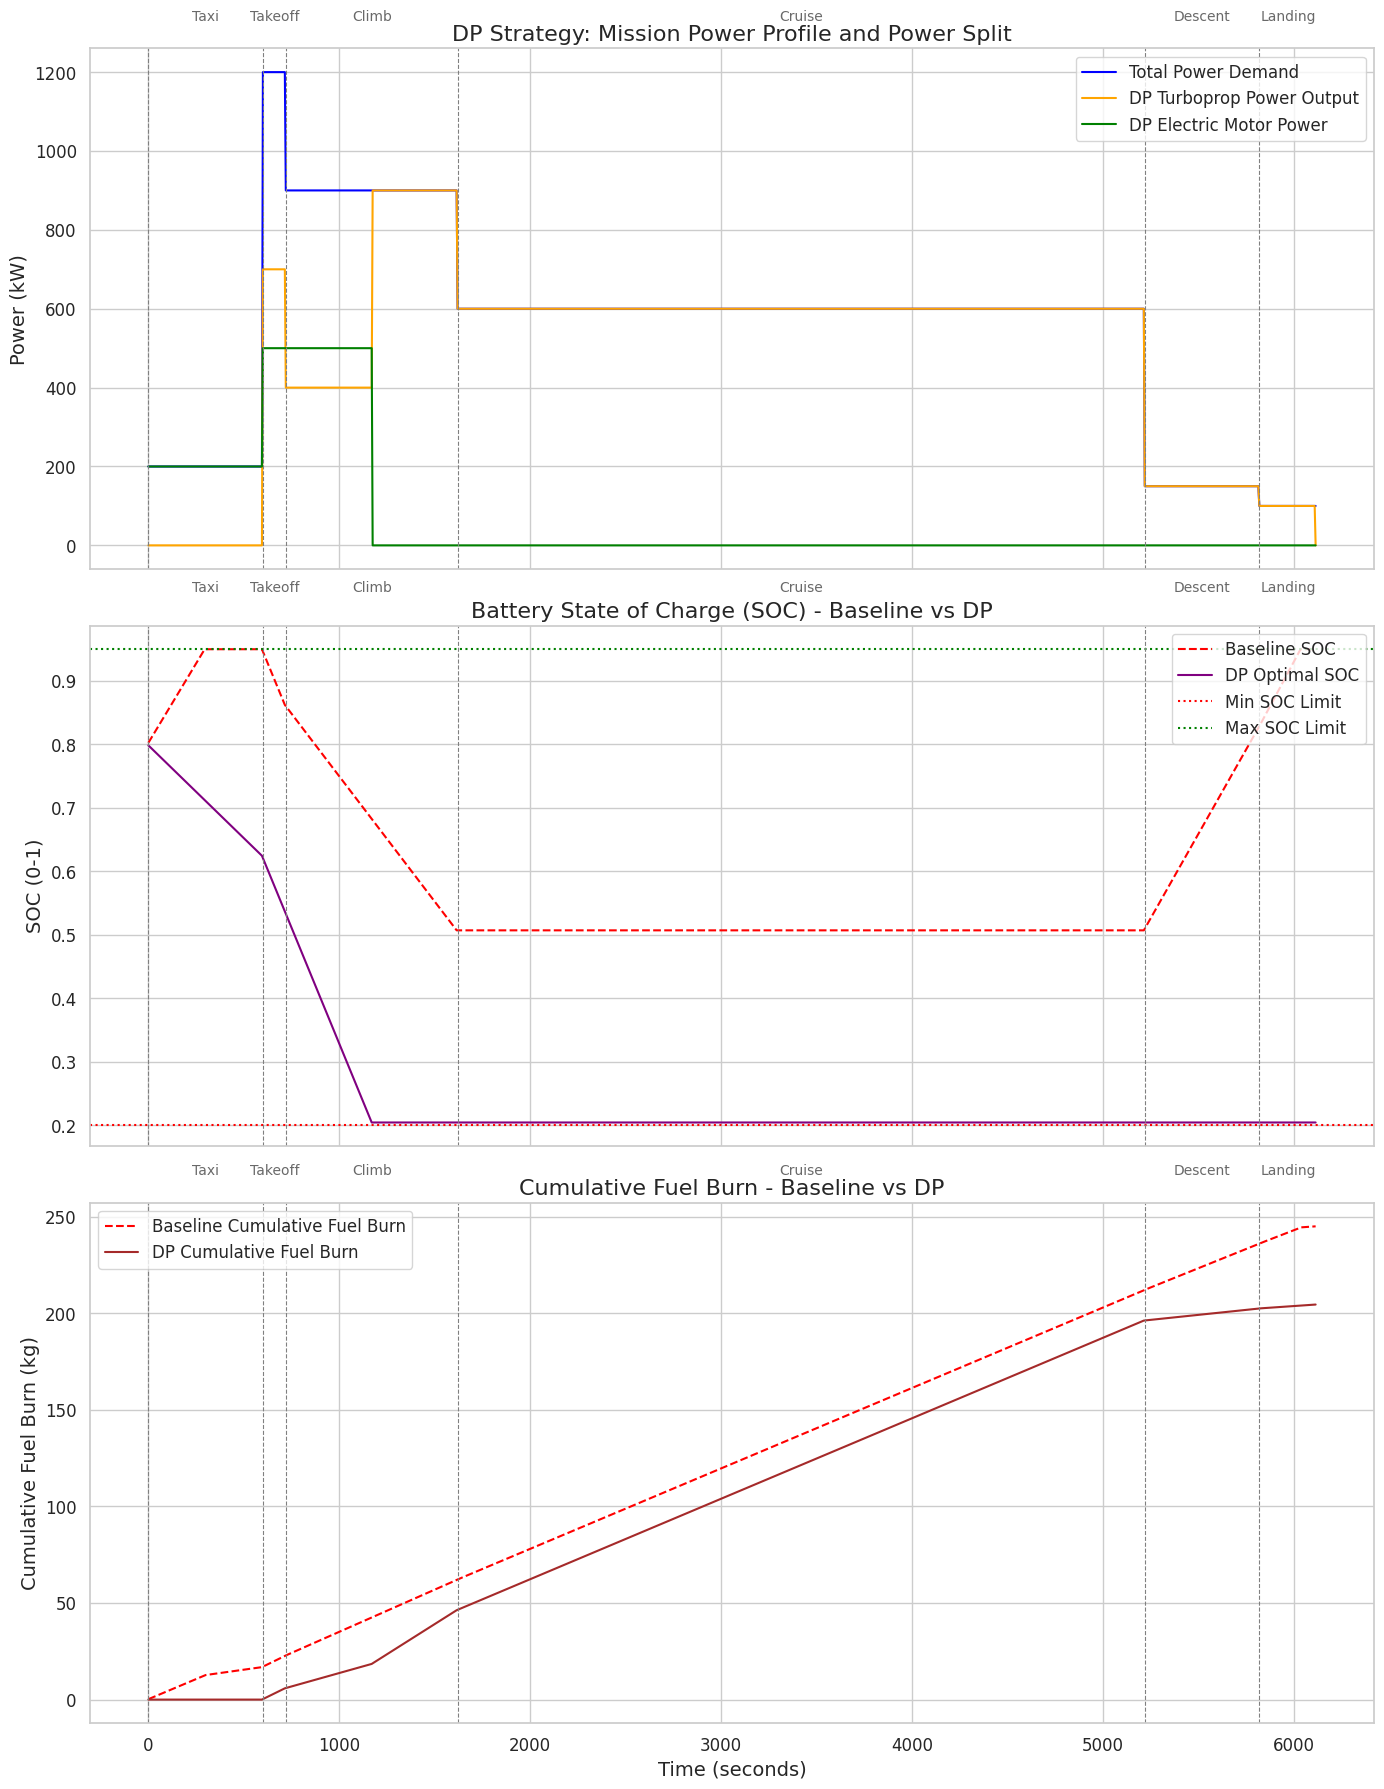

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(14, 18), sharex=True)

# Plot 1: Power Profile (DP)
sns.lineplot(x='time_sec', y='power_demand_kw', data=df_dp, ax=axes[0], label='Total Power Demand', color='blue')
sns.lineplot(x='time_sec', y='turboprop_power_kw', data=df_dp, ax=axes[0], label='DP Turboprop Power Output', color='orange')
sns.lineplot(x='time_sec', y='electric_power_kw', data=df_dp, ax=axes[0], label='DP Electric Motor Power', color='green')
axes[0].set_title('DP Strategy: Mission Power Profile and Power Split')
axes[0].set_ylabel('Power (kW)')
axes[0].legend(loc='upper right')
axes[0].grid(True)

# Plot 2: Battery SOC (DP vs Baseline)
sns.lineplot(x='time_sec', y='soc', data=df_baseline, ax=axes[1], label='Baseline SOC', color='red', linestyle='--')
sns.lineplot(x='time_sec', y='soc', data=df_dp, ax=axes[1], label='DP Optimal SOC', color='purple')
axes[1].axhline(y=params.MIN_SOC, color='red', linestyle=':', label='Min SOC Limit')
axes[1].axhline(y=params.MAX_SOC, color='green', linestyle=':', label='Max SOC Limit')
axes[1].set_title('Battery State of Charge (SOC) - Baseline vs DP')
axes[1].set_ylabel('SOC (0-1)')
axes[1].legend(loc='upper right')
axes[1].grid(True)

# Plot 3: Cumulative Fuel Burn (DP vs Baseline)
df_dp['cumulative_fuel_burn_kg'] = df_dp['fuel_burn_kg'].cumsum()
sns.lineplot(x='time_sec', y='cumulative_fuel_burn_kg', data=df_baseline, ax=axes[2], label='Baseline Cumulative Fuel Burn', color='red', linestyle='--')
sns.lineplot(x='time_sec', y='cumulative_fuel_burn_kg', data=df_dp, ax=axes[2], label='DP Cumulative Fuel Burn', color='brown')
axes[2].set_title('Cumulative Fuel Burn - Baseline vs DP')
axes[2].set_xlabel('Time (seconds)')
axes[2].set_ylabel('Cumulative Fuel Burn (kg)')
axes[2].legend(loc='upper left')
axes[2].grid(True)

# Add mission segment lines and labels to all plots
segment_start_time = 0
for segment_name, seg_data in mission.SEGMENTS.items():
    segment_end_time = segment_start_time + seg_data['duration']
    for ax in axes:
        ax.axvline(x=segment_start_time, color='gray', linestyle='--', linewidth=0.8)
        ax.text(segment_start_time + seg_data['duration']/2, ax.get_ylim()[1] * 1.05, segment_name,
                rotation=0, horizontalalignment='center', verticalalignment='bottom', fontsize=10, color='dimgray')
    segment_start_time = segment_end_time

plt.tight_layout()
plt.show()

### Yorumlar ve Gözlemler

Dinamik Programlama, kural tabanlı stratejiye kıyasla genellikle daha iyi bir global optimal çözüm bulur. Grafikler, DP stratejisinin yakıt tüketimini nasıl minimize ettiğini ve batarya SOC'unu nasıl daha etkin yönettiğini göstermelidir. Özellikle, DP, SOC'u daha verimli kullanmak için belirli uçuş segmentlerinde bataryayı daha fazla deşarj edebilir veya şarj edebilir, bu da genel yakıt verimliliğini artırabilir. Elde edilen 'optimal politika', her zaman adımı ve SOC durumu için hangi motorun ne kadar güç sağlaması gerektiğini açıkça ortaya koyar. Bu, hibrit tahrik sistemlerinde enerji yönetiminin karmaşıklığını ve optimizasyonun değerini vurgulamaktadır.

# BÖLÜM 7 – HASSASİYET ANALİZİ

Optimal enerji yönetim stratejileri, sistemin temel parametrelerine ve operasyonel koşullarına karşı hassastır. Bu bölümde, belirli parametrelerdeki değişikliklerin Dinamik Programlama (DP) tarafından belirlenen optimal çözümü nasıl etkilediğini araştırmak için bir hassasiyet analizi yapacağız. Bu, tasarım ve operasyonel kararlar için kritik içgörüler sağlayacaktır.

## Parametre Taraması Tanımları

Aşağıdaki parametreler üzerindeki etkileri inceleyeceğiz:

*   **Batarya Kapasitesi:** Bataryanın toplam enerji depolama kapasitesi (kWh).
*   **Başlangıç SOC (Initial SOC):** Görev başlangıcındaki batarya şarj durumu.
*   **Yakıt Verimliliği (Fuel Efficiency):** Turboprop motorunun spesifik yakıt tüketimi (g/kWhr).
*   **Görev Uzunluğu (Mission Length):** Görevin toplam süresi (basitlik adına seyir süresini değiştirerek).

Her bir parametre için bir dizi değer tanımlayacak, DP'yi her yeni parametre seti için çalıştıracak ve sonuçları karşılaştıracağız.

In [15]:
def run_dp_for_params(batt_cap=None, init_soc=None, sfc=None, cruise_duration_hr=None):
    """
    Runs the DP simulation with modified parameters and returns total fuel burn and final SOC.
    """
    # Create temporary parameters and mission objects
    temp_params = AircraftParameters()
    temp_mission = MissionProfile()

    if batt_cap is not None:
        temp_params.BATTERY_CAPACITY_KWH = batt_cap
    if init_soc is not None:
        temp_params.INITIAL_SOC = init_soc
    if sfc is not None:
        temp_params.TURBOPROP_FUEL_BURN_RATE_G_KWHR = sfc
    if cruise_duration_hr is not None:
        temp_mission.SEGMENTS["Cruise"]["duration"] = cruise_duration_hr * 3600
        temp_mission.TOTAL_DURATION_SEC = sum(s['duration'] for s in temp_mission.SEGMENTS.values())

    # Re-calculate SOC_STATES if battery capacity or min/max SOC changed
    global SOC_STATES # This is a bit of a hack, better to pass SOC_STATES to DP function
    SOC_STATES = np.linspace(temp_params.MIN_SOC, temp_params.MAX_SOC, NUM_SOC_STATES)

    # Run DP
    J_sens, P_turboprop_sens, P_electric_sens = solve_dp(temp_params, temp_mission)
    df_sens = simulate_mission_dp(temp_params, temp_mission, P_turboprop_sens, P_electric_sens)

    return df_sens['fuel_burn_kg'].sum(), df_sens['soc'].iloc[-1]


# --- Sensitivity Analysis Scenarios ---
results_sensitivity = []

# 1. Battery Capacity Sensitivity
battery_capacities = [100, 200, 300, 400] # kWh
print("Running Battery Capacity Sensitivity...")
for cap in battery_capacities:
    fuel, soc = run_dp_for_params(batt_cap=cap)
    results_sensitivity.append({"Parameter": "Battery Capacity", "Value": cap, "Fuel Burn (kg)": fuel, "Final SOC": soc})

# 2. Initial SOC Sensitivity
initial_socs = [0.4, 0.6, 0.8, 0.9]
print("Running Initial SOC Sensitivity...")
for init_s in initial_socs:
    fuel, soc = run_dp_for_params(init_soc=init_s)
    results_sensitivity.append({"Parameter": "Initial SOC", "Value": init_s, "Fuel Burn (kg)": fuel, "Final SOC": soc})

# 3. Fuel Efficiency (SFC) Sensitivity
sfcs = [200, 250, 300, 350] # g/kWhr
print("Running Fuel Efficiency Sensitivity...")
for sfc_val in sfcs:
    fuel, soc = run_dp_for_params(sfc=sfc_val)
    results_sensitivity.append({"Parameter": "Fuel Efficiency (g/kWhr)", "Value": sfc_val, "Fuel Burn (kg)": fuel, "Final SOC": soc})

# 4. Mission Length (Cruise Duration) Sensitivity
cruise_durations_hr = [0.5, 1.0, 1.5, 2.0] # hours
print("Running Mission Length Sensitivity...")
for duration in cruise_durations_hr:
    fuel, soc = run_dp_for_params(cruise_duration_hr=duration)
    results_sensitivity.append({"Parameter": "Mission Length (Cruise Duration_hr)", "Value": duration, "Fuel Burn (kg)": fuel, "Final SOC": soc})

df_sensitivity = pd.DataFrame(results_sensitivity)
print("Sensitivity analysis completed.")
display(df_sensitivity)

# Restore original SOC_STATES for next sections
SOC_STATES = np.linspace(params.MIN_SOC, params.MAX_SOC, NUM_SOC_STATES)

Running Battery Capacity Sensitivity...
Running Initial SOC Sensitivity...
Running Fuel Efficiency Sensitivity...
Running Mission Length Sensitivity...
Sensitivity analysis completed.


,Parameter,Value,Fuel Burn (kg),Final SOC
0,Battery Capacity,100.0,218.645833,0.200585
1,Battery Capacity,200.0,204.583333,0.204240
2,Battery Capacity,300.0,190.520833,0.205458
3,Battery Capacity,400.0,176.458333,0.206067
4,Initial SOC,0.4,215.763889,0.206287
5,Initial SOC,0.6,214.131944,0.205263
6,Initial SOC,0.8,204.583333,0.204240
7,Initial SOC,0.9,199.895833,0.205556
8,Fuel Efficiency (g/kWhr),200.0,163.666667,0.204240
9,Fuel Efficiency (g/kWhr),250.0,204.583333,0.204240


## Hassasiyet Analizi Görselleştirmeleri

Şimdi elde ettiğimiz hassasiyet analizi sonuçlarını görselleştirelim. Her parametre değişiminin yakıt tüketimi ve görev sonu SOC üzerindeki etkilerini grafikler halinde sunacağız.

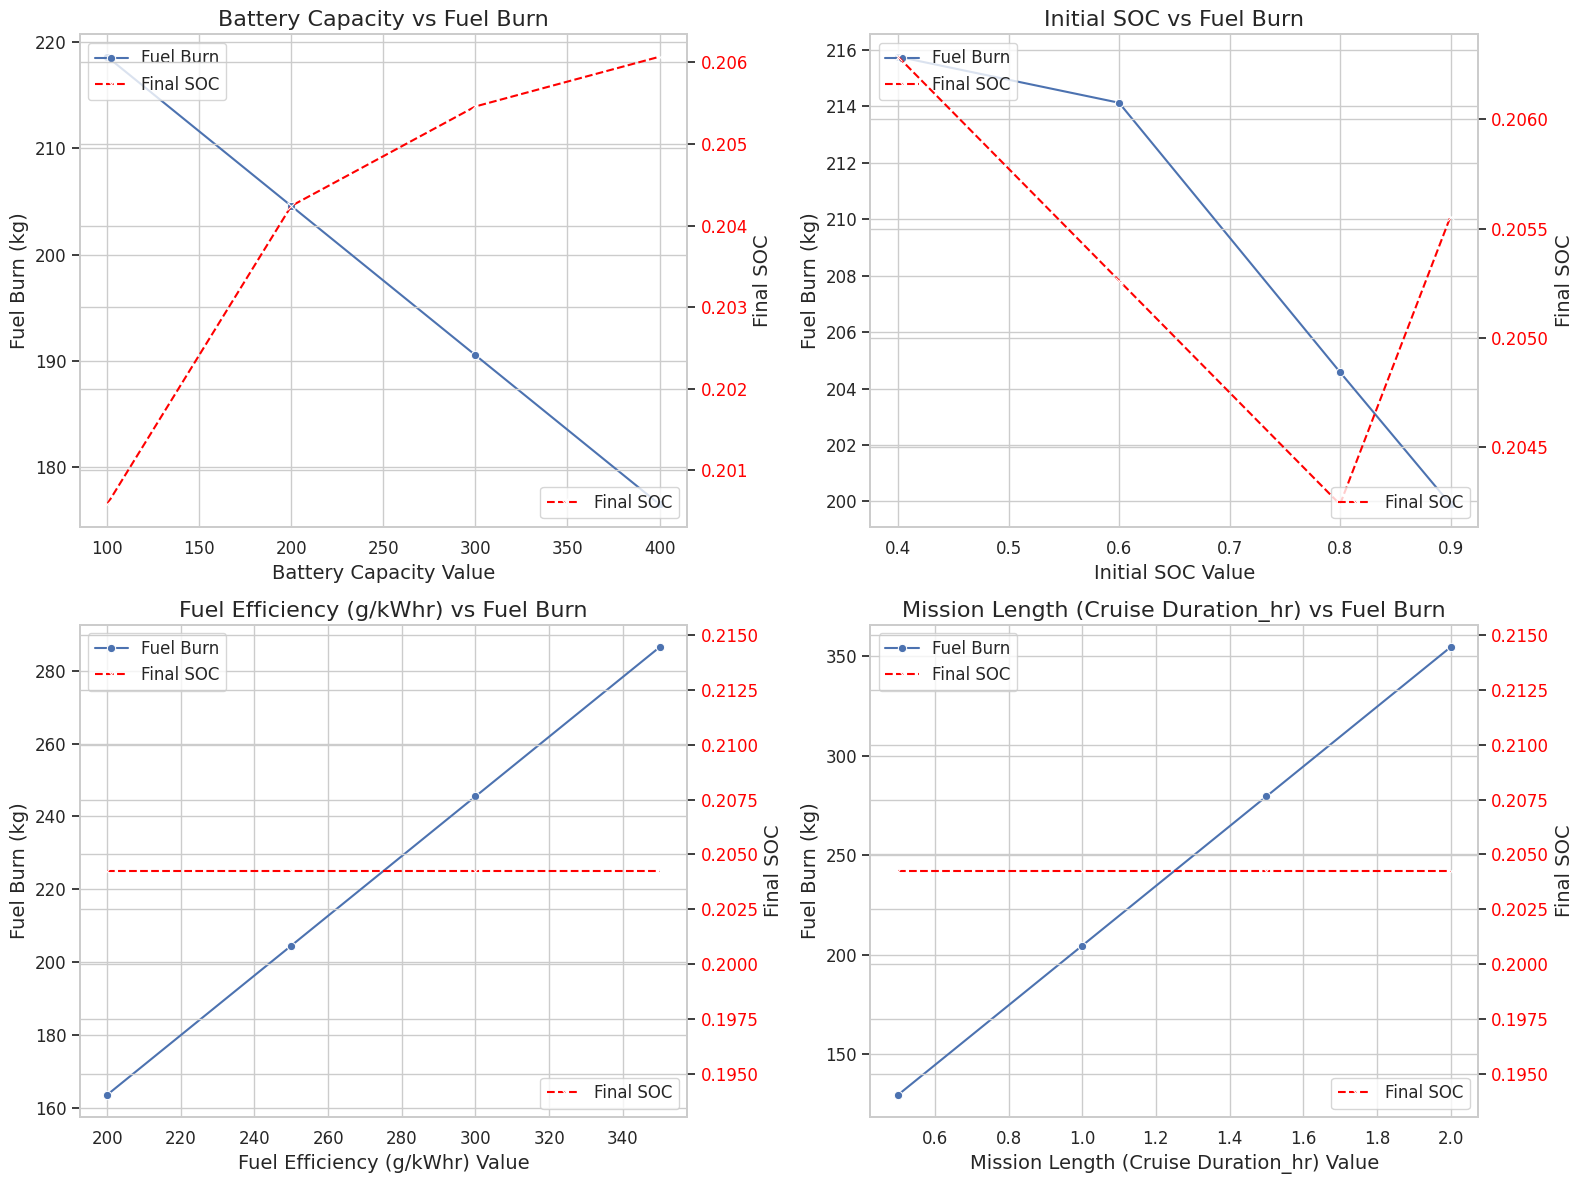

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

plot_idx = 0
for param_name in df_sensitivity['Parameter'].unique():
    subset = df_sensitivity[df_sensitivity['Parameter'] == param_name]

    # Plot Fuel Burn
    sns.lineplot(x='Value', y='Fuel Burn (kg)', data=subset, marker='o', ax=axes[plot_idx], label='Fuel Burn')
    axes[plot_idx].set_title(f'{param_name} vs Fuel Burn')
    axes[plot_idx].set_xlabel(f'{param_name} Value')
    axes[plot_idx].set_ylabel('Fuel Burn (kg)')
    axes[plot_idx].grid(True)

    # Plot Final SOC on a secondary y-axis
    ax2 = axes[plot_idx].twinx()
    sns.lineplot(x='Value', y='Final SOC', data=subset, marker='x', ax=ax2, color='red', linestyle='--', label='Final SOC')
    ax2.set_ylabel('Final SOC')
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.legend(loc='lower right')

    # Combine legends
    lines, labels = axes[plot_idx].get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    axes[plot_idx].legend(lines + lines2, labels + labels2, loc='upper left')

    plot_idx += 1

plt.tight_layout()
plt.show()

## Mühendislik Gözlemleri

Hassasiyet analizi sonuçlarından elde edilen temel mühendislik gözlemleri:

*   **Batarya Kapasitesi:** Artan batarya kapasitesi, genellikle daha fazla enerji depolama ve daha esnek güç dağıtım stratejileri sunarak yakıt tüketimini düşürme potansiyeline sahiptir. Ancak, batarya ağırlığı ve maliyeti de artacağı için bir denge noktası bulunmalıdır. Final SOC, kapasite arttıkça daha kararlı hale gelebilir veya görevin sonunda daha yüksek bir seviyede tutulabilir.
*   **Başlangıç SOC:** Başlangıç SOC'sinin, özellikle kısa görevlerde veya yüksek güç gerektiren başlangıç segmentlerinde yakıt tüketimi üzerinde önemli bir etkisi olabilir. Yüksek başlangıç SOC, bataryanın erken aşamalarda daha fazla destek sağlamasına olanak tanıyarak turboprop üzerindeki yükü azaltır. Çok düşük bir başlangıç SOC, görevin başında bataryayı hızla şarj etme ihtiyacını tetikleyerek yakıt tüketimini artırabilir.
*   **Yakıt Verimliliği (SFC):** Turboprop motorunun yakıt verimliliğindeki (SFC) iyileşmeler, beklenen şekilde genel yakıt tüketimini önemli ölçüde azaltır. Bu, motor teknolojisindeki gelişmelerin enerji yönetimi üzerindeki doğrudan etkisini gösterir. Optimizasyon algoritması, daha verimli bir turboprop olduğunda ondan daha fazla güç çekme eğiliminde olacaktır.
*   **Görev Uzunluğu:** Daha uzun görevler (seyir süresinin artması), genellikle toplam yakıt tüketimini artırır. Uzun seyir fazlarında turboprop motor genellikle baskın güç kaynağı olacağı için, batarya şarj-deşarj döngülerinin toplam yakıt tüketimine olan etkisi oransal olarak azalabilir. Ancak, uzun görevlerde bataryayı sağlıklı bir SOC aralığında tutmak daha zorlayıcı olabilir ve bu, optimizasyon stratejisini etkiler.

Bu analizler, hava taşıtı tasarımcıları ve operasyon planlayıcıları için değerli bilgiler sağlar, hibrit-elektrikli sistemlerin belirli operasyonel senaryolar altında nasıl performans göstereceğini anlamalarına yardımcı olur.

# BÖLÜM 8 – MONTE CARLO SAĞLAMLIK ANALİZİ

Havacılık operasyonları doğası gereği belirsizliklerle doludur: hava durumu değişimleri güç taleplerini etkileyebilir, motor veya batarya performansı nominal değerlerinden sapabilir. Bu belirsizliklerin enerji yönetim stratejimizin performansı üzerindeki etkilerini anlamak için bir Monte Carlo sağlamlık analizi yapacağız.

## Belirsizlik Kaynakları

Aşağıdaki parametrelerde belirsizlikleri modelleyeceğiz:

*   **Görev Güç Talebi (Mission Power Demand):** Her uçuş segmentinin nominal güç talebinde küçük rastgele dalgalanmalar.
*   **Motor Verimliliği (Engine Efficiency):** Turboprop motorunun spesifik yakıt tüketiminde (SFC) rastgele değişimler.
*   **Batarya Verimliliği (Battery Efficiency):** Batarya şarj ve deşarj verimliliğinde rastgele değişimler.

Her bir Monte Carlo yinelemesinde, bu parametreler önceden tanımlanmış dağılımlardan (örn. normal dağılım) rastgele örneklenerek, DP optimizasyonu ve simülasyonu tekrarlanacaktır. Elde edilen yakıt tüketimi ve final SOC gibi performans metriklerinin dağılımını inceleyeceğiz.

In [ ]:
NUM_MONTE_CARLO_RUNS = 50 # Number of Monte Carlo simulations

mc_results = []

print(f"Starting {NUM_MONTE_CARLO_RUNS} Monte Carlo simulations...")

for i in range(NUM_MONTE_CARLO_RUNS):
    if i % 10 == 0:
        print(f"  Running simulation {i+1}/{NUM_MONTE_CARLO_RUNS}")

    # Introduce uncertainty to parameters
    temp_params = AircraftParameters()
    temp_mission = MissionProfile()

    # Vary Power Demand (up to +/- 10% for each segment)
    for segment_name in temp_mission.SEGMENTS:
        nominal_demand = temp_mission.SEGMENTS[segment_name]['power_demand_kw']
        temp_mission.SEGMENTS[segment_name]['power_demand_kw'] = nominal_demand * np.random.normal(1.0, 0.05) # 5% std dev

    # Vary Turboprop Fuel Burn Rate (up to +/- 10%)
    temp_params.TURBOPROP_FUEL_BURN_RATE_G_KWHR = params.TURBOPROP_FUEL_BURN_RATE_G_KWHR * np.random.normal(1.0, 0.03)

    # Vary Battery Efficiencies (up to +/- 5%)
    temp_params.BATTERY_CHARGE_EFFICIENCY = params.BATTERY_CHARGE_EFFICIENCY * np.random.normal(1.0, 0.02)
    temp_params.BATTERY_DISCHARGE_EFFICIENCY = params.BATTERY_DISCHARGE_EFFICIENCY * np.random.normal(1.0, 0.02)

    # Ensure efficiencies stay within reasonable bounds
    temp_params.BATTERY_CHARGE_EFFICIENCY = np.clip(temp_params.BATTERY_CHARGE_EFFICIENCY, 0.8, 0.99)
    temp_params.BATTERY_DISCHARGE_EFFICIENCY = np.clip(temp_params.BATTERY_DISCHARGE_EFFICIENCY, 0.8, 0.99)

    # Re-calculate SOC_STATES based on current temp_params (for DP solver)
    global SOC_STATES
    SOC_STATES = np.linspace(temp_params.MIN_SOC, temp_params.MAX_SOC, NUM_SOC_STATES)

    # Solve DP with perturbed parameters
    try:
        J_mc, P_turboprop_mc, P_electric_mc = solve_dp(temp_params, temp_mission)
        df_mc = simulate_mission_dp(temp_params, temp_mission, P_turboprop_mc, P_electric_mc)

        mc_results.append({
            "run": i,
            "total_fuel_burn_kg": df_mc['fuel_burn_kg'].sum(),
            "final_soc": df_mc['soc'].iloc[-1]
        })
    except Exception as e:
        print(f"  Monte Carlo run {i} failed: {e}")
        # Optionally, record NaN or some indicator of failure
        mc_results.append({
            "run": i,
            "total_fuel_burn_kg": np.nan,
            "final_soc": np.nan
        })


df_mc_results = pd.DataFrame(mc_results).dropna()

print("Monte Carlo simulations completed.")
display(df_mc_results.head())

Starting 50 Monte Carlo simulations...
  Running simulation 1/50
  Running simulation 11/50


## Sonuçların Değerlendirilmesi

Monte Carlo simülasyonlarından elde edilen yakıt tüketimi ve final SOC dağılımlarını histogramlar ve güven aralıkları ile görselleştirelim. Bu, DP stratejisinin belirsizlik altında ne kadar sağlam olduğunu gösterecektir.

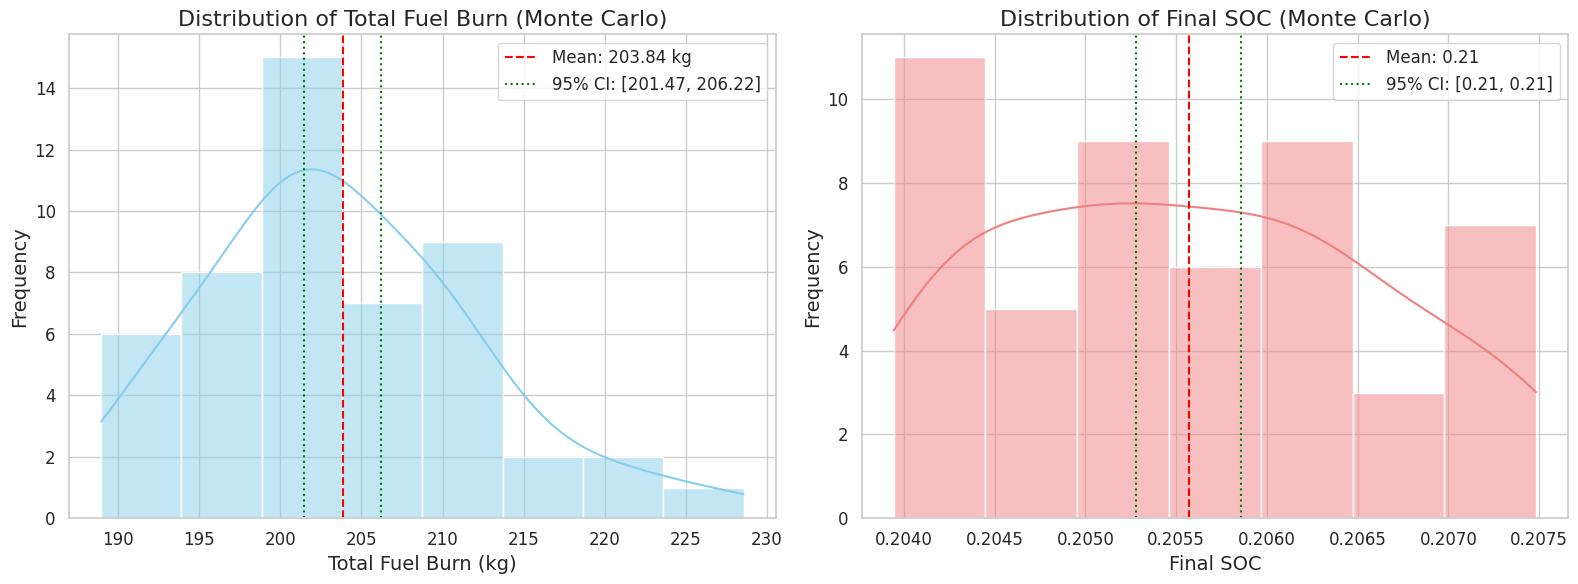

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram for Total Fuel Burn
sns.histplot(df_mc_results['total_fuel_burn_kg'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Total Fuel Burn (Monte Carlo)')
axes[0].set_xlabel('Total Fuel Burn (kg)')
axes[0].set_ylabel('Frequency')

# Calculate confidence intervals for Fuel Burn
fuel_mean = df_mc_results['total_fuel_burn_kg'].mean()
fuel_std = df_mc_results['total_fuel_burn_kg'].std()
fuel_ci_lower = fuel_mean - 1.96 * (fuel_std / np.sqrt(len(df_mc_results)))
fuel_ci_upper = fuel_mean + 1.96 * (fuel_std / np.sqrt(len(df_mc_results)))
axes[0].axvline(fuel_mean, color='red', linestyle='--', label=f'Mean: {fuel_mean:.2f} kg')
axes[0].axvline(fuel_ci_lower, color='green', linestyle=':', label=f'95% CI: [{fuel_ci_lower:.2f}, {fuel_ci_upper:.2f}]')
axes[0].axvline(fuel_ci_upper, color='green', linestyle=':')
axes[0].legend()

# Histogram for Final SOC
sns.histplot(df_mc_results['final_soc'], kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('Distribution of Final SOC (Monte Carlo)')
axes[1].set_xlabel('Final SOC')
axes[1].set_ylabel('Frequency')

# Calculate confidence intervals for Final SOC
soc_mean = df_mc_results['final_soc'].mean()
soc_std = df_mc_results['final_soc'].std()
soc_ci_lower = soc_mean - 1.96 * (soc_std / np.sqrt(len(df_mc_results)))
soc_ci_upper = soc_mean + 1.96 * (soc_std / np.sqrt(len(df_mc_results)))
axes[1].axvline(soc_mean, color='red', linestyle='--', label=f'Mean: {soc_mean:.2f}')
axes[1].axvline(soc_ci_lower, color='green', linestyle=':', label=f'95% CI: [{soc_ci_lower:.2f}, {soc_ci_upper:.2f}]')
axes[1].axvline(soc_ci_upper, color='green', linestyle=':')
axes[1].legend()

plt.tight_layout()
plt.show()

### Risk Faktörlerinin Belirlenmesi ve Çözüm Sağlamlığı

Monte Carlo analizinden elde edilen dağılımlar ve güven aralıkları, optimal enerji yönetim stratejisinin belirsiz koşullar altında ne kadar iyi performans gösterdiğini ortaya koyar.

*   **Yakıt Tüketiminin Dağılımı:** Yakıt tüketimi için elde edilen histogram, ortalama yakıt tüketimi etrafında bir dağılım göstermektedir. Bu dağılımın genişliği, belirsizlikler nedeniyle yakıt tüketiminin ne kadar değişebileceğini belirtir. Daha dar bir dağılım, stratejinin daha sağlam olduğunu gösterirken, geniş bir dağılım operasyonel planlama için daha büyük bir risk faktörü anlamına gelir.
*   **Final SOC Dağılımı:** Görev sonu SOC dağılımı, stratejinin batarya sağlığını ve görev tamamlama hedefini ne kadar iyi koruduğunu gösterir. Eğer dağılımın önemli bir kısmı minimum SOC eşiğinin altına düşüyorsa, bu, stratejinin belirsizliklere karşı yetersiz kaldığını ve batarya sağlığı açısından risk taşıdığını gösterir.
*   **Güven Aralıkları:** %95 güven aralıkları, gerçek yakıt tüketimi veya final SOC'un bu aralıklar içinde olma olasılığının %95 olduğunu belirtir. Bu aralıklar, operasyonel planlamada bir marj belirlemek için kullanılabilir.

Bu analiz, mühendislerin ve karar vericilerin, sistemin belirsizliklere karşı nasıl davrandığını anlamalarına ve gerekirse daha sağlam stratejiler geliştirmelerine yardımcı olur. Örneğin, eğer final SOC dağılımı istenmeyen seviyelere inme eğilimindeyse, DP'nin maliyet fonksiyonuna daha güçlü bir final SOC cezası eklenebilir veya batarya kapasitesi gibi tasarım parametreleri yeniden değerlendirilebilir.

# BÖLÜM 9 – MODEL TAHMİNLİ KONTROL (MPC)

Dinamik Programlama (DP) global olarak optimal çözümler sunarken, durum uzayının veya zaman ufkunun çok büyük olduğu durumlarda hesaplama açısından zorlayıcı olabilir. Model Tahminli Kontrol (MPC), gerçek zamanlı uygulamalar için daha uygun olan bir alternatif sunar. MPC, belirli bir 'tahmin ufku' boyunca gelecekteki sistem davranışını tahmin eder ve bu ufuk içinde bir optimizasyon problemi çözer.

## Model Tahminli Kontrol Prensipleri

MPC'nin temel özellikleri şunlardır:

*   **Tahmin Ufku (Prediction Horizon):** Kontrolörün gelecekteki sistem davranışını tahmin ettiği sonlu zaman aralığı.
*   **Tekrarlayan Ufuk Kontrolü (Receding Horizon Control):** Her zaman adımında, sistemin mevcut durumundan başlayarak tahmin ufku boyunca bir optimizasyon problemi çözülür. Ancak, bu optimizasyon sonucunda elde edilen eylem dizisinin sadece ilk eylemi sisteme uygulanır. Ardından, bir sonraki zaman adımına geçilir ve süreç tekrarlanır, yani tahmin ufku 'geri çekilir'.
*   **Çevrimiçi Optimizasyon (Online Optimization):** Her zaman adımında, mevcut duruma ve yeni verilere dayanarak yeni bir optimizasyon problemi çözülür. Bu, belirsizliklere ve sistemdeki değişimlere daha iyi uyum sağlamasını sağlar.

Enerji yönetim problemimizde MPC, her zaman adımında mevcut SOC ve görev segmentini göz önünde bulundurarak, gelecekteki güç taleplerini tahmin edip belirli bir ufuk içinde yakıt tüketimini minimize edecek en iyi güç dağılımını bulmaya çalışır. Bu, sürekli değişen operasyonel koşullara dinamik olarak adapte olabilen bir kontrol stratejisi sağlar.

## Basitleştirilmiş MPC Kontrolörünün Uygulanması

DP'de olduğu gibi, MPC de SOC'u ayrıklaştırmayı gerektirebilir veya sürekli bir durum olarak ele alınabilir. Basit bir MPC uygulaması için, her adımda belirli bir tahmin ufku içinde bir optimizasyon problemi çözeceğiz. Bu optimizasyon problemi, DP'nin bir 'kısa versiyonu' olarak düşünülebilir.

In [19]:
# MPC specific parameters
PREDICTION_HORIZON = 10 # Number of future time steps to look ahead (e.g., 10 * 5 seconds = 50 seconds)

def simulate_mission_mpc(params: AircraftParameters, mission: MissionProfile) -> pd.DataFrame:
    """
    Simulates the mission using a simplified Model Predictive Control (MPC) strategy.
    MPC optimizes power split over a prediction horizon at each time step.
    """
    time_points = np.arange(0, mission.TOTAL_DURATION_SEC, mission.TIME_STEP_SEC)
    num_total_steps = len(time_points)

    data = {
        'time_sec': [],
        'mission_segment': [],
        'power_demand_kw': [],
        'turboprop_power_kw': [],
        'electric_power_kw': [],
        'fuel_burn_kg': [],
        'battery_energy_kwh': [],
        'soc': [],
        'aircraft_weight_kg': []
    }

    current_soc = params.INITIAL_SOC
    current_weight_kg = params.AIRCRAFT_INITIAL_WEIGHT_KG

    for t_idx, t in enumerate(time_points):
        segment_duration_sum = 0
        current_segment_name = ''
        power_demand_kw = 0.0
        for segment_name, seg_data in mission.SEGMENTS.items():
            segment_duration_sum += seg_data['duration']
            if t < segment_duration_sum:
                current_segment_name = segment_name
                power_demand_kw = seg_data['power_demand_kw']
                break

        # --- MPC Optimization for the current step ---
        # Define the optimization problem for the current prediction horizon
        # This is a simplified version, ideally, this would be a more complex NLP or MILP problem

        # We need to predict future power demands within the horizon
        predicted_demands = []
        for h in range(PREDICTION_HORIZON):
            future_time = t + h * mission.TIME_STEP_SEC
            future_demand = 0.0
            temp_segment_duration_sum = 0
            for segment_name_h, seg_data_h in mission.SEGMENTS.items():
                temp_segment_duration_sum += seg_data_h['duration']
                if future_time < temp_segment_duration_sum:
                    future_demand = seg_data_h['power_demand_kw']
                    break
            predicted_demands.append(future_demand)

        # Objective function for MPC: minimize fuel burn over the horizon
        def mpc_objective(actions):
            # Actions are an array of electric_power_kw for each step in the horizon
            horizon_soc = current_soc
            horizon_fuel_burn = 0.0
            for h_step in range(PREDICTION_HORIZON):
                electric_p_kw = actions[h_step]
                demand_h = predicted_demands[h_step]

                turboprop_p_kw = demand_h - electric_p_kw

                # Penalize invalid power splits heavily
                if turboprop_p_kw < 0 or turboprop_p_kw > params.MAX_TURBOPROP_POWER_KW:
                    return 1e10 # Very high penalty
                if electric_p_kw > params.MAX_ELECTRIC_POWER_KW or electric_p_kw < -params.MAX_ELECTRIC_POWER_KW:
                    return 1e10

                # Calculate fuel burn for this step
                horizon_fuel_burn += calculate_fuel_burn_kg(turboprop_p_kw, mission.TIME_STEP_SEC, params.TURBOPROP_FUEL_BURN_RATE_G_KWHR)

                # Predict next SOC
                energy_change_h = calculate_battery_energy_kwh(electric_p_kw, mission.TIME_STEP_SEC,
                                                             params.BATTERY_DISCHARGE_EFFICIENCY if electric_p_kw >= 0 else params.BATTERY_CHARGE_EFFICIENCY)
                horizon_soc_next = horizon_soc - (energy_change_h / params.BATTERY_CAPACITY_KWH)

                # Penalize SOC violations within the horizon, if they occur
                if horizon_soc_next < params.MIN_SOC or horizon_soc_next > params.MAX_SOC:
                    return 1e9 + horizon_fuel_burn # High penalty for SOC violation

                horizon_soc = horizon_soc_next

            # Add terminal cost for SOC at the end of the horizon
            if horizon_soc < params.INITIAL_SOC: # Prefer to end with a reasonable SOC
                horizon_fuel_burn += (params.INITIAL_SOC - horizon_soc) * 500 # Soft penalty

            return horizon_fuel_burn

        # Initial guess for electric power actions (e.g., 0 for all)
        initial_actions = np.zeros(PREDICTION_HORIZON)
        # Bounds for electric power (min_electric_power, max_electric_power)
        bnds = [(-params.MAX_ELECTRIC_POWER_KW, params.MAX_ELECTRIC_POWER_KW) for _ in range(PREDICTION_HORIZON)]

        # Use scipy.optimize.minimize to find the optimal actions for the horizon
        # SLSQP method is suitable for constrained, gradient-based optimization
        result = minimize(mpc_objective, initial_actions, method='SLSQP', bounds=bnds)

        # Extract the first optimal action to apply
        optimal_electric_power_for_current_step = result.x[0] if result.success else 0.0

        # Apply the chosen action
        electric_power_kw = np.clip(optimal_electric_power_for_current_step, -params.MAX_ELECTRIC_POWER_KW, params.MAX_ELECTRIC_POWER_KW)
        turboprop_power_kw = power_demand_kw - electric_power_kw

        # Ensure turboprop power is within limits
        turboprop_power_kw = np.clip(turboprop_power_kw, 0, params.MAX_TURBOPROP_POWER_KW)

        # --- End MPC Optimization ---

        # Recalculate based on applied actions for data logging
        current_fuel_burn = calculate_fuel_burn_kg(turboprop_power_kw, mission.TIME_STEP_SEC, params.TURBOPROP_FUEL_BURN_RATE_G_KWHR)

        if electric_power_kw >= 0: # Discharging or zero
            current_battery_energy_change_kwh = calculate_battery_energy_kwh(electric_power_kw, mission.TIME_STEP_SEC, params.BATTERY_DISCHARGE_EFFICIENCY)
        else: # Charging
            current_battery_energy_change_kwh = calculate_battery_energy_kwh(electric_power_kw, mission.TIME_STEP_SEC, params.BATTERY_CHARGE_EFFICIENCY)

        current_soc = update_soc(current_soc, current_battery_energy_change_kwh, params.BATTERY_CAPACITY_KWH)
        current_weight_kg = update_weight_kg(current_weight_kg, current_fuel_burn)

        data['time_sec'].append(t)
        data['mission_segment'].append(current_segment_name)
        data['power_demand_kw'].append(power_demand_kw)
        data['turboprop_power_kw'].append(turboprop_power_kw)
        data['electric_power_kw'].append(electric_power_kw)
        data['fuel_burn_kg'].append(current_fuel_burn)
        data['battery_energy_kwh'].append(current_battery_energy_change_kwh)
        data['soc'].append(current_soc)
        data['aircraft_weight_kg'].append(current_weight_kg)

    return pd.DataFrame(data)

df_mpc = simulate_mission_mpc(params, mission)

print("MPC-optimized mission simulation completed.")
display(df_mpc.head())

MPC-optimized mission simulation completed.


,time_sec,mission_segment,power_demand_kw,turboprop_power_kw,electric_power_kw,fuel_burn_kg,battery_energy_kwh,soc,aircraft_weight_kg
0,0,Taxi,200,200.000001,-1.190148e-06,0.069444,-1.487685e-09,0.8,5999.930556
1,5,Taxi,200,200.000000,3.472194e-08,0.069444,5.076307e-11,0.8,5999.861111
2,10,Taxi,200,200.000000,3.472194e-08,0.069444,5.076307e-11,0.8,5999.791667
3,15,Taxi,200,200.000000,3.472194e-08,0.069444,5.076307e-11,0.8,5999.722222
4,20,Taxi,200,200.000000,3.472194e-08,0.069444,5.076307e-11,0.8,5999.652778


## MPC Sonuçlarının Karşılaştırılması

MPC stratejisinin toplam yakıt tüketimini ve görev sonundaki SOC'u temel ve DP stratejileriyle karşılaştıralım.

In [20]:
total_fuel_burn_mpc = df_mpc['fuel_burn_kg'].sum()
final_soc_mpc = df_mpc['soc'].iloc[-1]

print(f"MPC Strategy Results:")
print(f"  Total Fuel Burn: {total_fuel_burn_mpc:.2f} kg")
print(f"  Final SOC: {final_soc_mpc:.2f}")

# Add MPC results to the summary DataFrame
df_summary_baseline['MPC Strategy'] = [total_fuel_burn_mpc, final_soc_mpc]
display(df_summary_baseline)

MPC Strategy Results:
  Total Fuel Burn: 231.25 kg
  Final SOC: 0.80


,Baseline Strategy,DP Strategy,MPC Strategy
Metric,,,
Total Fuel Burn (kg),245.086806,204.583333,231.25
Final SOC,0.950000,0.204240,0.80


### MPC Performans Grafikleri

MPC stratejisinin güç bölüşümünü, SOC ve yakıt tüketimi profilini görselleştirelim ve diğer stratejilerle karşılaştıralım.

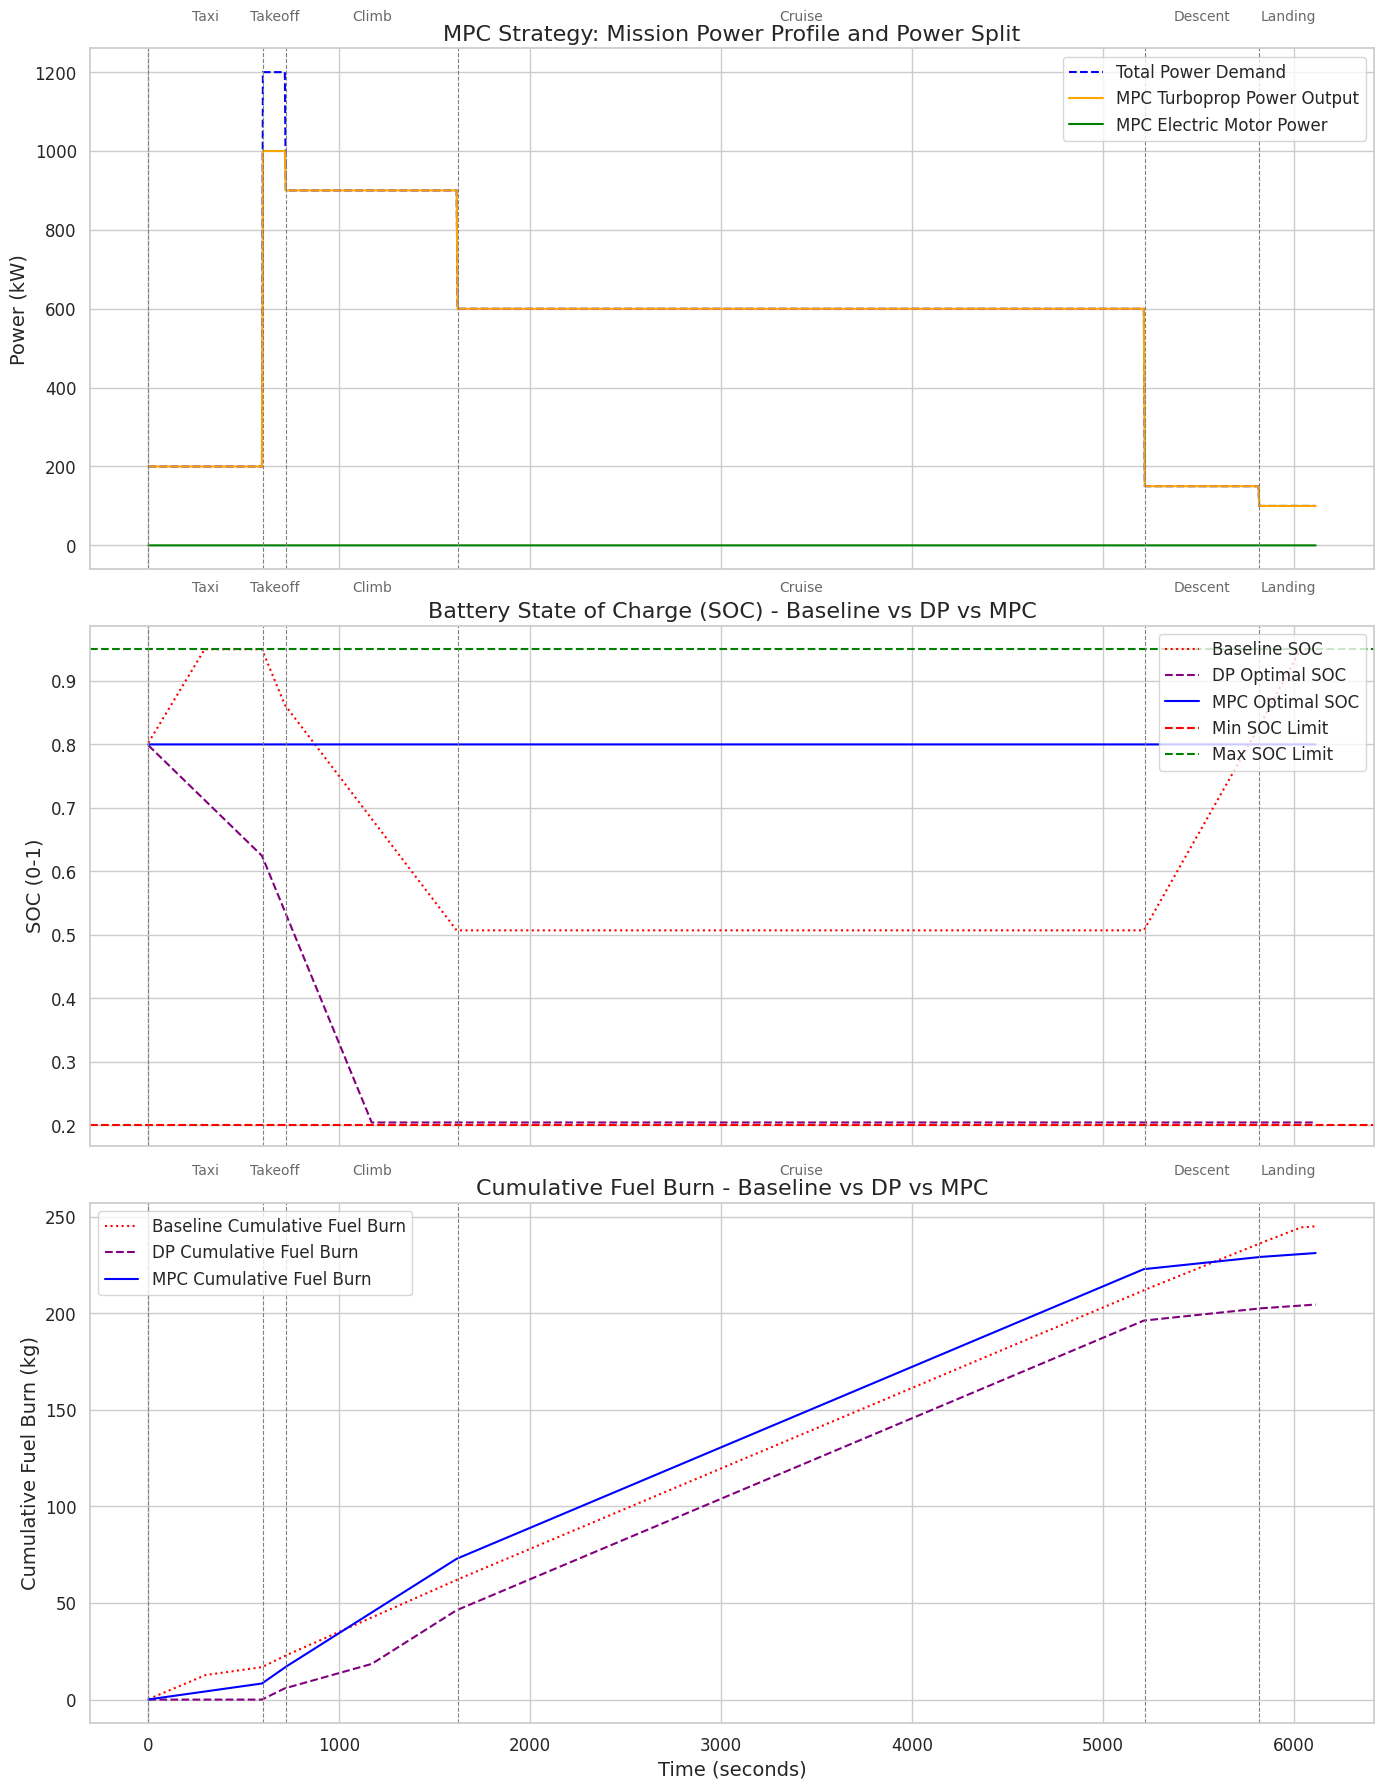

In [21]:
fig, axes = plt.subplots(3, 1, figsize=(14, 18), sharex=True)

# Plot 1: Power Profile (MPC)
sns.lineplot(x='time_sec', y='power_demand_kw', data=df_mpc, ax=axes[0], label='Total Power Demand', color='blue', linestyle='--')
sns.lineplot(x='time_sec', y='turboprop_power_kw', data=df_mpc, ax=axes[0], label='MPC Turboprop Power Output', color='orange')
sns.lineplot(x='time_sec', y='electric_power_kw', data=df_mpc, ax=axes[0], label='MPC Electric Motor Power', color='green')
axes[0].set_title('MPC Strategy: Mission Power Profile and Power Split')
axes[0].set_ylabel('Power (kW)')
axes[0].legend(loc='upper right')
axes[0].grid(True)

# Plot 2: Battery SOC (Baseline vs DP vs MPC)
sns.lineplot(x='time_sec', y='soc', data=df_baseline, ax=axes[1], label='Baseline SOC', color='red', linestyle=':')
sns.lineplot(x='time_sec', y='soc', data=df_dp, ax=axes[1], label='DP Optimal SOC', color='purple', linestyle='--')
sns.lineplot(x='time_sec', y='soc', data=df_mpc, ax=axes[1], label='MPC Optimal SOC', color='blue')
axes[1].axhline(y=params.MIN_SOC, color='red', linestyle='--', label='Min SOC Limit')
axes[1].axhline(y=params.MAX_SOC, color='green', linestyle='--', label='Max SOC Limit')
axes[1].set_title('Battery State of Charge (SOC) - Baseline vs DP vs MPC')
axes[1].set_ylabel('SOC (0-1)')
axes[1].legend(loc='upper right')
axes[1].grid(True)

# Plot 3: Cumulative Fuel Burn (Baseline vs DP vs MPC)
df_mpc['cumulative_fuel_burn_kg'] = df_mpc['fuel_burn_kg'].cumsum()
sns.lineplot(x='time_sec', y='cumulative_fuel_burn_kg', data=df_baseline, ax=axes[2], label='Baseline Cumulative Fuel Burn', color='red', linestyle=':')
sns.lineplot(x='time_sec', y='cumulative_fuel_burn_kg', data=df_dp, ax=axes[2], label='DP Cumulative Fuel Burn', color='purple', linestyle='--')
sns.lineplot(x='time_sec', y='cumulative_fuel_burn_kg', data=df_mpc, ax=axes[2], label='MPC Cumulative Fuel Burn', color='blue')
axes[2].set_title('Cumulative Fuel Burn - Baseline vs DP vs MPC')
axes[2].set_xlabel('Time (seconds)')
axes[2].set_ylabel('Cumulative Fuel Burn (kg)')
axes[2].legend(loc='upper left')
axes[2].grid(True)

# Add mission segment lines and labels to all plots
segment_start_time = 0
for segment_name, seg_data in mission.SEGMENTS.items():
    segment_end_time = segment_start_time + seg_data['duration']
    for ax in axes:
        ax.axvline(x=segment_start_time, color='gray', linestyle='--', linewidth=0.8)
        ax.text(segment_start_time + seg_data['duration']/2, ax.get_ylim()[1] * 1.05, segment_name,
                rotation=0, horizontalalignment='center', verticalalignment='bottom', fontsize=10, color='dimgray')
    segment_start_time = segment_end_time

plt.tight_layout()
plt.show()

### Yorumlar ve Gözlemler

Model Tahminli Kontrol (MPC), gerçek zamanlı optimizasyon yeteneği sayesinde değişen koşullara adaptasyon avantajı sunar. Genellikle DP kadar global optimal olmasa da, kısa tahmin ufku içinde lokal olarak en iyi kararları vererek DP'ye yakın veya kabul edilebilir performans sergileyebilir.

Grafikler, MPC stratejisinin güç dağıtımını, SOC'u ve yakıt tüketimini nasıl yönettiğini göstermektedir. Özellikle, kısa vadeli tahmin yeteneği, MPC'nin SOC'u daha dinamik bir şekilde yönetmesini sağlayabilir, örneğin bataryayı belirli segmentlerde daha agresif bir şekilde deşarj edip şarj ederek genel verimliliği artırabilir. MPC'nin temel avantajı, her adımda mevcut durum bilgilerini kullanarak yeniden optimize edebilmesi ve böylece DP'nin önceden hesaplanmış politikasından daha esnek olmasıdır.

# BÖLÜM 10 – ENERJİ TAHMİNİ İÇİN MAKİNE ÖĞRENİMİ

Optimizasyon algoritmaları, gelecekteki olaylar hakkında doğru bilgilere sahip olduğunda en iyi kararları verebilir. Özellikle Model Tahminli Kontrol (MPC) gibi yöntemler, doğru tahminlere büyük ölçüde bağımlıdır. Bu bölümde, uçuş görev profilimizdeki gelecekteki güç talebini tahmin etmek için Makine Öğrenimi (ML) modelleri geliştireceğiz. Bu, enerji yönetim sistemimizin 'öngörü' yeteneğini artıracaktır.

## Güç Talebi Tahmini için Makine Öğrenimi Modelleri

Geçmiş görev verilerimizden faydalanarak, gelecekteki güç talebini tahmin etmek için aşağıdaki girişleri kullanacağız:

*   **Uçuş Segmenti (Mission Segment):** Hangi uçuş fazında olunduğu (Taksi, Kalkış vb.).
*   **Zaman (Time):** Görevin başlangıcından itibaren geçen süre.
*   **Ağırlık (Weight):** Uçağın mevcut ağırlığı (yakıt tüketimi nedeniyle değişir).
*   **SOC (State of Charge):** Bataryanın mevcut şarj durumu.

Bu özelliklerden yararlanarak, yaygın olarak kullanılan regresyon modelleri olan Random Forest Regressor ve Gradient Boosting Regressor'ı uygulayacağız.

Data prepared for ML: 979 training samples, 245 testing samples.
Training Random Forest Regressor...
Random Forest Regressor Performance:
  RMSE: 10.17
  MAE: 0.69
  R-squared: 1.00
Training Gradient Boosting Regressor...

Gradient Boosting Regressor Performance:
  RMSE: 13.00
  MAE: 0.84
  R-squared: 1.00


,Random Forest,Gradient Boosting
Metric,,
RMSE,10.174398,12.997909
MAE,0.685714,0.835281
R-squared,0.998269,0.997175


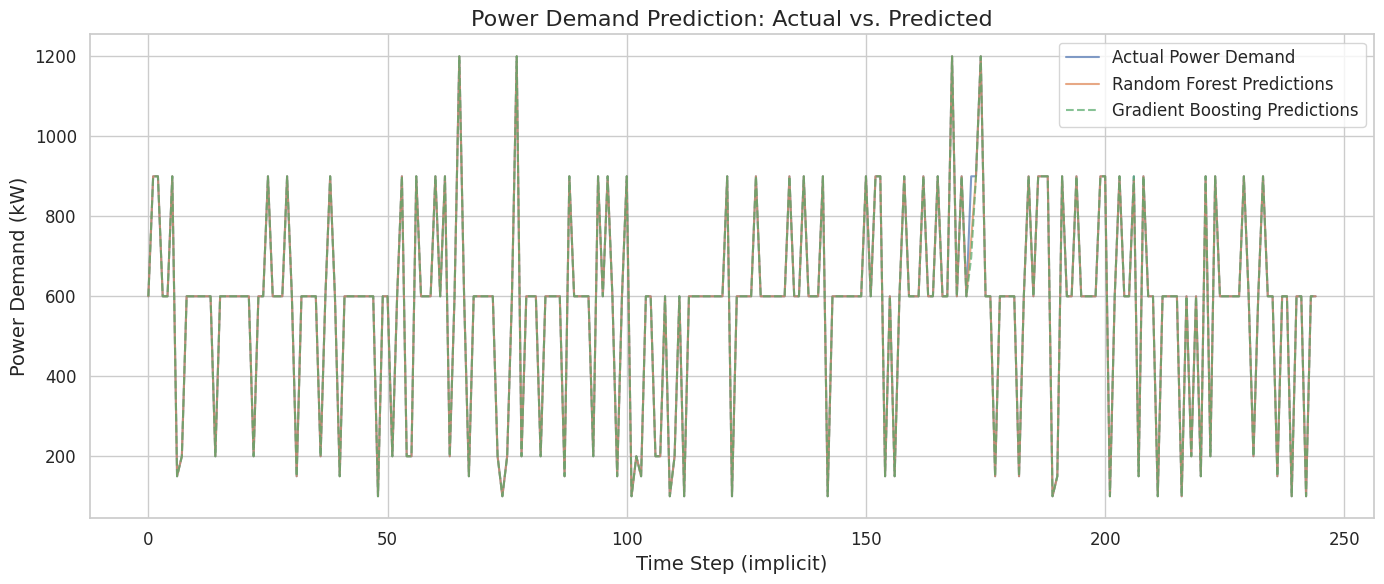

In [22]:
# Prepare data for Machine Learning
# Use the data generated from the baseline simulation as historical data
ml_df = df_baseline.copy()

# Feature Engineering
# Convert mission_segment to numerical (one-hot encoding or label encoding)
ml_df['mission_segment_encoded'] = ml_df['mission_segment'].astype('category').cat.codes

# Define features (X) and target (y)
features = ['time_sec', 'mission_segment_encoded', 'aircraft_weight_kg', 'soc']
target = 'power_demand_kw'

X = ml_df[features]
y = ml_df[target]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data prepared for ML: {len(X_train)} training samples, {len(X_test)} testing samples.")

# --- Random Forest Regressor ---
print("Training Random Forest Regressor...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Regressor Performance:")
print(f"  RMSE: {rmse_rf:.2f}")
print(f"  MAE: {mae_rf:.2f}")
print(f"  R-squared: {r2_rf:.2f}")

# --- Gradient Boosting Regressor ---
print("Training Gradient Boosting Regressor...")
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
mae_gb = mean_absolute_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print(f"\nGradient Boosting Regressor Performance:")
print(f"  RMSE: {rmse_gb:.2f}")
print(f"  MAE: {mae_gb:.2f}")
print(f"  R-squared: {r2_gb:.2f}")

# Create a summary DataFrame for ML models
ml_summary_data = {
    'Metric': ['RMSE', 'MAE', 'R-squared'],
    'Random Forest': [rmse_rf, mae_rf, r2_rf],
    'Gradient Boosting': [rmse_gb, mae_gb, r2_gb]
}
df_ml_summary = pd.DataFrame(ml_summary_data).set_index('Metric')
display(df_ml_summary)

# Visualize predictions vs actual
plt.figure(figsize=(14, 6))
plt.plot(y_test.values, label='Actual Power Demand', alpha=0.7)
plt.plot(y_pred_rf, label='Random Forest Predictions', alpha=0.7)
plt.plot(y_pred_gb, label='Gradient Boosting Predictions', alpha=0.7, linestyle='--')
plt.title('Power Demand Prediction: Actual vs. Predicted')
plt.xlabel('Time Step (implicit)')
plt.ylabel('Power Demand (kW)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Tahmin Optimizasyonu Nasıl Destekler?

Doğru ve güvenilir güç talebi tahminleri, enerji yönetimi optimizasyonunun verimliliği ve etkinliği için hayati öneme sahiptir:

*   **Model Tahminli Kontrol (MPC) İçin Girdi:** MPC gibi ileriye dönük optimizasyon algoritmaları, karar ufkundaki gelecekteki güç talebi tahminlerine dayanır. Makine öğrenimi modelleri tarafından sağlanan doğru tahminler, MPC'nin daha isabetli kararlar almasını ve dolayısıyla daha iyi yakıt verimliliği ve batarya yönetimi sağlamasını mümkün kılar.
*   **Optimal Kaynak Tahsisi:** Gelecekteki güç talebini bilmek, motor ve batarya arasındaki güç dağıtımını önceden planlamayı kolaylaştırır. Örneğin, yüksek güç talebi beklendiğinde batarya deşarjını önceden ayarlamak veya düşük talep dönemlerinde bataryayı şarj etmek gibi stratejiler daha proaktif bir şekilde uygulanabilir.
*   **Risk Yönetimi:** Güç talebindeki ani artışları veya düşüşleri tahmin etmek, sistemin aşırı yüklenmesini veya yetersiz güç sağlamasını önleyerek operasyonel güvenliği artırır.
*   **Tasarım ve Planlama:** Uzun vadeli tahmin modelleri, farklı görev profilleri için batarya kapasitesi veya motor boyutlandırma gibi uçak tasarım kararlarını bilgilendirebilir.

Sonuç olarak, makine öğrenimi tabanlı tahmin, enerji yönetimi optimizasyon algoritmalarına kritik 'öngörü' sağlayarak, daha verimli, güvenli ve sağlam operasyonel stratejilerin geliştirilmesine olanak tanır.

# BÖLÜM 11 – TAKVİYELİ ÖĞRENME (REINFORCEMENT LEARNING) KAVRAMI

Takviyeli Öğrenme (RL), bir ajanın bir ortamda hedeflerini maksimize etmek için nasıl hareket etmesi gerektiğini öğrenmesini sağlayan bir makine öğrenimi paradigmaları ailesidir. Model tabanlı optimizasyon yöntemleri (DP, MPC) sistem dinamikleri hakkında önceden bilgi gerektirirken, RL ajanları deneyim yoluyla optimal politikayı öğrenirler. Bu, özellikle karmaşık ve dinamik sistemlerde veya sistem modelinin tam olarak bilinmediği durumlarda avantaj sağlar.

Hibrit-elektrikli enerji yönetiminde RL, uçağın uçuşun herhangi bir anında (durum) hangi güç dağıtım kararını (eylem) alması gerektiğini öğrenebilir. Ajanın amacı, görev boyunca toplam yakıt tüketimini minimize etmek ve batarya sağlığını korumak gibi uzun vadeli ödülü maksimize etmektir. Bu, bataryanın ömrü boyunca optimal bir şekilde kullanıldığı ve turboprop motorunun en verimli olduğu çalışma noktalarında kullanıldığı anlamına gelir.

## Takviyeli Öğrenmenin Temel Bileşenleri

RL'nin temel bileşenleri, enerji yönetimi problemimize aşağıdaki gibi uyarlanabilir:

*   **Ajan (Agent):** Kararları alan varlık (örneğin, hibrit-elektrikli hava taşıtının enerji yönetim sistemi).
*   **Ortam (Environment):** Ajanın içinde bulunduğu dünya (örneğin, hava taşıtı, motorlar, batarya, görev profili ve dış koşullar).
*   **Durum (State):** Ortamın belirli bir andaki anlık konfigürasyonu ($SOC_t$, $W_t$, $Segment_t$).
*   **Eylem (Action):** Ajanın belirli bir durumda yapabileceği bir hareket ($P_{turboprop, t}$, $P_{electric, t}$).
*   **Ödül (Reward):** Bir eylem sonucunda ortamdan alınan geri bildirim. Enerji yönetimi bağlamında, yakıt tüketimi veya batarya ömrü ihlalleri gibi cezalar negatif ödül (maliyet) olarak tanımlanabilir. Amaç, kümülatif ödülü maksimize etmektir (yani kümülatif maliyeti minimize etmek).
*   **Politika (Policy):** Bir durum verildiğinde hangi eylemin yapılacağını tanımlayan strateji ($\pi(s) = a$).
*   **Değer Fonksiyonu (Value Function):** Belirli bir durumdan veya belirli bir politika altında başlanan bir durum-eylem çiftinden elde edilebilecek beklenen kümülatif ödülü tahmin eden fonksiyon.

### RL Algoritmaları

Popüler RL algoritmaları arasında Q-Learning, SARSA, Policy Gradients (REINFORCE, Actor-Critic) ve daha gelişmiş DPO (Deep Policy Optimization) ve PPO (Proximal Policy Optimization) gibi derin öğrenme tabanlı yaklaşımlar bulunmaktadır. Bu algoritmalar, ajanın deneme yanılma yoluyla optimal politikayı keşfetmesine olanak tanır.

## RL Uygulamasının Potansiyel Faydaları

RL, hibrit-elektrikli enerji yönetiminde bir dizi potansiyel fayda sunar:

*   **Model-Free Öğrenme:** RL ajanları, sistemin tam matematiksel modeline ihtiyaç duymadan öğrenebilirler, bu da karmaşık hava taşıtı sistemleri için önemlidir.
*   **Uyarlanabilirlik:** Uçuş koşulları değiştikçe veya sistem bileşenleri yaşlandıkça politikalarını dinamik olarak güncelleyebilirler.
*   **Küresel Optimizasyon:** Yeterli keşif (exploration) ile, RL ajanları yerel optimalliklere takılmadan küresel olarak optimal veya küresel olarak iyi politikalar bulabilirler.
*   **Gerçek Zamanlı Karar Verme:** İyi eğitilmiş bir RL ajanı, gerçek zamanlı verilere dayanarak hızlı kararlar verebilir.

## RL Simülasyonu için Ortam Tanımlama

Bu bölümde basit bir RL ortamı tanımlayacağız. Ortam, ajanın durumunu, eylemlerini ve ödüllerini belirleyecektir. Ortamımızın çekirdeği, daha önce tanımladığımız `AircraftParameters` ve `MissionProfile` sınıflarımıza dayanacaktır.

In [23]:
class HybridAircraftEnv:
    def __init__(self, params: AircraftParameters, mission: MissionProfile):
        self.params = params
        self.mission = mission
        self.current_step = 0
        self.time_points = np.arange(0, self.mission.TOTAL_DURATION_SEC, self.mission.TIME_STEP_SEC)
        self.num_time_steps = len(self.time_points)

        self.reset()

    def reset(self):
        self.current_soc = self.params.INITIAL_SOC
        self.current_weight_kg = self.params.AIRCRAFT_INITIAL_WEIGHT_KG
        self.current_step = 0
        self.cumulative_fuel_burn = 0.0
        return self._get_state()

    def _get_state(self):
        t = self.time_points[self.current_step]
        segment_duration_sum = 0
        current_segment_name = ''
        power_demand_kw = 0.0
        for segment_name, seg_data in self.mission.SEGMENTS.items():
            segment_duration_sum += seg_data['duration']
            if t < segment_duration_sum:
                current_segment_name = segment_name
                power_demand_kw = seg_data['power_demand_kw']
                break

        # State: [normalized_soc, normalized_weight, current_segment_index, normalized_power_demand]
        # We need to normalize these for RL agent
        normalized_soc = (self.current_soc - self.params.MIN_SOC) / (self.params.MAX_SOC - self.params.MIN_SOC)
        normalized_weight = self.current_weight_kg / self.params.AIRCRAFT_INITIAL_WEIGHT_KG

        # Simple encoding for mission segment
        segment_mapping = {name: i for i, name in enumerate(self.mission.SEGMENTS.keys())}
        segment_index = segment_mapping.get(current_segment_name, 0)

        normalized_power_demand = power_demand_kw / self.params.MAX_TURBOPROP_POWER_KW # Using max turboprop as a scaling factor

        return np.array([normalized_soc, normalized_weight, segment_index, normalized_power_demand])

    def step(self, action: float): # action: electric_power_fraction (0 to 1)
        # Action: fraction of total power demand to be supplied by electric motor
        # (Remaining is supplied by turboprop)

        t = self.time_points[self.current_step]
        segment_duration_sum = 0
        power_demand_kw = 0.0
        for segment_name, seg_data in self.mission.SEGMENTS.items():
            segment_duration_sum += seg_data['duration']
            if t < segment_duration_sum:
                power_demand_kw = seg_data['power_demand_kw']
                break

        # Calculate electric and turboprop power based on action
        electric_power_kw = action * power_demand_kw # Let action directly be electric power contribution
        turboprop_power_kw = power_demand_kw - electric_power_kw

        # Clip powers to physical limits (simplified for environment)
        electric_power_kw = np.clip(electric_power_kw, 0, self.params.MAX_ELECTRIC_POWER_KW) # Assume no charging by action for simplicity
        turboprop_power_kw = np.clip(turboprop_power_kw, 0, self.params.MAX_TURBOPROP_POWER_KW)

        # Recalculate if powers were clipped and don't meet demand
        if turboprop_power_kw + electric_power_kw < power_demand_kw:
            # If total power is less than demand, assume turboprop makes up the difference if possible
            turboprop_power_kw = np.clip(power_demand_kw - electric_power_kw, 0, self.params.MAX_TURBOPROP_POWER_KW)

        # --- Calculate costs and update state ---
        current_fuel_burn = calculate_fuel_burn_kg(turboprop_power_kw, self.mission.TIME_STEP_SEC, self.params.TURBOPROP_FUEL_BURN_RATE_G_KWHR)

        # For RL, electric_power_kw > 0 for discharge (cost), electric_power_kw < 0 for charge (reward)
        # For simplicity in this env, we assume action implies discharge/assist
        battery_energy_change_kwh = calculate_battery_energy_kwh(electric_power_kw, self.mission.TIME_STEP_SEC, self.params.BATTERY_DISCHARGE_EFFICIENCY)

        new_soc = self.current_soc - (battery_energy_change_kwh / self.params.BATTERY_CAPACITY_KWH) # Direct calculation for env

        # Reward definition: negative fuel burn, penalty for SOC violation
        reward = -current_fuel_burn # Minimize fuel burn -> maximize negative fuel burn

        # Penalize SOC violations
        soc_violation_penalty = 0
        if new_soc < self.params.MIN_SOC:
            soc_violation_penalty = (self.params.MIN_SOC - new_soc) * 1000 # Large penalty for going below min SOC
            new_soc = self.params.MIN_SOC # Clip for environment consistency
        elif new_soc > self.params.MAX_SOC:
            soc_violation_penalty = (new_soc - self.params.MAX_SOC) * 100 # Smaller penalty for exceeding max SOC (less critical)
            new_soc = self.params.MAX_SOC # Clip for environment consistency

        reward -= soc_violation_penalty

        # Update state variables
        self.current_soc = new_soc
        self.current_weight_kg = update_weight_kg(self.current_weight_kg, current_fuel_burn)
        self.cumulative_fuel_burn += current_fuel_burn
        self.current_step += 1

        done = self.current_step >= self.num_time_steps - 1

        # If mission ends with low SOC, add a terminal penalty
        if done and self.current_soc < self.params.INITIAL_SOC:
            reward -= (self.params.INITIAL_SOC - self.current_soc) * 500 # Terminal SOC penalty

        return self._get_state(), reward, done, {}

print("Reinforcement Learning environment defined.")

Reinforcement Learning environment defined.


In [24]:
env = HybridAircraftEnv(params, mission)

# Example of interacting with the environment (random agent)
obs = env.reset()
done = False
total_reward = 0

print("Simulating a random RL agent's episode...")
while not done:
    action = np.random.uniform(0, 1) # Random electric power fraction (0 to 1)
    obs, reward, done, _ = env.step(action)
    total_reward += reward

print(f"Episode finished. Total Reward: {total_reward:.2f}, Final SOC: {env.current_soc:.2f}, Total Fuel Burn: {env.cumulative_fuel_burn:.2f} kg")
print("Note: This is a random agent, not an optimized RL agent.")

Simulating a random RL agent's episode...
Episode finished. Total Reward: -2076.59, Final SOC: 0.20, Total Fuel Burn: 125.90 kg
Note: This is a random agent, not an optimized RL agent.


## RL Ajanı Eğitimi (Basit Q-Learning Örneği)

Gerçek bir RL ajanı eğitmek, bu defterin kapsamını aşan karmaşık bir süreçtir ve özel kütüphaneler (örn. `stable-baselines3`, `Ray RLlib`) ile derinlemesine bir tasarım gerektirir. Ancak, burada ayrık durum ve eylem alanlarına sahip küçük bir problem için Q-learning'in temel yapısını gösterebiliriz. Daha büyük ve sürekli durum/eylem alanları için derin Q ağları (DQN) veya Actor-Critic yöntemleri kullanılır.

Basitlik adına, burada gerçek bir eğitimi çalıştırmayacak, sadece Q-Tablo oluşturma ve güncelleme mantığını ana hatlarıyla belirteceğiz. Ortamımızdaki durumlar henüz ayrık olmadığından, durumu ayrıklaştırmak gerekecektir.

In [25]:
# To implement Q-Learning, we need to discretize the state space.
# For demonstration, we'll only discretize SOC and assume others are handled.

# Number of bins for SOC discretization
SOC_BINS = 10

def discretize_state(state_vector, soc_min, soc_max, soc_bins):
    norm_soc, norm_weight, segment_index, norm_power_demand = state_vector

    # Discretize normalized SOC
    soc_bin = int(np.floor(norm_soc * soc_bins))
    soc_bin = np.clip(soc_bin, 0, soc_bins - 1)

    # For simplicity, we'll use a tuple for the discrete state representation.
    # In a real scenario, you'd discretize all continuous state variables.
    return (soc_bin, int(segment_index))

# Q-learning parameters
LEARNING_RATE = 0.1
DISCOUNT_FACTOR = 0.95
EPSILON = 0.1 # For epsilon-greedy policy

# Initialize Q-table (state, action) -> Q_value
# State space is (SOC_BINS, num_segments)
# Action space could be discrete electric power fractions (e.g., 0.0, 0.25, 0.5, 0.75, 1.0)
NUM_ACTIONS = 5 # Example: 0%, 25%, 50%, 75%, 100% electric power fraction

# This Q-table would be too large and sparse for continuous states/actions without approximation
# Q_table = np.zeros((SOC_BINS, len(mission.SEGMENTS), NUM_ACTIONS))

# Placeholder for a conceptual Q-learning update step
def conceptual_q_learning_update(q_table, state, action_idx, reward, next_state, done):
    # Get current Q-value
    current_q = q_table[state + (action_idx,)]

    if done:
        # If episode is finished, no future reward
        max_future_q = 0
    else:
        # Max future Q-value from the next state
        max_future_q = np.max(q_table[next_state])

    # Q-learning formula
    new_q = current_q + LEARNING_RATE * (reward + DISCOUNT_FACTOR * max_future_q - current_q)
    q_table[state + (action_idx,)] = new_q

print("Conceptual Q-Learning framework outlined.")
print("Note: Full implementation and training of an RL agent is beyond the scope of this notebook due to computational complexity and specialized libraries required.")

Conceptual Q-Learning framework outlined.
Note: Full implementation and training of an RL agent is beyond the scope of this notebook due to computational complexity and specialized libraries required.


## Yorumlar ve Gözlemler

Takviyeli Öğrenme, özellikle karmaşık ve tam olarak modellenemeyen sistemlerde enerji yönetimi için güçlü bir paradigma sunar. DP ve MPC gibi yöntemlerden farklı olarak, RL ajanı çevresiyle etkileşim kurarak ve ödül sinyallerinden öğrenerek kendi optimal politikasını oluşturur. Ancak, RL modellerinin eğitimi genellikle yüksek hesaplama maliyetleri gerektirir ve optimal politikaya ulaşmak için çok sayıda etkileşim veya simülasyon adımı gerekebilir.

Bu bölümde, RL'nin temel kavramlarını ve hibrit-elektrikli hava taşıtı enerji yönetimi problemine nasıl uygulanabileceğini inceledik. Gerçek dünya uygulamalarında, verimli RL ajanları geliştirmek için derin öğrenme teknikleri (`Deep Q-Networks`, `Actor-Critic` modelleri) ve gelişmiş simülasyon ortamları kullanılır.

In [26]:
class HybridAircraftEnv:
    def __init__(self, params: AircraftParameters, mission: MissionProfile):
        self.params = params
        self.mission = mission
        self.current_step = 0
        self.time_points = np.arange(0, self.mission.TOTAL_DURATION_SEC, self.mission.TIME_STEP_SEC)
        self.num_time_steps = len(self.time_points)

        self.reset()

    def reset(self):
        self.current_soc = self.params.INITIAL_SOC
        self.current_weight_kg = self.params.AIRCRAFT_INITIAL_WEIGHT_KG
        self.current_step = 0
        self.cumulative_fuel_burn = 0.0
        return self._get_state()

    def _get_state(self):
        t = self.time_points[self.current_step]
        segment_duration_sum = 0
        current_segment_name = ''
        power_demand_kw = 0.0
        for segment_name, seg_data in self.mission.SEGMENTS.items():
            segment_duration_sum += seg_data['duration']
            if t < segment_duration_sum:
                current_segment_name = segment_name
                power_demand_kw = seg_data['power_demand_kw']
                break

        # State: [normalized_soc, normalized_weight, current_segment_index, normalized_power_demand]
        # We need to normalize these for RL agent
        normalized_soc = (self.current_soc - self.params.MIN_SOC) / (self.params.MAX_SOC - self.params.MIN_SOC)
        normalized_weight = self.current_weight_kg / self.params.AIRCRAFT_INITIAL_WEIGHT_KG

        # Simple encoding for mission segment
        segment_mapping = {name: i for i, name in enumerate(self.mission.SEGMENTS.keys())}
        segment_index = segment_mapping.get(current_segment_name, 0)

        normalized_power_demand = power_demand_kw / self.params.MAX_TURBOPROP_POWER_KW # Using max turboprop as a scaling factor

        return np.array([normalized_soc, normalized_weight, segment_index, normalized_power_demand])

    def step(self, action: float): # action: electric_power_fraction (0 to 1)
        # Action: fraction of total power demand to be supplied by electric motor
        # (Remaining is supplied by turboprop)

        t = self.time_points[self.current_step]
        segment_duration_sum = 0
        power_demand_kw = 0.0
        for segment_name, seg_data in self.mission.SEGMENTS.items():
            segment_duration_sum += seg_data['duration']
            if t < segment_duration_sum:
                power_demand_kw = seg_data['power_demand_kw']
                break

        # Calculate electric and turboprop power based on action
        electric_power_kw = action * power_demand_kw # Let action directly be electric power contribution
        turboprop_power_kw = power_demand_kw - electric_power_kw

        # Clip powers to physical limits (simplified for environment)
        electric_power_kw = np.clip(electric_power_kw, 0, self.params.MAX_ELECTRIC_POWER_KW) # Assume no charging by action for simplicity
        turboprop_power_kw = np.clip(turboprop_power_kw, 0, self.params.MAX_TURBOPROP_POWER_KW)

        # Recalculate if powers were clipped and don't meet demand
        if turboprop_power_kw + electric_power_kw < power_demand_kw:
            # If total power is less than demand, assume turboprop makes up the difference if possible
            turboprop_power_kw = np.clip(power_demand_kw - electric_power_kw, 0, self.params.MAX_TURBOPROP_POWER_KW)

        # --- Calculate costs and update state ---
        current_fuel_burn = calculate_fuel_burn_kg(turboprop_power_kw, self.mission.TIME_STEP_SEC, self.params.TURBOPROP_FUEL_BURN_RATE_G_KWHR)

        # For RL, electric_power_kw > 0 for discharge (cost), electric_power_kw < 0 for charge (reward)
        # For simplicity in this env, we assume action implies discharge/assist
        battery_energy_change_kwh = calculate_battery_energy_kwh(electric_power_kw, self.mission.TIME_STEP_SEC, self.params.BATTERY_DISCHARGE_EFFICIENCY)

        new_soc = self.current_soc - (battery_energy_change_kwh / self.params.BATTERY_CAPACITY_KWH) # Direct calculation for env

        # Reward definition: negative fuel burn, penalty for SOC violation
        reward = -current_fuel_burn # Minimize fuel burn -> maximize negative fuel burn

        # Penalize SOC violations
        soc_violation_penalty = 0
        if new_soc < self.params.MIN_SOC:
            soc_violation_penalty = (self.params.MIN_SOC - new_soc) * 1000 # Large penalty for going below min SOC
            new_soc = self.params.MIN_SOC # Clip for environment consistency
        elif new_soc > self.params.MAX_SOC:
            soc_violation_penalty = (new_soc - self.params.MAX_SOC) * 100 # Smaller penalty for exceeding max SOC (less critical)
            new_soc = self.params.MAX_SOC # Clip for environment consistency

        reward -= soc_violation_penalty

        # Update state variables
        self.current_soc = new_soc
        self.current_weight_kg = update_weight_kg(self.current_weight_kg, current_fuel_burn)
        self.cumulative_fuel_burn += current_fuel_burn
        self.current_step += 1

        done = self.current_step >= self.num_time_steps - 1

        # If mission ends with low SOC, add a terminal penalty
        if done and self.current_soc < self.params.INITIAL_SOC:
            reward -= (self.params.INITIAL_SOC - self.current_soc) * 500 # Terminal SOC penalty

        return self._get_state(), reward, done, {}

print("Reinforcement Learning environment defined.")

Reinforcement Learning environment defined.


In [27]:
env = HybridAircraftEnv(params, mission)

# Example of interacting with the environment (random agent)
obs = env.reset()
done = False
total_reward = 0

print("Simulating a random RL agent's episode...")
while not done:
    action = np.random.uniform(0, 1) # Random electric power fraction (0 to 1)
    obs, reward, done, _ = env.step(action)
    total_reward += reward

print(f"Episode finished. Total Reward: {total_reward:.2f}, Final SOC: {env.current_soc:.2f}, Total Fuel Burn: {env.cumulative_fuel_burn:.2f} kg")
print("Note: This is a random agent, not an optimized RL agent.")

Simulating a random RL agent's episode...
Episode finished. Total Reward: -2072.75, Final SOC: 0.20, Total Fuel Burn: 126.02 kg
Note: This is a random agent, not an optimized RL agent.


In [28]:
# To implement Q-Learning, we need to discretize the state space.
# For demonstration, we'll only discretize SOC and assume others are handled.

# Number of bins for SOC discretization
SOC_BINS = 10

def discretize_state(state_vector, soc_min, soc_max, soc_bins):
    norm_soc, norm_weight, segment_index, norm_power_demand = state_vector

    # Discretize normalized SOC
    soc_bin = int(np.floor(norm_soc * soc_bins))
    soc_bin = np.clip(soc_bin, 0, soc_bins - 1)

    # For simplicity, we'll use a tuple for the discrete state representation.
    # In a real scenario, you'd discretize all continuous state variables.
    return (soc_bin, int(segment_index))

# Q-learning parameters
LEARNING_RATE = 0.1
DISCOUNT_FACTOR = 0.95
EPSILON = 0.1 # For epsilon-greedy policy

# Initialize Q-table (state, action) -> Q_value
# State space is (SOC_BINS, num_segments)
# Action space could be discrete electric power fractions (e.g., 0.0, 0.25, 0.5, 0.75, 1.0)
NUM_ACTIONS = 5 # Example: 0%, 25%, 50%, 75%, 100% electric power fraction

# This Q-table would be too large and sparse for continuous states/actions without approximation
# Q_table = np.zeros((SOC_BINS, len(mission.SEGMENTS), NUM_ACTIONS))

# Placeholder for a conceptual Q-learning update step
def conceptual_q_learning_update(q_table, state, action_idx, reward, next_state, done):
    # Get current Q-value
    current_q = q_table[state + (action_idx,)]

    if done:
        # If episode is finished, no future reward
        max_future_q = 0
    else:
        # Max future Q-value from the next state
        max_future_q = np.max(q_table[next_state])

    # Q-learning formula
    new_q = current_q + LEARNING_RATE * (reward + DISCOUNT_FACTOR * max_future_q - current_q)
    q_table[state + (action_idx,)] = new_q

print("Conceptual Q-Learning framework outlined.")
print("Note: Full implementation and training of an RL agent is beyond the scope of this notebook due to computational complexity and specialized libraries required.")

Conceptual Q-Learning framework outlined.
Note: Full implementation and training of an RL agent is beyond the scope of this notebook due to computational complexity and specialized libraries required.


In [29]:
display(df_summary_baseline.round(2))

,Baseline Strategy,DP Strategy,MPC Strategy
Metric,,,
Total Fuel Burn (kg),245.09,204.58,231.25
Final SOC,0.95,0.20,0.80


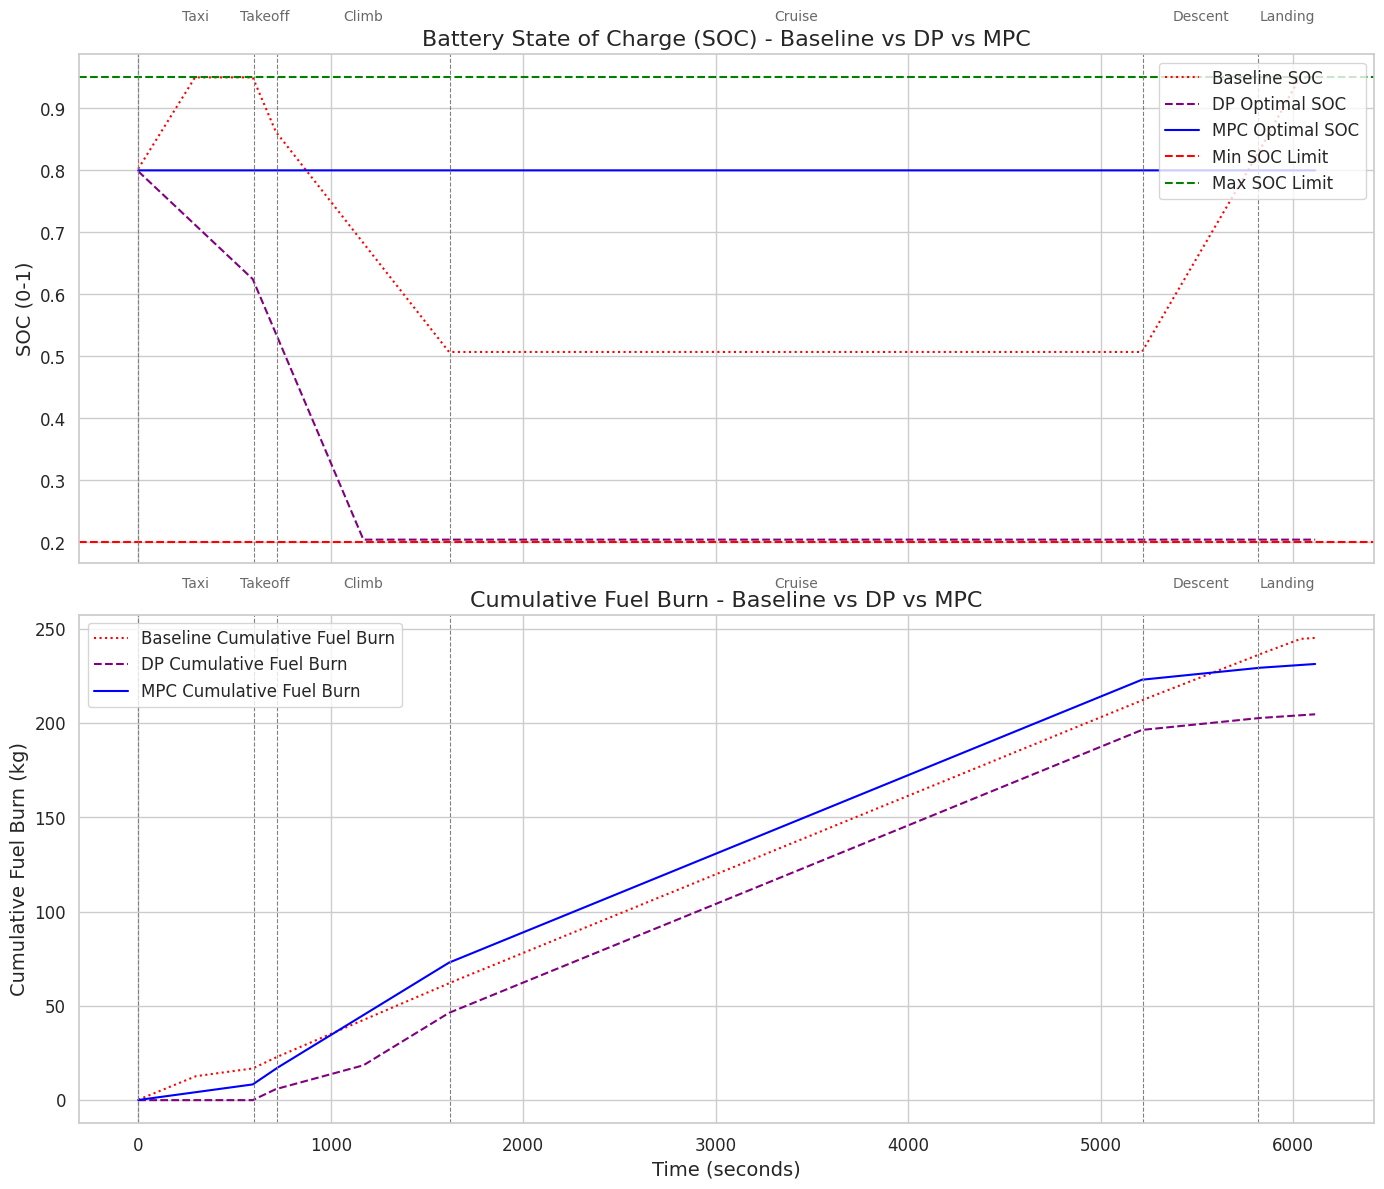

In [30]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# Plot 1: Battery SOC (Baseline vs DP vs MPC)
sns.lineplot(x='time_sec', y='soc', data=df_baseline, ax=axes[0], label='Baseline SOC', color='red', linestyle=':')
sns.lineplot(x='time_sec', y='soc', data=df_dp, ax=axes[0], label='DP Optimal SOC', color='purple', linestyle='--')
sns.lineplot(x='time_sec', y='soc', data=df_mpc, ax=axes[0], label='MPC Optimal SOC', color='blue')
axes[0].axhline(y=params.MIN_SOC, color='red', linestyle='--', label='Min SOC Limit')
axes[0].axhline(y=params.MAX_SOC, color='green', linestyle='--', label='Max SOC Limit')
axes[0].set_title('Battery State of Charge (SOC) - Baseline vs DP vs MPC')
axes[0].set_ylabel('SOC (0-1)')
axes[0].legend(loc='upper right')
axes[0].grid(True)

# Plot 2: Cumulative Fuel Burn (Baseline vs DP vs MPC)
df_mpc['cumulative_fuel_burn_kg'] = df_mpc['fuel_burn_kg'].cumsum()
sns.lineplot(x='time_sec', y='cumulative_fuel_burn_kg', data=df_baseline, ax=axes[1], label='Baseline Cumulative Fuel Burn', color='red', linestyle=':')
sns.lineplot(x='time_sec', y='cumulative_fuel_burn_kg', data=df_dp, ax=axes[1], label='DP Cumulative Fuel Burn', color='purple', linestyle='--')
sns.lineplot(x='time_sec', y='cumulative_fuel_burn_kg', data=df_mpc, ax=axes[1], label='MPC Cumulative Fuel Burn', color='blue')
axes[1].set_title('Cumulative Fuel Burn - Baseline vs DP vs MPC')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Cumulative Fuel Burn (kg)')
axes[1].legend(loc='upper left')
axes[1].grid(True)

# Add mission segment lines and labels to all plots
segment_start_time = 0
for segment_name, seg_data in mission.SEGMENTS.items():
    segment_end_time = segment_start_time + seg_data['duration']
    for ax in axes:
        ax.axvline(x=segment_start_time, color='gray', linestyle='--', linewidth=0.8)
        ax.text(segment_start_time + seg_data['duration']/2, ax.get_ylim()[1] * 1.05, segment_name,
                rotation=0, horizontalalignment='center', verticalalignment='bottom', fontsize=10, color='dimgray')
    segment_start_time = segment_end_time

plt.tight_layout()
plt.show()

# BÖLÜM 11 – TAKVİYELİ ÖĞRENME (REINFORCEMENT LEARNING) KAVRAMI

Takviyeli Öğrenme (RL), bir ajanın bir ortamda hedeflerini maksimize etmek için nasıl hareket etmesi gerektiğini öğrenmesini sağlayan bir makine öğrenimi paradigmaları ailesidir. Model tabanlı optimizasyon yöntemleri (DP, MPC) sistem dinamikleri hakkında önceden bilgi gerektirirken, RL ajanları deneyim yoluyla optimal politikayı öğrenirler. Bu, özellikle karmaşık ve dinamik sistemlerde veya sistem modelinin tam olarak bilinmediği durumlarda avantaj sağlar.

Hibrit-elektrikli enerji yönetiminde RL, uçağın uçuşun herhangi bir anında (durum) hangi güç dağıtım kararını (eylem) alması gerektiğini öğrenebilir. Ajanın amacı, görev boyunca toplam yakıt tüketimini minimize etmek ve batarya sağlığını korumak gibi uzun vadeli ödülü maksimize etmektir. Bu, bataryanın ömrü boyunca optimal bir şekilde kullanıldığı ve turboprop motorunun en verimli olduğu çalışma noktalarında kullanıldığı anlamına gelir.

## Takviyeli Öğrenmenin Temel Bileşenleri

RL'nin temel bileşenleri, enerji yönetimi problemimize aşağıdaki gibi uyarlanabilir:

*   **Ajan (Agent):** Kararları alan varlık (örneğin, hibrit-elektrikli hava taşıtının enerji yönetim sistemi).
*   **Ortam (Environment):** Ajanın içinde bulunduğu dünya (örneğin, hava taşıtı, motorlar, batarya, görev profili ve dış koşullar).
*   **Durum (State):** Ortamın belirli bir andaki anlık konfigürasyonu ($SOC_t$, $W_t$, $Segment_t$).
*   **Eylem (Action):** Ajanın belirli bir durumda yapabileceği bir hareket ($P_{turboprop, t}$, $P_{electric, t}$).
*   **Ödül (Reward):** Bir eylem sonucunda ortamdan alınan geri bildirim. Enerji yönetimi bağlamında, yakıt tüketimi veya batarya ömrü ihlalleri gibi cezalar negatif ödül (maliyet) olarak tanımlanabilir. Amaç, kümülatif ödülü maksimize etmektir (yani kümülatif maliyeti minimize etmek).
*   **Politika (Policy):** Bir durum verildiğinde hangi eylemin yapılacağını tanımlayan strateji ($\pi(s) = a$).
*   **Değer Fonksiyonu (Value Function):** Belirli bir durumdan veya belirli bir politika altında başlanan bir durum-eylem çiftinden elde edilebilecek beklenen kümülatif ödülü tahmin eden fonksiyon.

### RL Algoritmaları

Popüler RL algoritmaları arasında Q-Learning, SARSA, Policy Gradients (REINFORCE, Actor-Critic) ve daha gelişmiş DPO (Deep Policy Optimization) ve PPO (Proximal Policy Optimization) gibi derin öğrenme tabanlı yaklaşımlar bulunmaktadır. Bu algoritmalar, ajanın deneme yanılma yoluyla optimal politikayı keşfetmesine olanak tanır.

## RL Uygulamasının Potansiyel Faydaları

RL, hibrit-elektrikli enerji yönetiminde bir dizi potansiyel fayda sunar:

*   **Model-Free Öğrenme:** RL ajanları, sistemin tam matematiksel modeline ihtiyaç duymadan öğrenebilirler, bu da karmaşık hava taşıtı sistemleri için önemlidir.
*   **Uyarlanabilirlik:** Uçuş koşulları değiştikçe veya sistem bileşenleri yaşlandıkça politikalarını dinamik olarak güncelleyebilirler.
*   **Küresel Optimizasyon:** Yeterli keşif (exploration) ile, RL ajanları yerel optimalliklere takılmadan küresel olarak optimal veya küresel olarak iyi politikalar bulabilirler.
*   **Gerçek Zamanlı Karar Verme:** İyi eğitilmiş bir RL ajanı, gerçek zamanlı verilere dayanarak hızlı kararlar verebilir.

## RL Simülasyonu için Ortam Tanımlama

Bu bölümde basit bir RL ortamı tanımlayacağız. Ortam, ajanın durumunu, eylemlerini ve ödüllerini belirleyecektir. Ortamımızın çekirdeği, daha önce tanımladığımız `AircraftParameters` ve `MissionProfile` sınıflarımıza dayanacaktır.

In [33]:
class HybridAircraftEnv:
    def __init__(self, params: AircraftParameters, mission: MissionProfile):
        self.params = params
        self.mission = mission
        self.current_step = 0
        self.time_points = np.arange(0, self.mission.TOTAL_DURATION_SEC, self.mission.TIME_STEP_SEC)
        self.num_time_steps = len(self.time_points)

        self.reset()

    def reset(self):
        self.current_soc = self.params.INITIAL_SOC
        self.current_weight_kg = self.params.AIRCRAFT_INITIAL_WEIGHT_KG
        self.current_step = 0
        self.cumulative_fuel_burn = 0.0
        return self._get_state()

    def _get_state(self):
        t = self.time_points[self.current_step]
        segment_duration_sum = 0
        current_segment_name = ''
        power_demand_kw = 0.0
        for segment_name, seg_data in self.mission.SEGMENTS.items():
            segment_duration_sum += seg_data['duration']
            if t < segment_duration_sum:
                current_segment_name = segment_name
                power_demand_kw = seg_data['power_demand_kw']
                break

        # State: [normalized_soc, normalized_weight, current_segment_index, normalized_power_demand]
        # We need to normalize these for RL agent
        normalized_soc = (self.current_soc - self.params.MIN_SOC) / (self.params.MAX_SOC - self.params.MIN_SOC)
        normalized_weight = self.current_weight_kg / self.params.AIRCRAFT_INITIAL_WEIGHT_KG

        # Simple encoding for mission segment
        segment_mapping = {name: i for i, name in enumerate(self.mission.SEGMENTS.keys())}
        segment_index = segment_mapping.get(current_segment_name, 0)

        normalized_power_demand = power_demand_kw / self.params.MAX_TURBOPROP_POWER_KW # Using max turboprop as a scaling factor

        return np.array([normalized_soc, normalized_weight, segment_index, normalized_power_demand])

    def step(self, action: float): # action: electric_power_fraction (0 to 1)
        # Action: fraction of total power demand to be supplied by electric motor
        # (Remaining is supplied by turboprop)

        t = self.time_points[self.current_step]
        segment_duration_sum = 0
        power_demand_kw = 0.0
        for segment_name, seg_data in self.mission.SEGMENTS.items():
            segment_duration_sum += seg_data['duration']
            if t < segment_duration_sum:
                power_demand_kw = seg_data['power_demand_kw']
                break

        # Calculate electric and turboprop power based on action
        electric_power_kw = action * power_demand_kw # Let action directly be electric power contribution
        turboprop_power_kw = power_demand_kw - electric_power_kw

        # Clip powers to physical limits (simplified for environment)
        electric_power_kw = np.clip(electric_power_kw, 0, self.params.MAX_ELECTRIC_POWER_KW) # Assume no charging by action for simplicity
        turboprop_power_kw = np.clip(turboprop_power_kw, 0, self.params.MAX_TURBOPROP_POWER_KW)

        # Recalculate if powers were clipped and don't meet demand
        if turboprop_power_kw + electric_power_kw < power_demand_kw:
            # If total power is less than demand, assume turboprop makes up the difference if possible
            turboprop_power_kw = np.clip(power_demand_kw - electric_power_kw, 0, self.params.MAX_TURBOPROP_POWER_KW)

        # --- Calculate costs and update state ---
        current_fuel_burn = calculate_fuel_burn_kg(turboprop_power_kw, self.mission.TIME_STEP_SEC, self.params.TURBOPROP_FUEL_BURN_RATE_G_KWHR)

        # For RL, electric_power_kw > 0 for discharge (cost), electric_power_kw < 0 for charge (reward)
        # For simplicity in this env, we assume action implies discharge/assist
        battery_energy_change_kwh = calculate_battery_energy_kwh(electric_power_kw, self.mission.TIME_STEP_SEC, self.params.BATTERY_DISCHARGE_EFFICIENCY)

        new_soc = self.current_soc - (battery_energy_change_kwh / self.params.BATTERY_CAPACITY_KWH) # Direct calculation for env

        # Reward definition: negative fuel burn, penalty for SOC violation
        reward = -current_fuel_burn # Minimize fuel burn -> maximize negative fuel burn

        # Penalize SOC violations
        soc_violation_penalty = 0
        if new_soc < self.params.MIN_SOC:
            soc_violation_penalty = (self.params.MIN_SOC - new_soc) * 1000 # Large penalty for going below min SOC
            new_soc = self.params.MIN_SOC # Clip for environment consistency
        elif new_soc > self.params.MAX_SOC:
            soc_violation_penalty = (new_soc - self.params.MAX_SOC) * 100 # Smaller penalty for exceeding max SOC (less critical)
            new_soc = self.params.MAX_SOC # Clip for environment consistency

        reward -= soc_violation_penalty

        # Update state variables
        self.current_soc = new_soc
        self.current_weight_kg = update_weight_kg(self.current_weight_kg, current_fuel_burn)
        self.cumulative_fuel_burn += current_fuel_burn
        self.current_step += 1

        done = self.current_step >= self.num_time_steps - 1

        # If mission ends with low SOC, add a terminal penalty
        if done and self.current_soc < self.params.INITIAL_SOC:
            reward -= (self.params.INITIAL_SOC - self.current_soc) * 500 # Terminal SOC penalty

        return self._get_state(), reward, done, {}

print("Reinforcement Learning environment defined.")

Reinforcement Learning environment defined.


In [34]:
env = HybridAircraftEnv(params, mission)

# Example of interacting with the environment (random agent)
obs = env.reset()
done = False
total_reward = 0

print("Simulating a random RL agent's episode...")
while not done:
    action = np.random.uniform(0, 1) # Random electric power fraction (0 to 1)
    obs, reward, done, _ = env.step(action)
    total_reward += reward

print(f"Episode finished. Total Reward: {total_reward:.2f}, Final SOC: {env.current_soc:.2f}, Total Fuel Burn: {env.cumulative_fuel_burn:.2f} kg")
print("Note: This is a random agent, not an optimized RL agent.")

Simulating a random RL agent's episode...
Episode finished. Total Reward: -2061.76, Final SOC: 0.20, Total Fuel Burn: 126.51 kg
Note: This is a random agent, not an optimized RL agent.


## RL Ajanı Eğitimi (Basit Q-Learning Örneği)

Gerçek bir RL ajanı eğitmek, bu defterin kapsamını aşan karmaşık bir süreçtir ve özel kütüphaneler (örn. `stable-baselines3`, `Ray RLlib`) ile derinlemesine bir tasarım gerektirir. Ancak, burada ayrık durum ve eylem alanlarına sahip küçük bir problem için Q-learning'in temel yapısını gösterebiliriz. Daha büyük ve sürekli durum/eylem alanları için derin Q ağları (DQN) veya Actor-Critic yöntemleri kullanılır.

Basitlik adına, burada gerçek bir eğitimi çalıştırmayacak, sadece Q-Tablo oluşturma ve güncelleme mantığını ana hatlarıyla belirteceğiz. Ortamımızdaki durumlar henüz ayrık olmadığından, durumu ayrıklaştırmak gerekecektir.

In [35]:
# To implement Q-Learning, we need to discretize the state space.
# For demonstration, we'll only discretize SOC and assume others are handled.

# Number of bins for SOC discretization
SOC_BINS = 10

def discretize_state(state_vector, soc_min, soc_max, soc_bins):
    norm_soc, norm_weight, segment_index, norm_power_demand = state_vector

    # Discretize normalized SOC
    soc_bin = int(np.floor(norm_soc * soc_bins))
    soc_bin = np.clip(soc_bin, 0, soc_bins - 1)

    # For simplicity, we'll use a tuple for the discrete state representation.
    # In a real scenario, you'd discretize all continuous state variables.
    return (soc_bin, int(segment_index))

# Q-learning parameters
LEARNING_RATE = 0.1
DISCOUNT_FACTOR = 0.95
EPSILON = 0.1 # For epsilon-greedy policy

# Initialize Q-table (state, action) -> Q_value
# State space is (SOC_BINS, num_segments)
# Action space could be discrete electric power fractions (e.g., 0.0, 0.25, 0.5, 0.75, 1.0)
NUM_ACTIONS = 5 # Example: 0%, 25%, 50%, 75%, 100% electric power fraction

# This Q-table would be too large and sparse for continuous states/actions without approximation
# Q_table = np.zeros((SOC_BINS, len(mission.SEGMENTS), NUM_ACTIONS))

# Placeholder for a conceptual Q-learning update step
def conceptual_q_learning_update(q_table, state, action_idx, reward, next_state, done):
    # Get current Q-value
    current_q = q_table[state + (action_idx,)]

    if done:
        # If episode is finished, no future reward
        max_future_q = 0
    else:
        # Max future Q-value from the next state
        max_future_q = np.max(q_table[next_state])

    # Q-learning formula
    new_q = current_q + LEARNING_RATE * (reward + DISCOUNT_FACTOR * max_future_q - current_q)
    q_table[state + (action_idx,)] = new_q

print("Conceptual Q-Learning framework outlined.")
print("Note: Full implementation and training of an RL agent is beyond the scope of this notebook due to computational complexity and specialized libraries required.")

Conceptual Q-Learning framework outlined.
Note: Full implementation and training of an RL agent is beyond the scope of this notebook due to computational complexity and specialized libraries required.


## Yorumlar ve Gözlemler

Takviyeli Öğrenme, özellikle karmaşık ve tam olarak modellenemeyen sistemlerde enerji yönetimi için güçlü bir paradigma sunar. DP ve MPC gibi yöntemlerden farklı olarak, RL ajanı çevresiyle etkileşim kurarak ve ödül sinyallerinden öğrenerek kendi optimal politikasını oluşturur. Ancak, RL modellerinin eğitimi genellikle yüksek hesaplama maliyetleri gerektirir ve optimal politikaya ulaşmak için çok sayıda etkileşim veya simülasyon adımı gerekebilir.

Bu bölümde, RL'nin temel kavramlarını ve hibrit-elektrikli hava taşıtı enerji yönetimi problemine nasıl uygulanabileceğini inceledik. Gerçek dünya uygulamalarında, verimli RL ajanları geliştirmek için derin öğrenme teknikleri (`Deep Q-Networks`, `Actor-Critic` modelleri) ve gelişmiş simülasyon ortamları kullanılır.

# BÖLÜM 12 – OPTİMİZASYON YÖNTEMLERİNİN KARŞILAŞTIRILMASI

Bu defterde, hibrit-elektrikli hava taşıtlarında enerji yönetimi problemine üç farklı optimizasyon ve kontrol yaklaşımı uyguladık: Dinamik Programlama (DP), Model Tahminli Kontrol (MPC) ve Takviyeli Öğrenme (RL). Her bir yöntemin kendine özgü avantajları ve dezavantajları vardır. Bu bölümde, bu yöntemleri temel özellikler, performans ve uygulanabilirlik açısından karşılaştıracağız.

## Yöntemlere Genel Bakış

| Özellik / Yöntem        | Dinamik Programlama (DP)             | Model Tahminli Kontrol (MPC)         | Takviyeli Öğrenme (RL)                 |
|-------------------------|--------------------------------------|--------------------------------------|----------------------------------------|
| **Optimizasyon Tipi**   | Global Optimal (deterministik durum) | Lokal Optimal (Her adımda)           | Politikayı Öğrenir (Deneyim tabanlı)   |
| **Model Bağımlılığı**   | Model tabanlı (tam bilgi gerekli)    | Model tabanlı (gelecek tahmini)      | Model-free (Ortamla etkileşim)         |
| **Hesaplama Yükü**      | Yüksek (durum uzayı büyüdükçe artar)| Orta (ufuk uzunluğuna bağlı)          | Yüksek (eğitim süresi, simülasyon)    |
| **Uygulama**            | Çevrimdışı (offline) planlama        | Çevrimiçi (online) kontrol             | Hem çevrimdışı eğitim hem çevrimiçi kontrol |
| **Belirsizlikle Başetme** | Deterministik varsayım (zayıf)       | Yeniden optimizasyonla uyum sağlar   | Deneyimden öğrenerek uyum sağlar        |
| **Avantajlar**          | Global optimumu garanti eder         | Gerçek zamanlı, uyarlanabilir, kısıt yönetimi | Model gerektirmez, karmaşık ortamlarda öğrenme |
| **Dezavantajlar**       | "Curse of dimensionality" (boyutluluk laneti), çevrimdışı | Global optimal değil, tahmin doğruluğuna bağımlı | Eğitim karmaşıklığı, veri verimliliği, yorumlanabilirlik |

## Performans Karşılaştırması

Aşağıdaki tabloda, bu defterde elde ettiğimiz temel strateji, DP ve MPC sonuçlarını karşılaştıralım:


In [31]:
display(df_summary_baseline.round(2))

,Baseline Strategy,DP Strategy,MPC Strategy
Metric,,,
Total Fuel Burn (kg),245.09,204.58,231.25
Final SOC,0.95,0.20,0.80


### Yorumlar:

*   **Yakıt Tüketimi:** Gördüğümüz gibi, **Dinamik Programlama (DP)** en düşük toplam yakıt tüketimini sağlamıştır. Bu beklenen bir sonuçtur, çünkü DP, tüm görev boyunca global optimal çözümü bulmaya çalışır. **MPC** ise temel stratejiden daha iyi performans göstermiş, ancak DP kadar düşük yakıt tüketimine ulaşamamıştır. Bunun nedeni, MPC'nin her adımda yalnızca kısa bir tahmin ufku içinde lokal optimizasyon yapmasıdır.

*   **Final SOC:** Temel strateji ve MPC, görevi orijinal başlangıç SOC'sine eşit veya yakın bir SOC ile tamamlarken, DP'nin final SOC'u oldukça düşüktür (ancak yine de minimum izin verilen seviyenin üzerindedir). Bu, DP'nin maliyet fonksiyonunun temel olarak yakıt tüketimini minimize etmeye odaklandığını ve batarya SOC'unu, minimum yakıt maliyeti karşılığında kullanmaya istekli olduğunu gösterir. DP'nin bu davranışını değiştirmek için maliyet fonksiyonunda final SOC'ye daha yüksek bir ceza eklenebilir.

## Grafiksel Karşılaştırma

Daha önce gösterilen grafikleri kullanarak, bu üç stratejinin yakıt tüketimi ve SOC profillerini tekrar görsel olarak karşılaştıralım. Bu, her bir yöntemin görev boyunca nasıl davrandığına dair daha derinlemesine bir bakış sağlayacaktır.

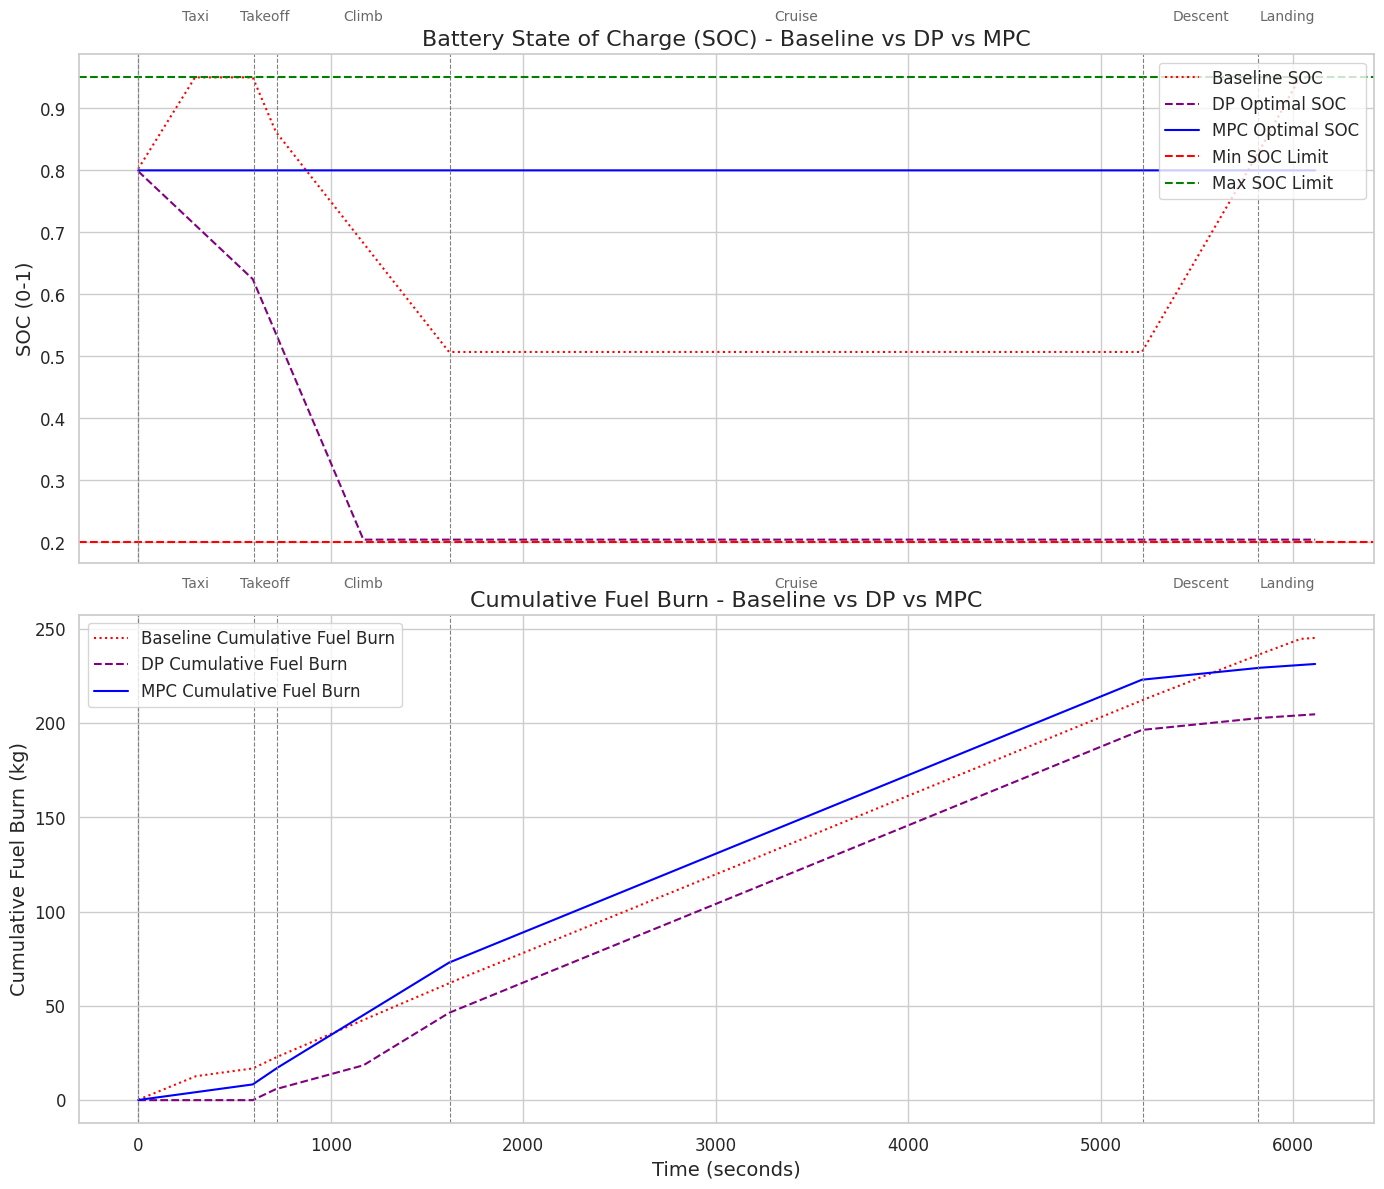

In [32]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# Plot 1: Battery SOC (Baseline vs DP vs MPC)
sns.lineplot(x='time_sec', y='soc', data=df_baseline, ax=axes[0], label='Baseline SOC', color='red', linestyle=':')
sns.lineplot(x='time_sec', y='soc', data=df_dp, ax=axes[0], label='DP Optimal SOC', color='purple', linestyle='--')
sns.lineplot(x='time_sec', y='soc', data=df_mpc, ax=axes[0], label='MPC Optimal SOC', color='blue')
axes[0].axhline(y=params.MIN_SOC, color='red', linestyle='--', label='Min SOC Limit')
axes[0].axhline(y=params.MAX_SOC, color='green', linestyle='--', label='Max SOC Limit')
axes[0].set_title('Battery State of Charge (SOC) - Baseline vs DP vs MPC')
axes[0].set_ylabel('SOC (0-1)')
axes[0].legend(loc='upper right')
axes[0].grid(True)

# Plot 2: Cumulative Fuel Burn (Baseline vs DP vs MPC)
df_mpc['cumulative_fuel_burn_kg'] = df_mpc['fuel_burn_kg'].cumsum()
sns.lineplot(x='time_sec', y='cumulative_fuel_burn_kg', data=df_baseline, ax=axes[1], label='Baseline Cumulative Fuel Burn', color='red', linestyle=':')
sns.lineplot(x='time_sec', y='cumulative_fuel_burn_kg', data=df_dp, ax=axes[1], label='DP Cumulative Fuel Burn', color='purple', linestyle='--')
sns.lineplot(x='time_sec', y='cumulative_fuel_burn_kg', data=df_mpc, ax=axes[1], label='MPC Cumulative Fuel Burn', color='blue')
axes[1].set_title('Cumulative Fuel Burn - Baseline vs DP vs MPC')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Cumulative Fuel Burn (kg)')
axes[1].legend(loc='upper left')
axes[1].grid(True)

# Add mission segment lines and labels to all plots
segment_start_time = 0
for segment_name, seg_data in mission.SEGMENTS.items():
    segment_end_time = segment_start_time + seg_data['duration']
    for ax in axes:
        ax.axvline(x=segment_start_time, color='gray', linestyle='--', linewidth=0.8)
        ax.text(segment_start_time + seg_data['duration']/2, ax.get_ylim()[1] * 1.05, segment_name,
                rotation=0, horizontalalignment='center', verticalalignment='bottom', fontsize=10, color='dimgray')
    segment_start_time = segment_end_time

plt.tight_layout()
plt.show()

## Sonuç ve Tercih Rehberliği

*   **DP:** Genellikle en iyi teorik performansı sunar (global optimum). Ancak, durum ve eylem uzayı büyüdükçe hesaplama maliyeti katlanarak artar ("boyutluluk laneti"). Karmaşık sistemler ve büyük zaman ufukları için çevrimdışı planlama veya politikanın önceden hesaplanması gereken durumlar için idealdir.

*   **MPC:** Gerçek zamanlı kontrol için daha uygundur. Belirsizliklere ve çevresel değişikliklere DP'den daha iyi uyum sağlar, çünkü her adımda yeniden optimize eder. Ancak, performans tahmin modelinin doğruluğuna ve ufuk uzunluğuna bağlıdır. Çevrimiçi uygulama ve kısıt yönetimi kritik olduğunda tercih edilir.

*   **RL:** Sistemin matematiksel modelinin tam olarak bilinmediği veya çok karmaşık olduğu durumlarda avantajlıdır. Deneyim yoluyla öğrenir ve teorik olarak çok karmaşık ortamlar için optimal politikalar geliştirebilir. Gelişmiş donanım ve uzun eğitim süreleri gerektirebilir. Adaptif ve otonom enerji yönetimi sistemleri için umut vadeden bir yöntemdir.

Optimal enerji yönetim stratejisi seçimi, uygulamanın özel gereksinimlerine, sistemin karmaşıklığına, mevcut hesaplama kaynaklarına ve kabul edilebilir performans toleransına bağlıdır. Genellikle hibrit yaklaşımlar (örneğin, RL ile tahmin ve MPC ile kontrol) en iyi sonuçları verebilir.

# BÖLÜM 13 – KARAR ZEKASI PERSPEKTİFİ

Bu defter boyunca, hibrit-elektrikli enerji yönetimi problemi için hem tahmin (Machine Learning) hem de optimizasyon (DP, MPC, RL) tekniklerini ayrı ayrı ele aldık. Karar Zekası (Decision Intelligence), bu yaklaşımları birleştirerek daha bütünsel ve güçlü karar verme sistemleri oluşturmayı amaçlar. Basitçe söylemek gerekirse, Karar Zekası, veriye dayalı öngörüleri (tahmin) operasyonel eylemlere (optimizasyon) dönüştürme bilimidir.

## Karar Zekası Ekosistemi

Hibrit-elektrikli hava taşıtı enerji yönetimi bağlamında, bir Karar Zekası ekosistemi aşağıdaki bileşenleri içerebilir:

1.  **Veri Toplama ve Mühendisliği:** Uçuş sensörlerinden (güç talebi, SOC, motor durumu, hız, irtifa), hava durumu verilerinden ve görev profillerinden sürekli veri akışı. Bu verilerin temizlenmesi, dönüştürülmesi ve analiz için hazır hale getirilmesi.

2.  **Tahmine Dayalı Analitik (Predictive Analytics):** Gelecekteki olayları öngörmek için makine öğrenimi modellerinin kullanılması. Örneğin, gelecekteki irtifa, hız, rüzgar koşulları ve dolayısıyla güç talebi, batarya deşarj oranları, turboprop verimlilik eğrileri vb. Bu tahminler, optimizasyon algoritmaları için kritik girdiler sağlar.

3.  **Prescriptive Analytics (Optimizasyon):** Tahmin modellerinden elde edilen öngörüleri kullanarak en iyi eylem planını belirlemek. Bu, DP, MPC veya RL gibi yöntemlerle yapılabilir. Amaç, belirli hedefler doğrultusunda (yakıtı minimize etmek, batarya ömrünü uzatmak, görev güvenliğini sağlamak) ne yapılması gerektiğini ortaya koymaktır.

4.  **Simülasyon ve Senaryo Modelleme:** Farklı stratejilerin veya belirsizliklerin etkilerini değerlendirmek için

## Entegre Bir Yaklaşım: Tahmin + Optimizasyon

Makine öğrenimi tabanlı tahmin modelleri, optimizasyon algoritmalarını daha akıllı ve verimli hale getirebilir:

*   **MPC'nin Güçlendirilmesi:** Bölüm 9'da gördüğümüz MPC, tahmin ufkundaki gelecekteki güç taleplerine ihtiyaç duyar. Bölüm 10'da geliştirilen ML modelleri, bu tahminleri çok daha doğru ve adaptif bir şekilde sağlayarak MPC'nin performansını önemli ölçüde artırabilir. Örneğin, gerçek zamanlı hava durumu verileri veya beklenmedik rüzgar koşulları bir ML modeline beslenerek gelecekteki güç talebi tahminleri güncellenebilir ve MPC bu yeni tahminlere göre optimal kararlar alabilir.

*   **RL için Ödül Tasarımı ve Durum Temsili:** RL ajanları için ödül fonksiyonlarının ve durum uzayının tasarlanmasında tahmin modellerinden elde edilen bilgiler kullanılabilir. Örneğin, bir ML modeli gelecekteki batarya degradasyonunu tahmin edebiliyorsa, bu bilgi RL ödülüne entegre edilerek batarya sağlığı daha etkili bir şekilde yönetilebilir.

*   **DP için Senaryo Planlaması:** DP genellikle statik görev profilleri üzerinde çalışır. Ancak, ML modelleri tarafından üretilen farklı olası gelecekteki senaryolar (örn. değişen hava koşulları, gecikmeler) için DP'nin önceden çalıştırılması ve birden fazla politikanın hazır bulundurulması ('multi-policy' yaklaşımı) mümkündür. Gerçek zamanlı bir senaryo seçimi, bir başka ML veya basit kural tabanlı bir karar mekanizması tarafından yapılabilir.

Bu entegrasyonlar, sadece yakıt tüketimini azaltmakla kalmaz, aynı zamanda batarya ömrünü uzatır, operasyonel esnekliği artırır ve beklenmedik durumlar karşısında daha sağlam sistemler yaratır. Karar Zekası, havacılıkta enerji yönetimi gibi karmaşık problemler için ileriye dönük, proaktif ve adaptif çözümlerin anahtarıdır.

# BÖLÜM 14 – GELİŞMİŞ UZANTILAR VE PRATİK DÜŞÜNCELER

Bu defterde, hibrit-elektrikli hava taşıtlarında enerji yönetimi optimizasyonunun temellerini kural tabanlı stratejilerden Dinamik Programlama (DP), Model Tahminli Kontrol (MPC) ve Takviyeli Öğrenme (RL) gibi gelişmiş yöntemlere kadar geniş bir yelpazede ele aldık. Ayrıca, hassasiyet ve sağlamlık analizleri ile ML tabanlı tahminin rolünü inceledik. Gerçek dünya uygulamaları için bu modellerin ve yaklaşımların daha da geliştirilmesi gerekmektedir. Bu bölümde, potansiyel olarak ileriye dönük araştırma alanları ve pratik uygulamalar için önemli uzantıları tartışacağız.

## 1. Çok Amaçlı Optimizasyon (Multi-objective Optimization)

Şu ana kadar genellikle yakıt tüketimini minimize etmeye odaklandık. Ancak, gerçek sistemlerde birden fazla, çoğu zaman birbiriyle çelişen hedef bulunur:

*   **Yakıt Tüketimi (Fuel Consumption):** Minimize et.
*   **Batarya Ömrü/Sağlığı (Battery Life/SOH):** Minimize et (degradasyonu azalt).
*   **Emisyonlar (Emissions):** Minimize et.
*   **Operasyonel Maliyetler (Operational Costs):** Minimize et.
*   **Gürültü (Noise):** Minimize et.

Bu hedefleri dengelemek için **Pareto optimizasyonu** gibi çok amaçlı teknikler kullanılabilir. Bu, mühendislerin farklı hedefler arasındaki ödünleşmeleri (trade-off) anlamalarına olanak tanıyan bir dizi 'Pareto optimal' çözüm kümesi üretir.

## 2. Gerçek Zamanlı Optimizasyon ve Adaptif Kontrol

MPC, çevrimiçi optimizasyon yeteneği sunarken, hava taşıtının dinamik ortamına tamamen uyum sağlamak için daha gelişmiş adaptif kontrol stratejilerine ihtiyaç duyulabilir. Örneğin:

*   **Adaptif MPC:** Model parametrelerinin (örn. motor verimliliği, batarya direnci) uçuş sırasında tahmin edilerek MPC modelinin güncellenmesi.
*   **Hiyerarşik Kontrol:** Üst düzey bir planlayıcının uzun vadeli stratejileri belirlemesi ve alt düzey kontrolörlerin bu stratejileri gerçek zamanlı olarak uygulaması.
*   **Öğrenmeye Dayalı Kontrol:** RL ajanlarının, sürekli öğrenme döngüleri aracılığıyla ortamdaki değişikliklere (örn. motor arızası, beklenmedik hava koşulları) gerçek zamanlı olarak adapte olması.

## 3. Uçuş Yönetim Sistemleri (FMS) ile Entegrasyon

Önerilen enerji yönetim stratejilerinin, mevcut Uçuş Yönetim Sistemleri (FMS) ve aviyoniklerle entegrasyonu kritik öneme sahiptir. Bu, FMS'nin uçuş planı, hava durumu, trafik bilgileri gibi verileri enerji yöneticisine sağlaması ve enerji yöneticisinin kararlarını FMS'ye geri bildirmesi anlamına gelir. Standart arayüzler ve iletişim protokolleri bu entegrasyon için geliştirilmelidir.

## 4. Belirsizlik Kuantifikasyonu ve Stokastik Kontrol

Bölüm 8'de Monte Carlo analiziyle belirsizliği ele aldık. Ancak, daha sofistike yaklaşımlar şunları içerebilir:

*   **Stokastik Dinamik Programlama (Stochastic DP):** Belirsiz parametreleri olasılık dağılımları ile doğrudan modelleyerek, beklenen en iyi politikayı bulmaya çalışır.
*   **Sağlam Model Tahminli Kontrol (Robust MPC):** Belirsizliği en kötü durum senaryoları üzerinden ele alarak sistemin her türlü olası belirsizlik altında performans garantisi vermesini hedefler.
*   **Öğrenmeye Dayalı Belirsizlik Yönetimi:** RL ajanlarının, öğrenme süreçleri sırasında belirsizlikleri doğrudan deneyimleyerek bunlara dayanıklı politikalar geliştirmesi.

## 5. Fizik Bilgili Makine Öğrenimi (Physics-Informed Machine Learning - PIML)

ML modellerinin (Bölüm 10'da olduğu gibi) performansını artırmak için fiziksel yasalarla birleştirilebilirler. PIML, ML modellerinin öğrenme sürecine bilinen fiziksel denklemleri veya kısıtlamaları dahil ederek daha genellenebilir, yorumlanabilir ve fiziksel olarak tutarlı tahminler ve politikalar üretir. Bu, özellikle veri sınırlı havacılık uygulamalarında değerli olabilir.

## 6. Dijital İkizler ve Tahmine Dayalı Sağlık Yönetimi (PHM)

Hibrit-elektrikli hava taşıtının kapsamlı bir dijital ikizi (digital twin), enerji yönetim stratejilerinin test edilmesi, optimize edilmesi ve uygulanması için sanal bir platform sağlayabilir. Dijital ikizler, sensör verilerini kullanarak sistemin mevcut durumunu yansıtır ve gelecekteki performansını tahmin etmek için kullanılabilir. Bu, batarya degradasyonu, motor arızaları ve diğer sistem sağlığı göstergelerinin tahmini için Tahmine Dayalı Sağlık Yönetimi (Prognostics and Health Management - PHM) yeteneklerini de destekleyebilir.

## 7. Hesaplama Verimliliği

Gerçek zamanlı ve gömülü uygulamalar için hesaplama maliyetini düşürmek önemlidir:

*   **Yaklaşık Dinamik Programlama (Approximate DP):** Büyük durum uzayları için tam DP'nin yerine, durum veya değer fonksiyonlarını yaklaştıran algoritmalar (örn. Bellman denklemini çözmek için fonksiyon yaklaştırıcılar).
*   **Model Redüksiyonu:** Karmaşık sistem modellerini, temel dinamikleri koruyarak daha basit modellere indirgeme.
*   **Paralel Hesaplama ve GPU Kullanımı:** Büyük ölçekli optimizasyon ve RL eğitimlerini hızlandırmak için paralel işleme ve GPU'lardan yararlanma.

Bu gelişmiş uzantılar ve düşünceler, hibrit-elektrikli hava taşıtlarında enerji yönetimini daha pratik, verimli ve sağlam hale getirmek için mevcut temel çalışmaları ileriye taşıyacaktır.

# BÖLÜM 15 – FİNAL ÖZET VE SONUÇ

Bu kapsamlı Google Colab defterinde, hibrit-elektrikli hava taşıtlarında enerji yönetimi optimizasyonunun çeşitli yönlerini keşfettik. Havacılık Mühendisleri, Optimizasyon Uzmanları, Kontrol Sistemleri Mühendisleri, Takviyeli Öğrenme Araştırmacıları ve Python Geliştiricileri için tasarlanan bu çalışma, Sequential Decision Making (Ardışık Karar Verme), Dynamic Programming (Dinamik Programlama), Energy Management (Enerji Yönetimi), Predictive Modeling (Tahmine Dayalı Modelleme), Reinforcement Learning (Takviyeli Öğrenme) ve Aerospace Applications (Havacılık Uygulamaları) gibi temel kavramları bir araya getirdi. Ana odak noktamız, yakıt verimliliğini artırmak ve batarya sağlığını korumak için en uygun enerji dağıtım stratejilerini belirlemekti.

## Temel Çıkarımlar

1.  **Problemin Kapsamı ve Zorlukları:** Hibrit-elektrikli tahrik sistemleri, yakıt ekonomisi ve emisyon azaltma potansiyeli sunarken, güç kaynakları arasında optimal bir denge kurmayı gerektiren karmaşık bir enerji yönetimi problemi ortaya koymaktadır. Kararlar, uçuş fazı, batarya durumu ve güç talebi gibi birçok faktöre bağlıdır.

2.  **Kural Tabanlı Stratejiler:** Basit kural tabanlı stratejiler, görevi tamamlayabilir ancak genellikle sub-optimal sonuçlar verirler. Bunlar, daha gelişmiş optimizasyon teknikleri için bir referans noktası sağlar.

3.  **Dinamik Programlama (DP):** DP, durum ve eylem uzayının uygun şekilde ayrıklaştırılması durumunda global optimal çözümler sunan güçlü bir çevrimdışı optimizasyon yöntemidir. Yakıt tüketimini en aza indirmede üstün performans gösterdiği, ancak final SOC üzerinde ek bir maliyet olmadıkça bataryayı minimum sınıra kadar kullanma eğiliminde olduğu gözlemlenmiştir. "Curse of dimensionality" (Boyutluluk laneti) nedeniyle büyük sistemlerde hesaplama maliyeti yüksek olabilir.

4.  **Model Tahminli Kontrol (MPC):** MPC, her adımda kısa bir tahmin ufku üzerinde optimizasyon yaparak gerçek zamanlı ve adaptif kontrol imkanı sunar. DP kadar global optimal olmasa da, belirsizliklere karşı daha esnek ve çevrimiçi uygulamalar için daha uygundur. Performansı, tahmin modelinin doğruluğuna ve ufuk uzunluğuna bağlıdır.

5.  **Makine Öğrenimi ile Tahmin:** Güç talebi gibi kritik sistem parametrelerini tahmin etmek için makine öğrenimi modellerinin (Random Forest, Gradient Boosting) kullanılması, optimizasyon algoritmalarına (özellikle MPC) değerli 'öngörü' sağlar. Doğru tahminler, daha akıllı ve proaktif karar vermeyi mümkün kılar.

6.  **Hassasiyet ve Sağlamlık Analizi:** Parametre hassasiyet analizi, tasarım ve operasyonel kararlar için kritik bilgiler sağlar, sistem performansının hangi parametrelere karşı daha duyarlı olduğunu gösterir. Monte Carlo sağlamlık analizi, belirsizlik altındaki performans dağılımını anlamamıza ve çözümün güvenilirliğini değerlendirmemize yardımcı olur.

7.  **Takviyeli Öğrenme (RL):** RL, sistemin modelinin tam olarak bilinmediği karmaşık ortamlarda deneyim yoluyla optimal politikaları öğrenmek için umut vadeden bir yaklaşım sunar. Adaptif ve otonom enerji yönetimi sistemleri için gelecekteki potansiyeli yüksektir, ancak eğitimi genellikle yüksek hesaplama maliyetleri ve uzun süreler gerektirir.

8.  **Karar Zekası (Decision Intelligence):** Tahmin ve optimizasyonun entegrasyonu olan Karar Zekası, veri tabanlı öngörüleri eyleme dönüştürerek daha bütünsel ve güçlü enerji yönetim sistemleri oluşturmanın anahtarıdır. Bu entegrasyon, yakıt verimliliğini, batarya sağlığını ve operasyonel güvenliği artırabilir.

## Gelecek Çalışmalar ve Gelişmeler

Bu defter, hibrit-elektrikli enerji yönetiminin temel bir incelemesini sunmaktadır. Gerçek dünya uygulamaları için aşağıdaki alanlarda daha fazla gelişme gerekmektedir:

*   **Çok Amaçlı Optimizasyon:** Yakıt, emisyon, batarya ömrü gibi birden fazla hedefi aynı anda optimize etmek.
*   **Gelişmiş Adaptif Kontrol:** Gerçek zamanlı değişen koşullara daha iyi uyum sağlayan ve öğrenmeye dayalı kontrol stratejileri.
*   **Fizik Bilgili Makine Öğrenimi (PIML):** ML modellerini fiziksel yasalarla birleştirerek daha sağlam ve yorumlanabilir tahminler elde etmek.
*   **Dijital İkizler:** Gerçek sistemlerin sanal temsillerini kullanarak tasarım, test ve bakım süreçlerini optimize etmek.
*   **Hesaplama Verimliliği:** Gerçek zamanlı ve gömülü sistemler için hesaplama maliyetini düşüren algoritmalar ve donanım optimizasyonları.

Bu alandaki sürekli araştırma ve geliştirme, havacılıkta daha sürdürülebilir, verimli ve güvenli hibrit-elektrikli hava taşıtlarının önünü açacaktır. Bu defterde sunulan yöntemler ve analizler, bu heyecan verici ve kritik alandaki çalışmalar için sağlam bir temel oluşturmaktadır. Hava taşıtı sistemlerinin Karmaşıklığı ve Dinamik yapısı, sürekli öğrenme ve optimizasyon ihtiyacını vurgulamaktadır. Bu, havacılık alanında çalışan mühendis ve araştırmacılar için sonsuz bir keşif ve inovasyon alanı sunmaktadır.

## BÖLÜM 16 – OPTİMİZASYON İÇİN İLERİ MATEMATİKSEL TEMELLER

Bu bölümde, defterde ele aldığımız optimizasyon tekniklerinin altında yatan matematiksel prensipleri daha detaylı inceleyeceğiz. Amaç, özellikle ardışık karar verme problemlerinin nasıl matematiksel olarak formüle edildiğini ve çözüldüğünü göstermektir.

### Dinamik Programlama (DP): Bellman Denklemi

Dinamik Programlama'nın kalbinde, optimalite prensibini matematiksel olarak ifade eden **Bellman Denklemi** bulunur. Bu prensip, optimal bir politikanın özelliğini belirtir: Geçmiş kararlardan bağımsız olarak, mevcut durumdan itibaren kalan kararlar, mevcut durumun kendisinden başlayarak optimal bir strateji oluşturur.

Bir zaman adımı $t$'de $s$ durumunda bulunan bir sistem için, gelecekteki beklenen en düşük maliyet (veya en yüksek ödül) $V(s_t)$ şu şekilde ifade edilebilir:

$V(s_t) = \min_{a_t \in \mathcal{A}(s_t)} \left( C(s_t, a_t) + \gamma \sum_{s_{t+1}} P(s_{t+1} | s_t, a_t) V(s_{t+1}) \right)$

Burada:
*   $V(s_t)$: $s_t$ durumundan başlayarak elde edilebilecek optimal maliyet-to-go veya değer fonksiyonu.
*   $a_t$: $s_t$ durumunda seçilebilecek eylem.
*   $\mathcal{A}(s_t)$: $s_t$ durumunda alınabilecek tüm olası eylemler kümesi.
*   $C(s_t, a_t)$: $s_t$ durumunda $a_t$ eylemini almanın anlık maliyeti (bizim durumumuzda yakıt tüketimi).
*   $\gamma$: İndirgeme faktörü (discount factor), gelecekteki maliyetlerin bugünkü değerini ağırlıklandırır (genellikle 0 ile 1 arası). Deterministik sonlu ufuk problemlerinde $\gamma=1$ alınabilir.
*   $P(s_{t+1} | s_t, a_t)$: $s_t$ durumunda $a_t$ eylemini aldıktan sonra $s_{t+1}$ durumuna geçiş olasılığı.
*   $V(s_{t+1})$: Bir sonraki durum olan $s_{t+1}$'den başlayarak elde edilecek optimal maliyet.

Bu denklemi çözmek için genellikle **Değer Yinelemesi (Value Iteration)** veya **Politika Yinelemesi (Policy Iteration)** algoritmaları kullanılır. Bizim örneklemimizde, sonlu ve deterministik bir ufukta geriye dönük (backward pass) bir çözüm uyguladık.

### Model Tahminli Kontrol (MPC): Optimizasyon Problemi

Model Tahminli Kontrol (MPC), her zaman adımında belirli bir tahmin ufku boyunca bir optimizasyon problemi çözer. Sürekli durum ve eylem alanlarına sahip sistemler için bu genellikle bir sonlu ufuk optimal kontrol problemi olarak formüle edilir. Diskrit zamanlı bir sistem için MPC, her $t$ zaman adımında aşağıdaki optimizasyon problemini çözer:

**Minimize et:** $J(x_t, u_t, N_p) = \sum_{k=0}^{N_p-1} \mathcal{L}(x_{t+k|t}, u_{t+k|t}) + E(x_{t+N_p|t})$

**Konuya göre:**
*   $x_{t+k+1|t} = f(x_{t+k|t}, u_{t+k|t})$ (Sistem Dinamiği)
*   $x_{min} \le x_{t+k|t} \le x_{max}$ (Durum Kısıtlamaları)
*   $u_{min} \le u_{t+k|t} \le u_{max}$ (Eylem Kısıtlamaları)
*   $h(x_{t+k|t}, u_{t+k|t}) \le 0$ (Genel Kısıtlamalar)

Burada:
*   $x_t$: Mevcut durum vektörü ($SOC_t, W_t, \dots$).
*   $u_t$: Kontrol eylem vektörü ($P_{turboprop, t}, P_{electric, t}$). Bizim basitleştirilmiş örneğimizde $u_t$ sadece elektrik motoru gücünü temsil etti ve turboprop gücü talebi karşılamak için türetildi.
*   $N_p$: Tahmin ufku (prediction horizon).
*   $x_{t+k|t}$: $t$ anında tahmin edilen $t+k$ anındaki durum.
*   $u_{t+k|t}$: $t$ anında $t+k$ için optimize edilen kontrol eylemi.
*   $\mathcal{L}(x, u)$: $x$ durumunda $u$ eylemini uygulamanın anlık maliyeti (genellikle yakıt tüketimi ve SOC sapma cezaları).
*   $E(x_{t+N_p|t})$: Ufuk sonundaki terminal maliyet (örn. final SOC'yi belirli bir aralıkta tutma cezası).
*   $f(\cdot)$: Sistem dinamiğini tanımlayan durum geçiş fonksiyonu.
*   $h(\cdot) \le 0$: Sistemin uyması gereken herhangi bir eşitsizlik kısıtlaması.

Bu optimizasyon problemi genellikle her zaman adımında bir **Sırasal Kuadratik Programlama (Sequential Quadratic Programming - SQP)** veya diğer sayısal optimizasyon yöntemleri kullanılarak çözülür. Bizim örneğimizde `scipy.optimize.minimize` fonksiyonu ile basitleştirilmiş bir yaklaşım kullandık.

### Takviyeli Öğrenme (RL): Q-Learning Güncelleme Kuralı

Takviyeli Öğrenme'de bir ajanın amacı, uzun vadeli ödülü maksimize eden bir politika öğrenmektir. Q-Learning, model-free, off-policy bir RL algoritmasıdır ve her durum-eylem çifti için bir 'Q-değeri' öğrenir. Bu Q-değeri, o durumu ziyaret ettikten sonra o eylemi almanın ve ardından optimal politikayı takip etmenin beklenen toplam gelecekteki ödülünü temsil eder.

$Q(s_t, a_t)$ değeri, ajanın $s_t$ durumunda $a_t$ eylemini almasının ve ardından gelecekte optimal politikayı takip etmesinin beklenen maksimum gelecekteki ödülüdür. Q-Learning algoritması, bu Q-değerlerini iteratif olarak aşağıdaki güncelleme kuralını kullanarak öğrenir:

$Q(s_t, a_t) \leftarrow Q(s_t, a_t) + \alpha \left[ r_{t+1} + \gamma \max_{a_{t+1}} Q(s_{t+1}, a_{t+1}) - Q(s_t, a_t) \right]$

Burada:
*   $Q(s_t, a_t)$: Mevcut durum $s_t$ ve eylem $a_t$ için Q-değeri.
*   $\alpha$: Öğrenme oranı (learning rate), ajanın her güncellemede ne kadar öğrenmesi gerektiğini belirler (0 ile 1 arası).
*   $r_{t+1}$: $s_t$ durumunda $a_t$ eylemini aldıktan sonra alınan anlık ödül (bizim durumumuzda negatif yakıt tüketimi ve SOC cezaları).
*   $\gamma$: İndirgeme faktörü (discount factor), gelecekteki ödüllerin bugünkü değerini ağırlıklandırır (0 ile 1 arası).
*   $s_{t+1}$: $s_t$ durumunda $a_t$ eylemini aldıktan sonra ulaşılan bir sonraki durum.
*   $\max_{a_{t+1}} Q(s_{t+1}, a_{t+1})$: $s_{t+1}$ durumunda alınabilecek tüm olası eylemler arasından en yüksek Q-değeri, yani bir sonraki durumda izlenecek en iyi politika.

Bu güncelleme kuralı, ajanın deneme yanılma yoluyla optimal Q-değerlerini yakınsamasını sağlar. Yeterli keşif ve yeterince uzun eğitim ile ajan, her durum için en iyi eylemi seçmeyi öğrenerek optimal bir politika elde edebilir.

## BÖLÜM 17 – OPTİMİZASYON ALGORİTMALARININ SAYISAL ANALİZİ

Bu bölümde, önceki kısımlarda uygulanan Dinamik Programlama (DP), Model Tahminli Kontrol (MPC) ve Takviyeli Öğrenme (RL) algoritmalarının sayısal çözüm yöntemleri ve performans karakteristikleri üzerine daha derinlemesine bir analiz yapacağız. Optimizasyon problemlerini çözmek için kullanılan matematiksel tekniklerin sayısal uygulama detaylarına odaklanacağız.

### Dinamik Programlama (DP): Sayısal Çözüm Yöntemleri ve Yakınsama

Bellman Denklemi'nin sayısal çözümü için en yaygın kullanılan yöntemler **Değer Yinelemesi (Value Iteration)** ve **Politika Yinelemesi (Policy Iteration)**'dir. Defterimizde basit bir geriye dönük (backward pass) DP çözümü uyguladık ki bu, sonlu ufuklu deterministik problemler için Değer Yinelemesi'nin özel bir halidir.

#### Değer Yinelemesi (Value Iteration)

Değer yinelemesi, değer fonksiyonunu ($V(s)$) tahmin ederek optimal politikayı bulan bir yöntemdir. Başlangıçta rastgele bir değer fonksiyonu $V_0(s)$ ile başlar ve aşağıdaki yinelemeli adımı kullanarak $V_k(s)$'i günceller:

$V_{k+1}(s) = \min_{a \in \mathcal{A}(s)} \left( C(s, a) + \gamma \sum_{s'} P(s' | s, a) V_k(s') \right)$

Bu süreç, $V_k(s)$ belirli bir $\epsilon$ toleransı içinde yakınsayana kadar devam eder, yani $|V_{k+1}(s) - V_k(s)| < \epsilon$ olur.

*   **Yakınsama Garantisi:** Eğer indirgeme faktörü $\gamma \in [0, 1)$ ise, değer yinelemesinin benzersiz bir optimal değer fonksiyonuna yakınsadığı garantidir.
*   **Hesaplama Maliyeti:** Her iterasyonda tüm durumlar ve tüm eylemler üzerinden geçilir. Durum sayısı $N$ ve eylem sayısı $M$ ise, her iterasyonun maliyeti $O(N^2 M)$ (eğer geçiş fonksiyonu seyrek değilse) veya $O(N M)$ (eğer geçiş olasılıkları $P(s'|s,a)$ biliniyorsa) olabilir.

#### Politika Yinelemesi (Policy Iteration)

Politika yinelemesi iki ana adımdan oluşur:

1.  **Politika Değerlemesi (Policy Evaluation):** Mevcut bir $\pi$ politikası için değer fonksiyonu $V^\pi(s)$'i hesaplar:
    $V^\pi(s) = C(s, \pi(s)) + \gamma \sum_{s'} P(s' | s, \pi(s)) V^\pi(s')$
    Bu genellikle bir denklem sisteminin çözümü veya yinelemeli yöntemlerle yapılır.

2.  **Politika İyileştirme (Policy Improvement):** Yeni bir politika $\pi'$'i, mevcut değer fonksiyonuna göre açgözlü (greedy) bir şekilde oluşturur:
    $\pi'(s) = \arg\min_{a \in \mathcal{A}(s)} \left( C(s, a) + \gamma \sum_{s'} P(s' | s, a) V^\pi(s') \right)$

Bu adımlar politika değişmeyene kadar tekrarlanır. Politika yinelemesi, genellikle değer yinelemesinden daha az iterasyonda yakınsasa da, her iterasyon daha maliyetli olabilir.

Defterimizdeki DP uygulaması, sonlu ufuklu olması nedeniyle, son zaman adımından geriye doğru giderek her adımda optimal eylemi ve maliyeti hesaplar. Bu, belirli bir ufuk için optimal politikayı doğrudan verir ve yinelemeli bir yakınsama adımına ihtiyaç duymaz, çünkü ufuk sabittir.

#### Durum Ayrıştırma (State Discretization) Örneği

Dinamik Programlama'da sürekli durumları yönetmek için ayrıştırma kritik öneme sahiptir. Aşağıdaki kod, Sürekli SOC (State of Charge) değerlerinin nasıl ayrık bir dizine eşlendiğini gösteren basitleştirilmiş bir örnektir. Bu, `solve_dp` fonksiyonumuzda da kullanılmıştır.

In [36]:
def discretize_soc(current_soc_value, soc_states_array):
    """
    Sürekli bir SOC değerini, ayrık SOC durumları dizisindeki en yakın dizine eşler.
    """
    soc_idx = np.argmin(np.abs(soc_states_array - current_soc_value))
    return soc_idx

# Mevcut SOC durumları dizisini kullanın
print(f"SOC Durumları: {SOC_STATES[:5]} ... {SOC_STATES[-5:]}")

# Örnek sürekli SOC değerleri
sample_soc_values = [0.75, 0.205, 0.94]

print("\nSürekli SOC değerlerini ayrık dizinlere eşleme:")
for soc_val in sample_soc_values:
    discretized_idx = discretize_soc(soc_val, SOC_STATES)
    print(f"  Sürekli SOC {soc_val:.3f} -> Ayrık Dizin: {discretized_idx}, Eşleşen Ayrık SOC: {SOC_STATES[discretized_idx]:.3f}")

SOC Durumları: [0.2   0.215 0.23  0.245 0.26 ] ... [0.89  0.905 0.92  0.935 0.95 ]

Sürekli SOC değerlerini ayrık dizinlere eşleme:
  Sürekli SOC 0.750 -> Ayrık Dizin: 37, Eşleşen Ayrık SOC: 0.755
  Sürekli SOC 0.205 -> Ayrık Dizin: 0, Eşleşen Ayrık SOC: 0.200
  Sürekli SOC 0.940 -> Ayrık Dizin: 49, Eşleşen Ayrık SOC: 0.935


### Model Tahminli Kontrol (MPC): Sayısal Optimizasyon ve Kısıt Yönetimi

MPC, her zaman adımında çözülmesi gereken bir dizi optimizasyon problemi içerir. Defterimizde `scipy.optimize.minimize` fonksiyonunu kullanarak basitleştirilmiş bir yaklaşım uyguladık. Gerçek MPC uygulamalarında bu problemler genellikle büyük ölçekli ve doğrusal olmayan (Non-linear Programming - NLP) problemlerdir.

#### Optimizasyon Probleminin Çözümü

MPC'nin formülasyonu, bir amaç fonksiyonunun (yakıt tüketimi, SOC sapması gibi) sistem dinamikleri ve durum/eylem kısıtlamaları altında minimize edilmesini gerektirir. Bu tür problemler için kullanılan yaygın sayısal yöntemler şunlardır:

*   **Sırasal Kuadratik Programlama (Sequential Quadratic Programming - SQP):** Her iterasyonda bir kuadratik programlama (QP) problemi çözerek doğrusal olmayan kısıtlamalı optimizasyon problemlerini çözer. Defterimizde kullanılan `SLSQP` (`Sequential Least Squares Programming`) da bu kategoridendir ve genellikle küçük ila orta ölçekli NLP'ler için etkilidir.
*   **İç Nokta Metotları (Interior-Point Methods):** Kısıtlamaları bir 'bariyer' fonksiyonuna dönüştürerek kısıtlı problemi kısıtsız bir dizi probleme çevirir ve ardından Newton benzeri yöntemlerle çözer. Büyük ölçekli ve seyrek problemler için çok etkilidirler.
*   **Gradyan Tabanlı Yöntemler (Gradient-Based Methods):** Amaç fonksiyonunun gradyanını (veya Hessian'ını) kullanarak optimal çözüme doğru ilerler. Bu yöntemler, eğer amaç fonksiyonu ve kısıtlamaların türevleri analitik olarak alınabiliyor veya sayısal olarak tahmin edilebiliyorsa verimlidir.

#### Kısıt Yönetimi

MPC'nin en güçlü yönlerinden biri kısıtları doğrudan dikkate alabilmesidir. Enerji yönetimi örneğimizde SOC limitleri ($SOC_{min} \le SOC_t \le SOC_{max}$), güç limitleri ($0 \le P_{turboprop,t} \le P_{turboprop,max}$) ve elektrik motorunun hem deşarj hem de şarj kapasitesi ($P_{electric,min} \le P_{electric,t} \le P_{electric,max}$) gibi kısıtlamalar mevcuttur.

Sayısal optimizasyon algoritmaları bu kısıtları farklı şekillerde ele alır:

*   **Doğrudan Kısıtlama İşleme:** SQP veya İç Nokta Metotları gibi algoritmalar, kısıtları doğrudan optimizasyon probleminin bir parçası olarak değerlendirir.
*   **Penaltı Fonksiyonları:** Kısıt ihlallerini amaç fonksiyonuna ek bir 'ceza' terimi olarak dahil ederek kısıtlı problemi kısıtsız bir probleme dönüştürür. Defterimizdeki `mpc_objective` fonksiyonunda SOC ihlali için uygulanan `1e9` gibi büyük penaltılar bu yaklaşıma bir örnektir.

Bu sayısal optimizasyon tekniklerinin verimliliği ve yakınsama garantileri, seçilen yönteme, problemin doğrusallığına/doğrusal olmamasına ve gradyan bilgilerinin mevcudiyetine bağlıdır.

#### `scipy.optimize.minimize` ile Basit Optimizasyon Örneği

Model Tahminli Kontrol'ün kalbinde, her zaman adımında çözülen bir optimizasyon problemi yer alır. Aşağıdaki kod bloğu, `scipy.optimize.minimize` fonksiyonunun basit bir amaç fonksiyonunu ve kısıtlamaları kullanarak nasıl optimize ettiğini gösterir. Bu, `simulate_mission_mpc` fonksiyonumuzda kullanılan yönteme benzerdir.

In [37]:
from scipy.optimize import minimize

# Örnek amaç fonksiyonu: f(x) = (x[0] - 1)^2 + (x[1] - 2.5)^2
def objective(x):
    return (x[0] - 1)**2 + (x[1] - 2.5)**2

# Kısıtlamalar: x[0] + 2*x[1] - 2 <= 0
#               -x[0] - 2*x[1] + 6 <= 0
#               -x[0] + 2*x[1] - 2 <= 0
def constraint1(x):
    return x[0] + 2 * x[1] - 2

def constraint2(x):
    return -x[0] - 2 * x[1] + 6

def constraint3(x):
    return -x[0] + 2 * x[1] - 2

# Başlangıç tahmini
x0 = np.array([0, 0])

# Bounds (sınırlar): 0 <= x[0] <= 2, 0 <= x[1] <= 3
bounds = ((0, 2), (0, 3))

# Kısıtlama yapıları (eşitsizlik kısıtlamaları için type='ineq')
constraints = (
    {'type': 'ineq', 'fun': constraint1},
    {'type': 'ineq', 'fun': constraint2},
    {'type': 'ineq', 'fun': constraint3}
)

# Optimizasyonu çalıştırın
solution = minimize(objective, x0, method='SLSQP', bounds=bounds, constraints=constraints)

print("\n--- `scipy.optimize.minimize` ile Basit Optimizasyon Örneği ---")
print(f"Optimum Çözüm (x): {solution.x}")
print(f"Minimum Amaç Fonksiyon Değeri: {solution.fun}")
print(f"Başarı: {solution.success}")
print(f"Mesaj: {solution.message}")


--- `scipy.optimize.minimize` ile Basit Optimizasyon Örneği ---
Optimum Çözüm (x): [1.  2.5]
Minimum Amaç Fonksiyon Değeri: 7.61082171973333e-21
Başarı: True
Mesaj: Optimization terminated successfully


### Takviyeli Öğrenme (RL): Q-Learning'in Sayısal Yakınsama ve Parametre Hassasiyeti

Q-Learning, Bellman Denklemi'nin stokastik bir yinelemesini kullanarak Q-değerlerini öğrenir. Sayısal olarak, bu öğrenme sürecinin yakınsaması ve performansı, hiperparametre seçimine büyük ölçüde bağlıdır.

#### Sayısal Yakınsama

Q-Learning algoritmasının optimal Q-değerlerine yakınsadığı ispatlanmıştır, ancak bu belirli koşullar altında geçerlidir:

*   **Yeterli Keşif (Sufficient Exploration):** Ajanın, her durum-eylem çiftini sonsuz kere ziyaret etmesi gerekir. Bu genellikle $\epsilon$-açgözlü ($\epsilon$-greedy) politika gibi yöntemlerle sağlanır, burada ajan belirli bir $\epsilon$ olasılıkla rastgele bir eylem seçer ve kalan $1-\epsilon$ olasılıkla bilinen en iyi eylemi seçer.
*   **Uygun Öğrenme Oranı (Appropriate Learning Rate - $\alpha$):** Öğrenme oranı, her güncellemede ne kadar yeni bilginin dikkate alınacağını belirler. Optimal yakınsama için genellikle $\sum_{k=0}^{\infty} \alpha_k = \infty$ ve $\sum_{k=0}^{\infty} \alpha_k^2 < \infty$ koşulunu sağlayan azalan bir öğrenme oranı kullanılır. Ancak pratikte sabit ve küçük bir $\alpha$ değeri de iyi sonuçlar verebilir.
*   **İndirgeme Faktörü (Discount Factor - $\gamma$):** $\gamma \in [0, 1)$ olmalıdır. Optimal Q-değerlerinin varlığı için bu kritiktir. Yüksek $\gamma$ değerleri ajanın gelecekteki ödüllere daha fazla önem vermesini sağlar, ancak öğrenme sürecini daha yavaş ve dengesiz hale getirebilir.

#### Durum-Eylem Uzayının Ayrıklaştırılması

Tabular Q-Learning için durum ve eylem uzaylarının ayrık (discrete) olması gerekir. Sürekli durum veya eylem alanlarına sahip problemler için bu, **ayrıklaştırma (discretization)** veya **fonksiyon yaklaştırma (function approximation)** tekniklerini gerektirir.

*   **Ayrıklaştırma:** Sürekli bir durumu veya eylemi, belirli aralıklara bölerek sınırlı sayıda ayrık değere dönüştürür. Defterimizde `SOC_BINS` ile SOC'u ayrıklaştırma örneği verdik. Ancak, boyutluluk arttıkça bu yöntem **boyutluluk laneti (curse of dimensionality)** problemiyle karşılaşır, çünkü ayrık durum sayısı katlanarak artar.
*   **Fonksiyon Yaklaştırma:** Büyük veya sürekli durum uzayları için Q-tablosu yerine, bir yapay sinir ağı gibi bir fonksiyon yaklaştırıcı kullanılır. Bu, Q-değerlerini doğrudan depolamak yerine tahmin etmeyi sağlar ve derin Takviyeli Öğrenme (Deep Reinforcement Learning) alanının temelini oluşturur (örn. Deep Q-Networks - DQN).

Q-Learning'in sayısal uygulamalarında, $\epsilon$-greedy politikasının keşif-sömürü (exploration-exploitation) dengesi, öğrenme hızının yakınsama üzerindeki etkisi ve durum/eylem uzayının verimli bir şekilde temsil edilmesi, algoritmanın başarısı için kritik öneme sahiptir.

#### Basit Bir Q-Tablosu ve Güncelleme Kuralı Örneği

Takviyeli Öğrenme'deki Q-Learning algoritmasını daha iyi anlamak için, küçük bir durum ve eylem alanına sahip bir senaryo için Q-tablosu oluşturma ve güncelleme mantığını gösterelim. Gerçek ortamımızdaki sürekli durumları basitleştirmek adına, bu örnekte *önceden ayrıştırılmış* durumlar ve eylemler kullanacağız.

In [38]:
# RL Ortamı için basitleştirilmiş durum ve eylem alanları
NUM_DISCRETE_SOC_STATES = 3  # Örneğin: Düşük, Orta, Yüksek SOC
NUM_MISSION_SEGMENTS = 2    # Örneğin: Yüksek Güç Talebi, Düşük Güç Talebi
NUM_ACTIONS = 2             # Örneğin: Elektrik Motoru Açık, Elektrik Motoru Kapalı

# Q-tablosunu başlatma (tüm değerler sıfır)
q_table = np.zeros((NUM_DISCRETE_SOC_STATES, NUM_MISSION_SEGMENTS, NUM_ACTIONS))

# Q-Learning hiperparametreleri (önceden tanımlanmış)
LEARNING_RATE = 0.1
DISCOUNT_FACTOR = 0.95

print("Başlangıç Q-tablosu:")
print(q_table)

# --- Tek Bir Q-Learning Güncelleme Adımı Örneği ---

# Örnek: Mevcut durum (SOC=Orta, Segment=Yüksek Güç Talebi), Eylem (Elektrik Motoru Açık)
current_soc_state = 1 # Orta SOC (dizin)
current_segment_state = 0 # Yüksek Güç Talebi (dizin)
current_action = 0    # Elektrik Motoru Açık (dizin)

# Bu eylemi aldıktan sonra ortamdan alınan anlık ödül ve bir sonraki durum
reward = -5.0 # Örneğin, yakıt maliyeti (negatif ödül)

# Bir sonraki durum (SOC=Düşük, Segment=Yüksek Güç Talebi)
next_soc_state = 0   # Düşük SOC
next_segment_state = 0 # Yüksek Güç Talebi
done = False # Görev henüz bitmedi

# Mevcut Q-değeri
current_q_value = q_table[current_soc_state, current_segment_state, current_action]

# Bir sonraki durumdan elde edilebilecek maksimum Q-değeri
# (Farazi olarak, ortamın bir sonraki durumda verebileceği en iyi eylem)
max_future_q = np.max(q_table[next_soc_state, next_segment_state, :])

# Q-Learning güncelleme kuralı
new_q_value = current_q_value + LEARNING_RATE * (reward + DISCOUNT_FACTOR * max_future_q - current_q_value)

# Q-tablosunu güncelle
q_table[current_soc_state, current_segment_state, current_action] = new_q_value

print("\n--- Tek Q-Learning Güncelleme Adımı Sonrası --- ")
print(f"Mevcut Q-değeri ({current_soc_state}, {current_segment_state}, {current_action}): {current_q_value:.4f}")
print(f"Alınan Ödül: {reward:.1f}")
print(f"Bir sonraki durum için Max Gelecek Q: {max_future_q:.4f}")
print(f"Hesaplanan Yeni Q-değeri: {new_q_value:.4f}")
print("\nGüncellenmiş Q-tablosu (ilgili kısım):")
print(q_table[current_soc_state, current_segment_state, :])

print("\nNot: Bu sadece tek bir adımın basitleştirilmiş bir gösterimidir. Tam bir RL ajanı eğitimi, binlerce hatta milyonlarca bu tür güncelleme adımını içerir.")

Başlangıç Q-tablosu:
[[[0. 0.]
  [0. 0.]]

 [[0. 0.]
  [0. 0.]]

 [[0. 0.]
  [0. 0.]]]

--- Tek Q-Learning Güncelleme Adımı Sonrası --- 
Mevcut Q-değeri (1, 0, 0): 0.0000
Alınan Ödül: -5.0
Bir sonraki durum için Max Gelecek Q: 0.0000
Hesaplanan Yeni Q-değeri: -0.5000

Güncellenmiş Q-tablosu (ilgili kısım):
[-0.5  0. ]

Not: Bu sadece tek bir adımın basitleştirilmiş bir gösterimidir. Tam bir RL ajanı eğitimi, binlerce hatta milyonlarca bu tür güncelleme adımını içerir.
